## Data review, prepare, Clean(maybe)
* ### data prepare, check
* ### 資料分割, split and embedding, 儲存向量庫
* ### pdf 轉為 txt, **resave and load**, 資料分割, split and embedding, 儲存儲存向量庫
* ### 資料分布視覺化, 提問(query)與取出資料的分布位置視覺化
* ### Retriver(Retriver, MultiQueryRetriever,ContextualCompressionRetriever)
* ### 理想答案資料庫, LLM 生成問答對等的建立及儲存

## Retrieval augmented generation
 
In **retrieval augmented generation (RAG)**, an LLM retrieves contextual documents from an external dataset as part of its execution. 

This is useful if we want to ask question about specific documents (e.g., our PDFs, a set of videos, etc). 

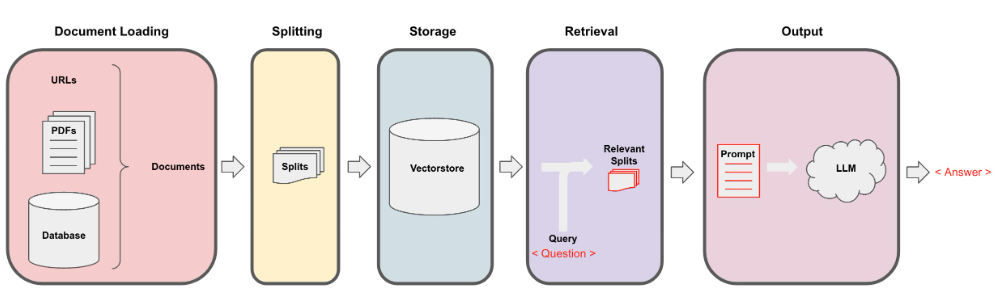

# Document Loading

In [1]:
import warnings
warnings.filterwarnings('ignore')

* ## 1. Loading

* ## Text
* ### 逐一載入pdf, save to txt ---> text loader (保留meta data)

In [3]:
import glob                                          
path = '../Data_test/預立醫療資料/*.pdf'                   # get file path; ../ 往前一個目錄位置...
pdf_path = glob.glob(path)                                # file path list

from langchain.document_loaders import PyPDFLoader

## 逐一載入pdf, ---> text
for file in pdf_path:
    loader = PyPDFLoader(file)   
    docs = loader.load()
    # Combine doc into text
    combined_docs = [doc.page_content for doc in docs]
    text = " ".join(combined_docs)
    
    file = file.replace(".pdf", ".txt")                    ## 更換檔名,存檔; 位置仍在同一目錄下...
    with open(file, 'w', encoding = "utf-8") as f:
        f.write(text)                                      ## f.writelines(text) 不適合
    
len(pdf_path)

Illegal character in Name Object (b'/ABCDEE+\xb7s\xb2\xd3\xa9\xfa\xc5\xe9')


15

In [5]:
## 載入所有 txt files, TextLoader
import glob

path = '../Data_test/預立醫療資料/*.txt'               # get file path
txt_path = glob.glob(path)                            # file path list

from langchain.document_loaders import TextLoader

loaders = [TextLoader(txt, encoding = "utf-8") for txt in txt_path]        
 
docs = []
for loader in loaders:
    docs.extend(loader.load())

len(txt_path), len(loaders), len(docs) 

(17, 17, 17)

In [6]:
docs[2]

Document(page_content='「預立安寧緩和醫療暨維生醫療抉擇意願書」  \n    本人  _______________ (簽 名) 若罹患嚴重傷病，經醫師診斷認為不可治癒，且有醫學上之證\n據，近期內病程進行至死亡已屬不可避免時，特依安寧緩和醫療條例第四條、第五條及第七條第一\n項第二款所賦予之權利，作以下之抉擇： （請勾選  ■）。 \n□接受 安寧緩和醫療 （指為減輕或免除末期病人之生理、心理及靈性痛苦，施予緩解性、支  \n        持性之醫療照護，以增進其生活品質 ） \n□接受 不施行心肺復甦術 （指對臨終、瀕死或無生命徵象之病人，不施予氣 管內插管、體外  \n        心臟按壓、急救藥物注射、心臟電擊、心臟人工調頻、人工呼吸等標準急救程序或其  \n        他緊急救治行為 ） \n□接受 不施行維生醫療 (指末期病人不施行用以維持生命徵象，但無治癒效果，而只能延長其  \n        瀕死過程的醫療措施 ） \n□同意 將上述意願加註於本人之全民健保憑證 (健保 IC卡)內 \n◎簽署人： (簽 名)               國民身分證統一編號：   \n 住（居）所：                         電話：   \n 出生年月日：中華民國  _______ ___ 年 ________ 月 _________ 日 \n□是 □否  成年（簽署人為成年人或未 成年之末期病人，得依安寧緩和醫療條例第四條第一項、第五條  \n            第一項及第七條第一項第二款之規定，立意願書選擇安寧緩和醫療或作維生醫療抉擇。 )  \n◎在場見證人（一） ： (簽 名)          國民身分證統一編號：   \n 住（居）所：                        電話：   \n 出生年月日：中華民國  __________ 年 ________ 月 _________ 日  \n◎在場見證人 （二） ： (簽 名)          國民身分證統一編號：   \n 住（居）所：                        電話：  \n 出生年月日：中華民國  __________ 年 ________ 月 _________ 日  \n簽署日期：中    華   民  

In [7]:
txt_path

['../Data_test/預立醫療資料\\QAs.txt',
 '../Data_test/預立醫療資料\\web_data.txt',
 '../Data_test/預立醫療資料\\下載_安寧療護意願書(空白).txt',
 '../Data_test/預立醫療資料\\亞洲大學附屬醫院-預立醫療流程.txt',
 '../Data_test/預立醫療資料\\心願探索手冊_聯醫版_ISBN第一版(官網閱讀).txt',
 '../Data_test/預立醫療資料\\臺北市立聯合醫院-《病人自主權利法》與《安寧緩和醫療條例》之不同-《病人自主權利法》、《安樂死》與《安寧緩和醫療條例》不一樣!.txt',
 '../Data_test/預立醫療資料\\臺北市立聯合醫院-什麼是醫療委任代理人.txt',
 '../Data_test/預立醫療資料\\臺北市立聯合醫院-什麼是預立醫療決定-什麼是預立醫療決定書？.txt',
 '../Data_test/預立醫療資料\\臺北市立聯合醫院-病人自主權利法-認識病人自主權利法.txt',
 '../Data_test/預立醫療資料\\臺北市立聯合醫院-預立醫療照護諮商服務-什麼是預立醫療照護諮商_.txt',
 '../Data_test/預立醫療資料\\臺北市立聯合醫院-預立醫療照護諮商服務-預立醫療照護諮商前，我要做哪些準備_.txt',
 '../Data_test/預立醫療資料\\預立醫療步驟.txt',
 '../Data_test/預立醫療資料\\預立醫療決定書.txt',
 '../Data_test/預立醫療資料\\預立醫療決定書易讀說明手冊_ 高齡認知友善版_20230107.txt',
 '../Data_test/預立醫療資料\\預立醫療照護.txt',
 '../Data_test/預立醫療資料\\預立醫療照護諮商 - 安寧緩和照護 - 緩和療護中心 - 特色部門 - 科別介紹 - 新光醫院.txt',
 '../Data_test/預立醫療資料\\預立醫療照護諮商(ACP)及安寧緩和醫療介紹.txt']

* ## PDFs
* ### load all PDFs at once

In [18]:
## define txt files combine/input 
import glob                                          
path = '../Data_test/預立醫療資料/*.pdf'               # get file path
pdf_path = glob.glob(path)                            # file path list

from langchain.document_loaders import PyPDFLoader

## Load PDF files by using langchain PyPDFLoader
loaders = [PyPDFLoader(pdf) for pdf in pdf_path]

docs_pdf = []
for loader in loaders:
    docs_pdf.extend(loader.load())

pdf_path, len(loaders), len(docs_pdf)    

Illegal character in Name Object (b'/ABCDEE+\xb7s\xb2\xd3\xa9\xfa\xc5\xe9')


(['../Data_test/預立醫療資料\\QAs.pdf',
  '../Data_test/預立醫療資料\\下載_安寧療護意願書(空白).pdf',
  '../Data_test/預立醫療資料\\亞洲大學附屬醫院-預立醫療流程.pdf',
  '../Data_test/預立醫療資料\\心願探索手冊_聯醫版_ISBN第一版(官網閱讀).pdf',
  '../Data_test/預立醫療資料\\臺北市立聯合醫院-《病人自主權利法》與《安寧緩和醫療條例》之不同-《病人自主權利法》、《安樂死》與《安寧緩和醫療條例》不一樣!.pdf',
  '../Data_test/預立醫療資料\\臺北市立聯合醫院-什麼是醫療委任代理人.pdf',
  '../Data_test/預立醫療資料\\臺北市立聯合醫院-什麼是預立醫療決定-什麼是預立醫療決定書？.pdf',
  '../Data_test/預立醫療資料\\臺北市立聯合醫院-病人自主權利法-認識病人自主權利法.pdf',
  '../Data_test/預立醫療資料\\臺北市立聯合醫院-預立醫療照護諮商服務-什麼是預立醫療照護諮商_.pdf',
  '../Data_test/預立醫療資料\\臺北市立聯合醫院-預立醫療照護諮商服務-預立醫療照護諮商前，我要做哪些準備_.pdf',
  '../Data_test/預立醫療資料\\預立醫療步驟.pdf',
  '../Data_test/預立醫療資料\\預立醫療決定書.pdf',
  '../Data_test/預立醫療資料\\預立醫療決定書易讀說明手冊_ 高齡認知友善版_20230107.pdf',
  '../Data_test/預立醫療資料\\預立醫療照護諮商 - 安寧緩和照護 - 緩和療護中心 - 特色部門 - 科別介紹 - 新光醫院.pdf',
  '../Data_test/預立醫療資料\\預立醫療照護諮商(ACP)及安寧緩和醫療介紹.pdf'],
 15,
 155)

In [19]:
## check first 2 pages
docs_pdf[0:2]

[Document(page_content='Q1：哪邊可以拿到預立醫療決定的表格？是不是簽\n名就可以？  \n \nA：提供 AD網站簽署前也必須與醫療團隊共同進行\n「預立醫療照護諮商」會議，討論各項醫療選項的成\n效與風險，透過溝通與決策過程，以書面形式完成您\n的「預立醫療決定」。另外，還需完成健保 IC卡註\n記，您的「預立醫療決定」才具法律效力。  \n  \n  \nQ2：任何人都可以進行「預立醫療照護諮商」  及\n「預立醫療決定」嗎？  \n  \nA：滿 20歲具有完全行為能力者皆可，只要您：   \n1.  至醫療機構完成「預立醫療照護諮商」，並經兩\n人以上在場見證或公證程序。  \n2.  完成健保 IC卡註記，您的「預立醫療決定」即具\n有法律效力。  \n  \n \nQ3：我想帶我媽去參加預立醫療決定諮商，我要怎\n麼跟她說？  ', metadata={'source': '../Data_test/預立醫療資料\\QAs.pdf', 'page': 0}),
 Document(page_content=' \nA：您可透過新聞報導、社會重大事件等話題，試著\n在聊天中找到討論時機，先聊聊自己對生命與死亡之\n體悟，鼓勵媽媽分享她的感受及想法，觀察媽媽反\n應。若媽媽不排斥，願意表達所期待的醫療照顧或身\n心靈需求，則可邀請她參加「預立醫療照護諮商」；\n並請告訴她，這是由醫師、護理師、社工師組成的諮\n商團隊，提供醫療、社會、家庭與心理的討論；諮商\n過後不一定要簽署「預立醫療決定」，但可透過諮商\n過程，讓媽媽有機會更清楚的思考與表達想法，也讓\n您有機會事先瞭解媽媽的期待。  \n  \nQ4：我爸中風 7年了，在養護中心可以簽預立醫療\n決定嗎？  \nA：原則上只要您的父親意識清楚且可以表達意願，\n以及在沒有心智缺陷或非出於自願的疑慮下，是可以\n邀請二親等家屬或醫療委任代理人，共同參與預立醫\n療照護諮商及簽署預立醫療決定的。  \n  \nQ5：預立醫療照護諮商需要多久時間呢？  ', metadata={'source': '../Data_test/預立醫療資料\\QAs.pdf', 'page': 1})]

In [20]:
docs_pdf[1].metadata

{'source': '../Data_test/預立醫療資料\\QAs.pdf', 'page': 1}

Each page is a `Document`.

A `Document` contains text (`page_content`) and `metadata`.

* ### all docs combine into one text for later text split, 缺點 失去metadata...

In [21]:
# Combine doc into text
combined_docs = [doc.page_content for doc in docs_pdf]
text = " ".join(combined_docs)

type(text)

str

In [22]:
from IPython.display import Markdown

display(Markdown(text))    

Q1：哪邊可以拿到預立醫療決定的表格？是不是簽
名就可以？  
 
A：提供 AD網站簽署前也必須與醫療團隊共同進行
「預立醫療照護諮商」會議，討論各項醫療選項的成
效與風險，透過溝通與決策過程，以書面形式完成您
的「預立醫療決定」。另外，還需完成健保 IC卡註
記，您的「預立醫療決定」才具法律效力。  
  
  
Q2：任何人都可以進行「預立醫療照護諮商」  及
「預立醫療決定」嗎？  
  
A：滿 20歲具有完全行為能力者皆可，只要您：   
1.  至醫療機構完成「預立醫療照護諮商」，並經兩
人以上在場見證或公證程序。  
2.  完成健保 IC卡註記，您的「預立醫療決定」即具
有法律效力。  
  
 
Q3：我想帶我媽去參加預立醫療決定諮商，我要怎
麼跟她說？    
A：您可透過新聞報導、社會重大事件等話題，試著
在聊天中找到討論時機，先聊聊自己對生命與死亡之
體悟，鼓勵媽媽分享她的感受及想法，觀察媽媽反
應。若媽媽不排斥，願意表達所期待的醫療照顧或身
心靈需求，則可邀請她參加「預立醫療照護諮商」；
並請告訴她，這是由醫師、護理師、社工師組成的諮
商團隊，提供醫療、社會、家庭與心理的討論；諮商
過後不一定要簽署「預立醫療決定」，但可透過諮商
過程，讓媽媽有機會更清楚的思考與表達想法，也讓
您有機會事先瞭解媽媽的期待。  
  
Q4：我爸中風 7年了，在養護中心可以簽預立醫療
決定嗎？  
A：原則上只要您的父親意識清楚且可以表達意願，
以及在沒有心智缺陷或非出於自願的疑慮下，是可以
邀請二親等家屬或醫療委任代理人，共同參與預立醫
療照護諮商及簽署預立醫療決定的。  
  
Q5：預立醫療照護諮商需要多久時間呢？   A：為了說明預立醫療意願書內涵並意願人的想法，
推估約要半小時到一小時。  
Q6：兩位或兩位以上的意願人能否在同一次諮商
中，一起完成預立醫療照護諮商？   
A：若當意願人及其家屬為彼此的二等親及醫療委任
代理人，是可以一同完成預立醫療照護諮商。   
Q7：做了「預立醫療決定」後，是否發生明明還有
治癒機會，或遭逢意外，卻被醫師提前放棄治療的情
況？  
 
A：不會。須經由二位具相關專科醫師資格之醫師確
診已符合條文所明定之臨床條件，並經緩和醫療團隊
至少二次照會，才可執行預立醫療決定，不符合臨床
條件者，應先予適當急救或採取必要措施，不得無故
拖延；其過程非常謹慎，且經重重把關，不可能因立
下預立醫療決定，而讓原有治癒機會的患者因而被提
前放棄治療。  
  
Q8：「預立醫療決定書」上傳註記後還能修改嗎？  
  A：意願人想撤回或變更預立醫療決定時，需要重新
簽署預立醫療決定書，並 向中央主管機關申請更新註
記。  
   
Q9：預立醫療決定書上為什麼需要見證人？   
A：為了保障個人簽署預立醫療決定書是出於自願、
並無遭受外力脅迫等情況所決定。  
  
Q10：誰可以擔任見證人？ (外籍看護可以嗎？ )  
A：見證人除了不是意願人所指定之醫療委任代理
人、主責照護醫療團隊成員、以及繼承人之外的受遺
贈人、遺體或器官指定之受贈人、其他因意願人死亡
而獲得利益者，剩下的人都可以擔任見證人。  
  
Q11：見證人要擔負什麼責任？  
A：見證意願人簽署當下意識清楚、出於自願未受脅
迫下簽署；不涉及醫療決策。  
  
Q12：如果沒有見證人，可以怎麼做？   
A：可以找公證人。  
   Q13：聽說預立醫療決定還要找見證人，所以我要找
到見證人一起去醫院做預立醫療照護諮商嗎？  
 
A：不一定。病人自主權利法規定在預立醫療決定上
簽名時有二名以上滿 20歲具完全行為能力人在場見
證或經公證人公證即可。若您的親友無法擔任見證
人，您可事先告知醫療機構，有些機構或許協助安
排。請特別注意，您的醫療委任代理人是無法做見證
人。  
  
Q14：做完預立醫療照護諮商後，一定要填寫預立醫
療決定書嗎？一定要當下完成並繳回嗎？   
 
A：來參加 ACP不一定要簽署 AD喔。能與自己跟
親友一起思考、探索生命議題的過程很有意義。您的
醫療決定必須讓家人知道，才能當你意識不清的時候
幫你實現。  
  
Q15：拒絕人工營養及流體餵養，那是要將病人餓
死、渴死嗎？  
  A：不是的！還可以慢慢從口餵食啊，過多水份養分
其實造成額外負擔，末期病人並不會感到飢餓，餵食
反而會造成嘔吐、食物進入氣管造成窒息等後果，若
病人無法配合，掙扎甚至四肢約束、強迫裝置鼻胃管
進行人工管灌，反更加痛苦。  
  
Q17：如果我的二親等有事無法到門診參加預立醫療
諮商，該怎麼辦？  
  
A：可以使用視訊參與預立醫療諮商，與醫療 團隊共
同了解您對生命真實想法與期待，確保預立醫療  
決定的實踐。  
  「預立安寧緩和醫療暨維生醫療抉擇意願書」  
    本人  _______________ (簽 名) 若罹患嚴重傷病，經醫師診斷認為不可治癒，且有醫學上之證
據，近期內病程進行至死亡已屬不可避免時，特依安寧緩和醫療條例第四條、第五條及第七條第一
項第二款所賦予之權利，作以下之抉擇： （請勾選  ■）。 
□接受 安寧緩和醫療 （指為減輕或免除末期病人之生理、心理及靈性痛苦，施予緩解性、支  
        持性之醫療照護，以增進其生活品質 ） 
□接受 不施行心肺復甦術 （指對臨終、瀕死或無生命徵象之病人，不施予氣 管內插管、體外  
        心臟按壓、急救藥物注射、心臟電擊、心臟人工調頻、人工呼吸等標準急救程序或其  
        他緊急救治行為 ） 
□接受 不施行維生醫療 (指末期病人不施行用以維持生命徵象，但無治癒效果，而只能延長其  
        瀕死過程的醫療措施 ） 
□同意 將上述意願加註於本人之全民健保憑證 (健保 IC卡)內 
◎簽署人： (簽 名)               國民身分證統一編號：   
 住（居）所：                         電話：   
 出生年月日：中華民國  _______ ___ 年 ________ 月 _________ 日 
□是 □否  成年（簽署人為成年人或未 成年之末期病人，得依安寧緩和醫療條例第四條第一項、第五條  
            第一項及第七條第一項第二款之規定，立意願書選擇安寧緩和醫療或作維生醫療抉擇。 )  
◎在場見證人（一） ： (簽 名)          國民身分證統一編號：   
 住（居）所：                        電話：   
 出生年月日：中華民國  __________ 年 ________ 月 _________ 日  
◎在場見證人 （二） ： (簽 名)          國民身分證統一編號：   
 住（居）所：                        電話：  
 出生年月日：中華民國  __________ 年 ________ 月 _________ 日  
簽署日期：中    華   民    國__________ 年__________ 月__________ 日(必填 )  
………………………………………………………………………………………………………………  
◎法定代理人： （ 簽署人未成年方須填寫 ）  
 簽      名：                                 國民身分證統一編號：   
 住（居）所：                                               電話：   
 出生年月日：中華民國  __________ 年 ________ 月 _________ 日  
◎醫療委任代理人： （ 簽署人為 醫療委任代理人 方須填寫並應檢附 醫療委任代理人委任書 ）  
 簽    名：                                   國民身分證統一編號：   
 住（居）所：                                               電話：   
 出生年月日：中華民國  __________ 年 ________ 月 _________ 日  
◎備註： 1簽署人可依背面簡易問答第 4題說明自行查詢健保 IC卡註記申辦進度，若無法自行查詢需要回復通知者請   
     於下列□打勾 (無勾選者視同無須回復通知 )：  
     □ 註記手續辦理成功時，請回復通知簽署人   
    2「預立安寧緩和醫療暨維生醫療抉擇意願書」填妥後 請將正本寄回：衛生福利部 (115台北市南港區忠孝東路  
          六段 488號)或宣導單位：台灣安寧照顧協會 (251新北市淡水區民生路 45號)收，副本請自行保管 。 【正本】  線上下載   「預立安寧緩和醫療暨維生醫療抉擇意願書」健保 IC卡註記申辦注意事項  
◎簡易問答：   
ㄧ、問：為什麼要將「預立安寧緩和醫療暨維生醫療抉擇意願書」加註在健保 IC卡？   
    答：為尊重末期病人之醫療意願及保障其權益，政府公布施行之『安寧緩和醫療條例』條文明訂：   
1. 末期病人得立意願書選擇安寧緩和醫療或作維生醫療抉擇。   
2. 成年且具行為能力之人，得預立意願書。   
但對於已經簽署「預立安寧緩和醫療暨維生 醫療抉擇意願書」之民眾，所簽立之「預立安寧
緩和醫療暨維生醫療抉擇意願書」若未隨身攜帶，在末期病危，卻無法主動出示時，  一般醫
療院所，就醫護人員的職責，仍應全力救治，導致常發生不符合病人意願與利益之急救等遺
憾事件。因此，在健保 IC卡上註記安寧緩和醫療意願，以提醒醫護人員尊重病患不施行心肺
復甦術或之意願，確實有其重要性。  
二、問：民眾該如何將「預立安寧緩和醫療暨維生醫療抉擇意願」加註於健保 IC卡？  
    答：將已填妥之『預立安寧緩和醫療暨維生醫療抉擇意願書』正本寄至『衛生福利部』 (地址： 115 
台北市南港區忠 孝東路六段 488號，電話： 02-85906666 ，網址： www.mohw.gov.tw) 或『台灣安寧照
顧協會』 （地址： 25160新北市淡水區民生路 45號，電話： 02-28081585 ，網址： www.tho.org.tw ） 
即可申請辦理健保 IC卡加註事宜。  
三、問：當「預立安寧緩和醫療暨維生醫療抉擇意願書」簽署並已加註於健保 IC卡，是否無法撤除及取消
註記？   
答：當簽署人意願改變欲撤除時，可填妥「撤回預立安寧緩和醫療暨維生醫療抉擇意願聲明書」 ，經簽
署人親筆簽名，將該書面資料寄回衛生福利部或受理委託執行之『台灣 安寧照顧協會』 ，承辦單位
會依程序協助辦理簽署人健保 IC卡撤除註記手續。   
四、問：如何查詢「預立安寧緩和醫療暨維生醫療抉擇意願書」在健保 IC卡已完成註記手續？   
答：ㄧ、網路查詢：   
進入【民眾意願查詢】可透過「使用健保卡查詢」或「帳號登入查詢」來進行查詢動作。  
◎以健保 IC卡查詢。   
進入衛生福利部預立醫療決定、安寧緩和醫療及器官捐贈意願資訊系統
https://hpcod.mohw.gov.tw ＞民眾意願查詢＞使用健保卡查詢＞將健保 IC卡卡片插入讀卡機
中＞確認。  
二、電話查詢：請撥免付費 0800 -220-927洽台灣安寧照顧協會查詢。   
三、可自健保 署各分區業務組 、聯絡辦公室、附設門診中心之公共服務站或與健保 署有合約之醫療  
    院所，先進行健保 IC卡資料內容更新 後，再請機構協助查詢。   
◎解釋名詞：  
1、安寧緩和醫療－ 指：為減輕或免除末期病人之生理、心理及靈性痛苦，施予緩解性、支持性之醫療照護，  
以增進其生活品質。   
2、不施行心肺復甦術－ 指： 「對臨終、瀕死或無生命徵象之病人，不施予氣管內插管、體外心臟按壓、急  
救藥物注射、心臟電擊、心臟人工調頻、人工呼吸等標準急救程序或其他緊急救治
行為」 。   
3、不施行維生醫療－ 指：末期病人不施行用以維持生命徵象及延長其瀕死過程的醫療措施。   
◎補充說明：  
1、 依據安寧緩和醫療條例第四條之規定，疾病末期之病人簽署意願書，應有具完全行為能力者二人以上在
場見證，但實施安寧緩和醫療及執行意願人維生醫療抉擇之醫療機構所屬人員不得為見證人。   
2、 依據安寧緩和醫療條例第七條第一項第二款之規定，未成年人簽署意願書時，應得其法定代理人之同意。  
3、 依據安寧緩和醫療條例第五條之規定，意願人得預立醫療委任代理人，並以書面載明委任意旨，於其無  
法表達意願時，由代理人代為簽署。  
 
 
 
 
 
   
「預立安寧緩和醫療暨維生醫療抉擇意願書」  
    本人  _______________ (簽 名) 若罹患嚴重傷病，經醫師診斷認為不可治癒，且有醫學上之證
據，近期內病程進行至死亡已屬不可避免時，特依安寧緩和醫療條例第四條、第五條及第七條第一
項第二款所賦予之權利，作以下之抉擇： （請勾選  ■）。 
□接受 安寧緩和醫療 （指為減輕或免除末期病人之生理、心理及靈性痛苦，施予緩解性、支  
        持性之醫療照護，以增進其生活品質 ） 
□接受 不施行心肺復甦術 （指對臨終、瀕死或無生命徵象之病人，不施予氣管內插管、體外  
        心臟按壓、急救藥物注射、心臟電擊、心臟人工調頻、人工呼吸等標準急救程序或其  
        他緊急救治行為 ） 
□接受 不施行維生醫療 (指末期病人不施行用以維持生命徵象，但無治癒效果，而只能延長其  
        瀕死過程的醫療措施 ） 
□同意 將上述意願加註於本人之全民健保憑證 (健保 IC卡)內 
◎簽署人： (簽 名)               國民身分證統一編號：   
 住（居）所：                          電話：   
 出生年月日：中華民國  __________ 年 ________ 月 _________ 日 
□是 □否  成年（簽署人為成年人或未 成年之末期病人，得依安寧緩和醫療條例第四條第一項、第五條  
            第一項及第七條第一項第二款之規定，立意願書選擇安寧緩和醫療或作維生醫療抉擇。 )  
◎在場見證人（一） ： (簽 名)          國民身分證統一編號：   
 住（居）所：                        電話：   
 出生年月日：中華民國  __________ 年 ________ 月 _________ 日  
◎在場見證人（二） ： (簽 名)          國民身分證統一編號：   
 住（居）所：                        電話：  
 出生年月日：中華民國  __________ 年 ________ 月 _________ 日  
簽署日期：中    華   民    國__________ 年__________ 月__________ 日(必填 )  
………………………………………………………………………………………………………………  
◎法定代理人： （ 簽署人未成年方須填 寫）  
 簽      名：                                 國民身分證統一編號：   
 住（居）所：                                               電話：   
 出生年月日：中華民國  __________ 年 ________ 月 _________ 日  
◎醫療委任代理人： （ 簽署人為 醫療委任代理人 方須填寫並應檢附 醫療委任代理人委任書 ）  
 簽    名：                                   國民身分證統一 編號：   
 住（居）所：                                               電話：   
 出生年月日：中華民國  __________ 年 ________ 月 _________ 日  
◎備註： 1簽署人可依背面簡易問答第 4題說明自行查詢健保 IC卡註記申辦進度，若無法自行查詢需要回復通知者請   
     於下列□打勾 (無勾選者視同無須回復通知 )：  
     □ 註記手續辦理成功時，請回復通知簽署人   
    2「預立安寧緩和醫療暨維生醫療抉擇意願書」填妥後 請將正本寄回： 衛生福利部 (115台北市南港區 忠孝東路  
          六段 488號)或宣導單位：台灣安寧照顧協會 (251新北市淡水區民生路 45號)收，副本請自行保管。  【副本】  線上下載   「預立安寧緩和醫療暨維生醫療抉擇意願書」健保 IC卡註記申辦注意事項  
◎簡易問答：   
ㄧ、問：為什麼要將「預立安寧緩和醫療暨維生醫療抉擇意願書」加註在健保 IC卡？   
    答：為尊重末期病人之醫療意願及保障其權益，政府公布施行之『安寧緩和醫療條例』條文明訂：   
3. 末期病人得立意願書選擇安寧緩和醫療或作維生醫療抉擇。   
4. 成年且具行為能力之人，得預立意願書。   
但對於已經簽署「預立安寧緩和醫療暨維生醫療抉擇意願書」之民眾，所簽立之「預立安寧
緩和醫療暨維生醫療抉擇意願書」若未隨身攜帶，在末期病危，卻無法主動出示時，  一般醫
療院所，就醫護人員的職責，仍應全力救治，導致常發生不符合病人意願與利益之急救等遺
憾事件。因此，在健保 IC卡上註記安寧緩和醫療意願，以提醒醫護人員尊重病患不施行心肺
復甦術或之意願，確實有其重要性。  
二、問：民眾該如何將「預立安寧緩和醫療暨維生醫療抉擇意願」加註於健保 IC卡？  
    答：將已填妥之『預立安寧緩和醫療暨維生醫療抉擇意願書』正本寄至『 衛生福利部』 (地址： 115 
台北市南港區忠孝東路六段 488號，電話： 02-85906666 ，網址： www.mohw.gov.tw) 或『台灣安寧照
顧協會』 （地址： 25160新北市淡水區民生路 45號，電話： 02-28081585 ，網址： www.tho.org.tw ） 
即可申請辦理健保 IC卡加註事宜。  
三、問：當「預立安寧緩和醫療暨維生醫療抉擇意願書」簽署並已加註於健保 IC卡，是否無法撤除及取消
註記？   
答：當簽署人意願改變欲撤除時，可填妥「撤回預立安寧緩和醫療暨維生醫療抉擇意願聲明書」 ，經簽
署人親筆簽名，將該書 面資料寄回衛生福利部或受理委託執行之『台灣安寧照顧協會』 ，承辦單位
會依程序協助辦理簽署人健保 IC卡撤除註記手續。   
四、問：如何查詢「預立安寧緩和醫療暨維生醫療抉擇意願書」在健保 IC卡已完成註記手續？   
答：ㄧ、網路查詢：   
進入【民眾意願查詢】可透過「使用健保卡查詢」或「帳號登入查詢」來進行查詢動作。  
◎以健保 IC卡查詢。   
進入衛生福利部預立醫療決定、安寧緩和醫療及器官捐贈意願資訊系統
https://hpcod.mohw.gov.tw ＞民眾意願查詢＞使用健保卡查詢＞將健保 IC卡卡片插入讀卡機
中＞確認。  
二、電話查詢：請撥免付費 0800 -220-927洽台灣安寧照顧協會查詢。   
三、可自健保 署各分區業務組 、聯絡辦公室、附設門診中心之公共服務站或與健保 署有合約之醫療  
    院所，先進行健保 IC卡資料內容更新 後，再請機構協助查詢。   
◎解釋名詞：  
1、安寧緩和醫療－ 指：為減輕或免除末期病人之生理、心理及靈性痛苦，施予緩解性、支持性之醫療照護，  
以增進其生活品質。   
2、不施行心肺復甦術－ 指： 「對臨終、瀕死或無生命徵象之病人，不施予氣管內插管、體外心臟按壓、急  
救藥物注射、心臟電擊、心臟人工調頻、人工呼吸等標準 急救程序或其他緊急救治
行為」 。   
3、不施行維生醫療－ 指：末期病人不施行用以維持生命徵象及延長其瀕死過程的醫療措施。   
◎補充說明：  
1、 依據安寧緩和醫療條例第四條之規定，疾病末期之病人簽署意願書，應有具完全行為能力者二人以上在
場見證，但實施安寧緩和醫療及執行意願人維生醫療抉擇之醫療機構所屬人員不得為見證人。   
2、 依據安寧緩和醫療條例第七條第一項第二款之規定，未成年人簽署意願書時，應得其法定代理人之同意。  
3、 依據安寧緩和醫療條例第五條之規定，意願人得預立醫療委任代理人，並以書面載明委任意旨，於其無
法表達意願時，由代 理人代為簽署。   預立醫療照護諮商  
◎什麼是預立醫療照護諮商 (Advance Care Planning, ACP) ? 
「預立醫療照護諮商」是在自己意識清楚，可以表達的狀態下，至預立醫療照
護諮商機構進行討論的過程。您可以依據自己對生命的想法，當您遇到末期病
人、處於不可逆轉之昏迷狀況、永久植物人狀態、極重度失智、或主管機關公
告之難以忍受之疾病的五種臨床狀況時，選擇自己期待的醫療照護方式。  
◎何謂「預立醫療決定書」  (Advance Decision, AD)?  
預立醫療決定書是意願人 (就是本人 )經「預立醫療照護諮商」後，已經清楚瞭解
「病人自主權利法」 裡面規定，賦予您預先表達在符合了特定臨床條件的情況時，
接受或拒絕維持生命治療，或人工營養及流體餵養的正式書面文件。  
預立醫療決定書格式分為兩個部分和一份附件，  
第一部分的本人以及見證人的簽署欄位  
第二部分是醫療照護選項的表達  
附件為醫療委任代理人的委任書，若您有想指定的醫療委任代理人再填寫就好囉，
若無則免。  
◎預立醫療決定書何時會啟動呢 ? 
      預立醫療決定書不是生效後，在您因意外或疾病昏迷時就會馬上啟
動！！ 而是在疑似臨床特定條件之一發生時，經由兩位相關專科醫師確診，並
經緩和團隊至少兩次照會，確認您符合五款臨床條件之一的時候，才會依醫療
常規與親友、醫療委任代理人或關係人進行討論後執行。因此即便您簽署了預
立醫療決定書，但在事情發生前，與這些身邊重要的人們有所討論，達成共識
是很重要的，也才能一起促進家庭關係不會因此產生糾紛，更能達到醫病和
諧，維護自身善終與自主的安排。  
 
 
 
 
 
 
 
 
 
  ◎預立醫療照護諮商 門診流程  
為尊重病人醫療自主、保障其善終權益，促進醫病關係和諧，而制定的「病人
自主權利法」 ，已於 2019年1月6日正式施行。 「預立醫療照護諮商門診」 是讓
預立醫療決定生效的 必要條件之一 ，由預立醫療團隊提供專業諮詢，讓民眾了
解在特定的醫療情況下，做出符合自己意願的決定，並簽署「預立醫療決定
書」 。 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
★為提升諮商效率，請於預約諮商前詳讀或試填「預立醫療決定書」  
    相關說明請參考「安寧照顧基金會」病人自主權利法專區      
    http://www.hospice.org.tw/2009/chinese/share.php?cate=7  
1.適用對象─  
完全行為能力 者：
未成年已 結婚者，
或年滿20歲(除授
監護宣告者以外 ) 
3.門診預約─ 
須接受門診前衛教 ，確認諮商門診前的準備 ，
故不接受線上門診掛號 。 
人工預約 電話： 
04-37061668 分機1349 
門診時間： 星期三下午 201診 
2.諮商門診前的準備─  
(1)與家人溝通 在末期病人、不可逆轉之昏
迷、永久植物人狀態 、極重度失智 、其他公
告疾病等情況下 希望接受或拒絕 哪些醫療
(參考「預立 醫療決定書 」內容)。 
(2)邀請至少一位 2等親家屬。如有醫療委
任代理人 ，須一同 參加。 
(3)建議「2位見證人」 (其中一位可以是上
點的2等親家屬 )，一同參加 ，釐清疑慮以
及縮短完成簽署的時間 。 
(4)攜帶雙方親屬關係之 身分確認 證件、健
保卡。 
★門診當日務必攜帶健保卡！
  
★目前預立醫療照護諮商門診尚未有健保給
付，需自費  
4.進行諮商 ─ 
「簽署預立醫療決定書 」  ◎病人自主權利法 -「預立醫療決定書」 VS 
安寧緩和醫療條例 -「預立安寧緩和醫療暨 維生醫療抉擇意願書 」 
三大不同  安寧緩和醫療條例  病人自主權利法  
理論基礎  1. 保障末期病人的善終權益。  
2. 病人簽具意願書，亦可由最
近親屬簽具同意書為之  
(但實務上多由親屬為之 )。 1. 保障每個人的人格尊嚴、自
主與善終權利，僅心智能力
健全者可自己做成決定。  
2. 以病人為核心，保障其知
情、選擇與決定權。  
3. 搭配各種程序保障機制：預
立醫療照護諮商、預立醫療
決定、醫療委任代理人。  
適用對象  只有末期病人。  1. 末期病人。  
2. 不可逆轉昏迷。  
3. 永久植物人。  
4. 極重度失智。  
5. 其他經主管機關公告的重
症。 
適用範圍  1. 心肺復甦術。  
2. 只能延長瀕死過程的「維生
醫療」 。 1. 任何有可能延長病人生命之
必要醫療措施：心肺復甦
術、機械式維生系統、血液
製品，為特定疾病而設之專
門治療、重度感染時所給予
之抗生素等。  
2. 人工營養及流體餵養。  
 
◎相關附件  
「預立醫療決定書 」 
「亞大附醫 -預立醫療照護諮商收費表 1080822」 
「病人自主權利法宣導短片 -國語版」(資料來源：安寧照顧基金會 ) 
「病人自主權利法宣導短片 -台語版」(資料來源：安寧照顧基金會 ) 
「預立醫療照護諮商教材 -民眾版」 
 
   
 
  
 
 
 
 
  
 
 
 
 
  
  
 
  
 我的預立醫療決定  
心願探索手冊  
臺北市立聯合醫院  溫馨發行  
2024 年03月 送自己與家人這份愛的禮物  
臺北市立立聯合醫院  
Taipei City Hospital     我的預立醫療決定 -心願探索手冊                                                                                                                                                                                臺北市立聯合醫院                                                               
                                                                                                                                   2 
   我的預立醫療決定 -心願探索手冊                                                                                                                                                                                臺北市立聯合醫院                                                               
                                                                                                                                   3 
 
 
壹、心願探索篇   8 
如何進行「善終心願探索」呢？  9 
心願一：探索我的生命品質與價 值   10 
心願二：與所愛的人共同討論我的決定  13 
                 如何選擇我的「醫療委任代理人」？  15 
心願三：撰寫我的「四道人生」謝幕致詞  16 手冊目錄  
貳、預立醫療決定書篇  19 
病人自主權利法介紹  20 
預立醫療決定書 (AD) 是什麼?  21 
預立醫療決定書 (AD) 範本  22 
         意願人基本欄位、見證與公證欄位說明  23 
         五款特定臨床條件說明  25 
         醫療照護方式、意願選擇說明  27 
         預立醫療照護諮商核章、法定參與人員說明  29 
         醫療委任代理人委任書及相關資格、權責說明  31 
預立醫療決定書寫好就生效了嗎？  32 
預立醫療決定書生效之後，還需注意什麼？  33 
友善資訊與連結  34 
如何預約預立醫療照護諮商？  35 前言：人生必經的春夏秋冬  5 
開始思考您生命的起點與終點  6 
 
 
 
  我的預立醫療決定 -心願探索手冊                                                                                                                                                                                臺北市立聯合醫院                                                               
                                                                                                                                   4 
 
前言    我的預立醫療決定 -心願探索手冊                                                                                                                                                                                臺北市立聯合醫院                                                               
                                                                                                                                   5 
 
前言：人生必經的春夏秋冬  
 「生如夏花之絢爛，死如秋葉之靜美 」，  生老病死是人生旅途必經
的過程，從求學、戀愛、結婚、工作等不同階段，都會為自己做決定。
人生處處充滿了風險與未知，那您是否曾經思考過在生命秋冬來到時，
如何決定、安排人生故事的最終章 -「善終」 呢?  
 
 要如何安排善終，卻是難以開口討論的話題，常常心裡會對自己或
家人說「 時候到了再說！ 」，或想談的時候，被親友說「 你是在詛咒我
嗎? 沒事講什麼不吉利的話！ 」，但有時意外和疾病來的太突然，發生的
時候，身旁以及家裡的人不知道自己的想法，自己也沒有機會好好地說
再見！  
 
 希望透過瀏覽這本手冊，讓您思考人生的春夏秋冬，探索在秋冬之
際的心願安排以及法律可以給我們什麼協助！給自己再次認識內在想法
的機會，也是藉由法律保障，給您和給家人一份愛的禮物！  
前言  
  我的預立醫療決定 -心願探索手冊                                                                                                                                                                                臺北市立聯合醫院                                                               
                                                                                                                                   6 
 
 先暖身一下！想一想幾個關於您生命中曾遇到的問題 ? 
您曾經有親友面臨生病、住院或過世
的經驗嗎？  
 
□ 有。我親身的經驗是：                   
□ 我沒有經驗，但有聽周遭親友聊過：              
□ 沒有遇過或思考過類似的經驗。  
  
  有人跟您討論過生命起點與終點   
（生死）的話題嗎？  
 
 
□ 有認真談過，我的生死觀是：                              
□ 有想過，但是還沒有機會跟別人討論 。 
□ 沒有想過，或覺得避諱或恐懼，不知道如何開口 。 
前言  
思考您生命的起點與終點  
  我的預立醫療決定 -心願探索手冊                                                                                                                                                                                臺北市立聯合醫院                                                               
                                                                                                                                   7 
 
前言  
如果可以選擇，您會希望自己的   人
生用哪種方式謝幕？  
 
  
 
 
   您是否有想過這 3個人生議題呢 ? 
 
 
 當然，每一個人的答案不盡然相同，有人想得很清楚；有
人還沒想過這樣的問題。無論如何，您已經開始心願探索旅程
的第一步了！  
 
 下頁開始，您將會探索、追尋自身的心願，做好您想要的
安排！  (在此寫下您的想法 ) 
  我的預立醫療決定 -心願探索手冊                                                                                                                                                                                臺北市立聯合醫院                                                               
                                                                                                                                   8 
 
一、心願探索篇  
 一、心願探索篇    我的預立醫療決定 -心願探索手冊                                                                                                                                                                                臺北市立聯合醫院                                                               
                                                                                                                                   9 
 
一、心願探索篇  
如何進行「善終心願探索」呢？  
 您可以透過以下三個心願來引導與探索您的內心想法：   
心願一      探索我的生命品質與價 值 
 
當只能透過某些醫療方式「活著」時，  
您會如何看待生命品質的價 值與意義呢？  
心願二      與親友共同討論我的決定  
 
提早溝通討論，讓您愛的親友知道您的意願，  
預防自己折磨受苦、也避免讓他人替您做出困難的決定。  
 
心願三      我的「四道人生」的謝幕致詞  
 
透過四道人生「道謝、道愛、道歉、道別」的方式，  
想想您要留給 您愛的親友 最後的致詞與禮物！    我的預立醫療決定 -心願探索手冊                                                                                                                                                                                臺北市立聯合醫院                                                               
                                                                                                                                   10 
 
心願一：探索我的生命品質與價 值  
想一想，如果您未來罹患慢性或重大疾病時，要做出適合您的醫療
照護決定，對自己與所愛之人是重大的挑戰 ...這時候該怎麼辦？  
Q1.如果有一天，您病得非常嚴重，是否想知道病情？  
完全不想要  
知道我的病情  我想要充分了
解病情與治療
方式  
1 
 2 
 3 4 5 一、心願探索篇  
請您從下列問題中，  
依程度圈選出最貼近自己心意的分數：     我的預立醫療決定 -心願探索手冊                                                                                                                                                                                臺北市立聯合醫院                                                               
                                                                                                                                   11 
 
Q2.如果疾病造成您無法照顧自己(例如：洗澡、吃飯等日常活
動)，或不認得外界事物，對自己需要被照顧的想法是 …？ 
Q3.承上題，到那樣的病況時，您對自己生活品質與意義的看
法是 …？ 
1 
 2 
 3 4 5 
即使生命有限，
也要保有獨立性  我不介意  
由他人照顧  
1 
 2 
 3 4 5 
生活仍有品質，  
具有意義  生活沒有品質  
非常沒有意義   
Q4.如果您病重經過一段時間治療，仍無法治癒或陷入昏迷。
您對於接受心肺復甦術 (CPR) 、呼吸器、葉克膜、及其他延長
生命的醫療措施的想法是 …？ 
希望喊停，讓我順
其自然、尊嚴善終
辭世   希望盡可能存
活下來  
1 
 2 
 3 4 5 一、心願探索篇    我的預立醫療決定 -心願探索手冊                                                                                                                                                                                臺北市立聯合醫院                                                               
                                                                                                                                   12 
 
Q5.如果疾病讓自己無法永久用嘴巴吃東西，您對於使用鼻胃
管、胃造口的方式提供養分與水分的想法是 …？ 
希望盡可能存
活下來  希望喊停，順其  
自然、尊嚴善終  
1 
 2 
 3 4 5 
Q6.請問還有哪些擔心或疑慮，會影響您的醫療照護決定 …？
(可複選 ) 
□ 我擔心做了決定之後，醫護人員就不積極治療我的疾病了  
□ 我擔心不了解醫學照護知識與選項，不知道該怎麼做決定  
□ 我擔心親友可能與我的意見不一致，但他們的想法對我很重要  
□ 其他：                               
Q7. 您可以在下面空白處，寫下當您處在一些需要他人長期照
顧的疾病狀況時，您對於此時生命品質與價 值的看法 …？ 
     
     
     
     一、心願探索篇    我的預立醫療決定 -心願探索手冊                                                                                                                                                                                臺北市立聯合醫院                                                               
                                                                                                                                   13 
 
心願二：與所愛的人共同討論我的決定  
          能夠與所愛的家人朋友、醫療人員等，共同討論您在前面
【心願一 】的醫療照護想法是不常見的，趁現在試試看吧？  
 
請您從下列問題中，依您的感受，圈選出最貼近自己心
意的分數：  
Q1.您的醫療照護，您想「自己決定」，還是想「邀請親友」
討論後再決定？  
自己決定即可  自己與親友  
討論決定  
1 
 2 
 3 4 5 
一、心願探索篇    我的預立醫療決定 -心願探索手冊                                                                                                                                                                                臺北市立聯合醫院                                                               
                                                                                                                                   14 
 
Q2.如果您罹患重病，是否會希望親近的人知道您生病呢？  
1 
 2 
 3 4 5 
我希望親近的人
知道一切病情  我不希望他們
知道任何病情  
Q3.請問您覺得邀請家屬一起討論自己的醫療決定有困難嗎？  
Q4.請問您希望有「醫療委任代理人」讓她 /他在您昏迷或無法
表達意願時，依照您預立醫療決定書的內容表達您的意願嗎？  
1 
 2 
 3 4 5 
   不困難，  
   容易邀請  非常困難  
1 
 2 
 3 4 5 
我希望指定  我不希望  
指定   尚未決定  
適合人選  
一、心願探索篇  
  我的預立醫療決定 -心願探索手冊                                                                                                                                                                                臺北市立聯合醫院                                                               
                                                                                                                                   15 
 
如何選擇我的「醫療委任代理人」？  
 在預立醫療決定書內，您可以指定醫療委任代理人 (第31頁)替您發
聲或替您決定。  
 請將可能適合他的人選，將名字填寫在下方表格裡，來找出適合者
和排序。請於姓名下方欄位將您認為符合的條件打勾，再將打勾數量加
總、排出順序。  
             請填上心目中的人選 ⇨ 
                    
符合條件請打勾  (可複選 )⇩ 姓名  姓名  姓名  
      
關係  關係  關係  
      
1.是我能 夠信任的人  □ □ □ 
2.勇於與我討論生老病死等敏感話題  □ □ □ 
3.當我有需要時能 夠陪伴在我身邊  □ □ □ 
4.了解我的性格、想法，也明白什麼事
情對我是重要的  □ □ □ 
5.願意聆聽我的意願，即使想法與我的
意願不同，還是能代表我去表達意見  □ □ □ 
6.能和我的家人、朋友和醫護人員有良
好的溝通互動  □ □ □ 
7.能處理我的家人、朋友和 /或醫護人
員間的意見衝突  □ □ □ 
8.願意尊重我的決定並能代替我發聲  □ □ □ 
9.能夠長期擔任我的醫療委任代理人  □ □ □ 
總  分        
排  名        ？ ？ 
 ？ 
資料來源：王英偉 ( 2013)‧ 預立醫療自主計劃手冊 ‧新北市：財團法人中華民國 (台灣) 安寧照顧基金會。  一、心願探索篇    我的預立醫療決定 -心願探索手冊                                                                                                                                                                                臺北市立聯合醫院                                                               
                                                                                                                                   16 
 
心願三：撰寫我的「四道人生」  
  善終謝幕致詞    
「四道人生」是 「道謝、道愛、道歉、道別 」。 回顧這一生經歷的點
點滴滴後，想想還有哪句感謝的話、想要道別的話語、想說對不起的
事情、以及想要對誰說出「我愛您」。  
您可以在此寫上您的四道人生：  
我想道謝 的話：  
我想道歉 的話：  最想對誰說 ? 
最想對誰說 ? 
 I’m  
Sorry  
一、心願探索篇    我的預立醫療決定 -心願探索手冊                                                                                                                                                                                臺北市立聯合醫院                                                               
                                                                                                                                   17 
 
 I LOVE  
YOU  
我想道愛 的話：  
我想道別 的話：  
 Good  
Bye  
除了四道人生之外，還有這些事情是您可以思考的謝幕安排 … 
1.  可以的話，我希望臨終地點在：  
家裡  長照服務機構  醫院  由親人決定  
由醫療委任代理人決定  其他：                   。 
2.  在我過世後，我希望的葬禮儀式，骨灰 (骸)處置意願：  
火化    不火化，保留骨骸   其他：                       。 
3.  我希望的安葬意願： 靈骨塔、 墓園 (地)、環保自然葬，  
例如：樹葬、花葬、海葬、其他：                    。 
最想對誰說 ? 
最想對誰說 ? 一、心願探索篇    我的預立醫療決定 -心願探索手冊                                                                                                                                                                                臺北市立聯合醫院                                                               
                                                                                                                                   18 
 
4.  我希望的葬禮儀式（告別式 /追思會）：  
                                                 。                                                                  
5.  我希望如何處理網路社群帳號(如： Line 、臉書 Facebook 、IG)及
其他數位資料 (電腦、手機密碼或照片 )： 
                                          。 
我的其他願望或交代  (例如：希望捐出仍可使用的器官或組織、希望
把遺產指定捐給某個慈善團體、希望親友定期來探望我等）：  
     
     
     
     
     
     
一、心願探索篇    我的預立醫療決定 -心願探索手冊                                                                                                                                                                                臺北市立聯合醫院                                                               
                                                                                                                                   19 
 
二、預立醫療決定書 (AD) 篇 
二、預立醫療決定書 (AD) 篇    我的預立醫療決定 -心願探索手冊                                                                                                                                                                                臺北市立聯合醫院                                                               
                                                                                                                                   20 
 
二、預立醫療決定書 (AD) 篇 
核心理念：  
知情權  
 選擇權  
 預立醫療決定書  
我國兩部有法律保障的善終文件比較            《病人自主權利法 》在 108年上路！是第一部以「 病人 」為主體/中心而設
計的醫療法規。它強調「 病情告知本人 」、「 病人有選擇與決定權 」，以及透
過「 預立醫療決定書、預立醫療照護諮商 」的方式，來保障您未來遭遇五種生
病情況時，因有「 做好溝通與寫下安排 」，讓您有尊嚴善終的機會。   
 預立安寧緩和醫療 暨 
維生醫療抉擇意願書   
(俗稱：意願書、 DNR)  預立醫療決定書  
(簡稱決定書、 AD、Advance decision)  
法源  
不同  安寧緩和醫療條例  
2000 年上路  病人自主權利法  
2019 年上路  
適用疾病  
不同  只有「 末期病人 」  
拒絕的  
醫療範圍  
不同  1. 「心肺復甦術 (CPR) 」 
2. 延長瀕死過程的「 維生醫療 」 
3. 接受 /拒絕「 緩和醫療 」 
 1. 維持生命治療  
2. 人工營養及流體餵養 (點滴、鼻胃管、胃造口 ) 
(緩和醫療在這部法律要求為必要提供 ) 
保障程序  
不同  1. 意願人簽署「意願書」便生效  
2. 病人失去意識時，可由最近親
屬簽具「同意書」  1.參加「預立醫療照護諮商」  
2.簽署「預立醫療決定書」且註記至健保卡  
3.可指定「醫療委任代理人」  
病人自主權利法介紹  
5.其他經中央政府 (衛福部 )公告之疾病  1.末期病人  
 2.不可逆轉之昏迷  
3.永久植物人  4.極重度失智  
? ? 
? 
  我的預立醫療決定 -心願探索手冊                                                                                                                                                                                臺北市立聯合醫院                                                               
                                                                                                                                   21 
 
          預立醫療決定書 (Advance decision , AD)(以下稱決定書 )」可以 預
先表達您未來如果處於特定臨床條件時 (見第 25頁)，希望 「接受」
或「拒絕」 的維持生命治療等醫療照護選項。  
預立醫療決定書有 4個部分：  
基本資料與見證 /公證人欄位  
 您想要 /不想要的醫療選項  
預立醫療護諮商核章欄位  
 醫療委任代理人委任書 (附件 )   
  預立醫療決定書是什麼 ? 
 決定書要能順利執行，有先跟家人溝通也是非常重要的一環！
因此簽薯前，依病主法需跟親友至醫療院所進行  「預立醫療照護諮
商」，一起討論：  
1.病人本人有知道病情的權利  
2.五款臨床條件的醫療說明  
3.維持生命治療醫療選項如何選擇  
4.決定書要怎麼簽署、變更  
5.醫療委任代理人的安排與任務  
 
 這是很重要的溝通過程，請將自身的疑問盡量提出來，專業的
諮商團隊會為您解答，同時討論出您適合的決定。另外，諮商費用是
要收費的，各醫院的諮商費用有所不同。  
二、預立醫療決定書 (AD) 篇 
預立醫療照護諮商    我的預立醫療決定 -心願探索手冊                                                                                                                                                                                臺北市立聯合醫院                                                               
                                                                                                                                   22 
 
二、預立醫療決定書 (AD) 篇   我的預立醫療決定 -心願探索手冊                                                                                                                                                                                臺北市立聯合醫院                                                               
                                                                                                                                   23 
 
【意願人基本資料欄位 】 
二、預立醫療決定書 (AD) 篇 
請簽署您的大名  
 填寫您的個人資料及  
簽署的日期和時間  
【見證或公證欄位 】 
見證人：見證人的任務是在場證明「 您是自願且親自
簽署此份文件，不是他人強迫簽署的。 」 
見證人資格： 完全行為能力之人 (成年 )即可  
                           (如： 18歲以上的親友、鄰居 ) 
公證人：若無見證人可協助，可以公證的方式處理。  
 決定書共有五頁，從本頁開始至 31頁，手冊的「左邊頁面為衛生福
利部的 『正式公告版本』 ，手冊右邊頁面為 『解說』 」。其中每一頁都
有要填寫和注意的事項，我們來看看有哪些重要內容吧！  認識預立醫療決定書( AD) 
(註：公證人可尋求 法院公證人 、民間公證人 。其中，民間公證人所
作公證之效力與法院公證相同 (公證法§ 1、24、36)。) 
【法院公證人】  
全國各 地方法院 皆提供法院
公證人服務。  
(這邊提供 台北地方法院公證處 資訊 ) 
【民間公證人】  
可到「司法院民間公證人
名冊」 查詢喔。    我的預立醫療決定 -心願探索手冊                                                                                                                                                                                臺北市立聯合醫院                                                               
                                                                                                                                   24 
 
二、預立醫療決定書 (AD) 篇 
  我的預立醫療決定 -心願探索手冊                                                                                                                                                                                臺北市立聯合醫院                                                               
                                                                                                                                   25 
 
二、預立醫療決定書 (AD) 篇 
【特定臨床條件 】  
在預立醫療照護諮商中，團隊會針對這 5款臨床條件介紹、
並說明確診標準、確診流程。  5款臨床條件包含：  
末期病人  不可逆轉之昏迷  
極重度失智  永久植物人狀態  
其他經衛生福利部所公告之疾病  
(註：目前 2021 年4月13日已公告 12項疾病，如罕見疾病 ) 
? ? ? 
 您可以想想分別在以下 5 款特定臨床條件時，想要拒絕或接
受的 醫療照護選項 。   我的預立醫療決定 -心願探索手冊                                                                                                                                                                                臺北市立聯合醫院                                                               
                                                                                                                                   26 
 
二、預立醫療決定書 (AD) 篇 
  我的預立醫療決定 -心願探索手冊                                                                                                                                                                                臺北市立聯合醫院                                                               
                                                                                                                                   27 
 
二、預立醫療決定書 (AD) 篇 
【醫療照護方式 】  
每一種 臨床條件 下，可以選擇的 醫療照護方式 有：  
維持生命治療  人工營養及流體餵養  
【醫療照護意願選擇】  
每一個選項又包含四個項目 (不可複選 )， 
簡單來說，您可以選擇：  
1.不希望治療  2.限時嘗試治療  4.希望治療  
或者是選擇 … 
3.由您的醫療委任代理人決定  
(註：選項號碼是按照預立醫療決定書的方式編號 ) 心肺復甦術 (CPR)  
機械式維生系統  
(例如：葉克膜、呼吸器 ) 
血液製品  
(例如：輸血 ) 
特定疾病而設之專門治療  
(例如：洗腎、癌症治療 ) 
重度感染時所給予抗生素  
鼻胃管  
靜脈注射 (點滴 ) 
胃造口  
  我的預立醫療決定 -心願探索手冊                                                                                                                                                                                臺北市立聯合醫院                                                               
                                                                                                                                   28 
 
二、預立醫療決定書 (AD) 篇 
  我的預立醫療決定 -心願探索手冊                                                                                                                                                                                臺北市立聯合醫院                                                               
                                                                                                                                   29 
 
二、預立醫療決定書 (AD) 篇 
【醫療機構核章證明 】  
 當您完成 預立醫療照護諮商後 ，會幫您在此 頁面上
蓋章 ，證明您已經完成預立醫療照護諮商囉！  
這是要讓預立醫療決定書生效的重要法律程序喔！  
       您必須邀請至少一位「二親等內之家屬」、您希望指定的  
「醫療委任代理人 (如有指定 )」進行「預立醫療照護諮商」。  
二親等內家屬(至少一人)  
醫療委任代理人  
(如果您有指定 ) 
小提醒：哪些人需要參加預立醫療照護諮商呢 ? 
1. 配偶   
2. 子女  
3. 父母  
4. 公婆 /岳父母  
5. 手足  
7. 祖父母 /外祖父母  
8. 配偶的祖父母  7. 女婿 /媳婦   
8. 弟媳 /兄嫂  
9. 姐夫 /妹夫    
10.妯娌 /連襟  
11.內/外孫子女  
12.內/外孫子女的配偶  二親等內家屬包含：    我的預立醫療決定 -心願探索手冊                                                                                                                                                                                臺北市立聯合醫院                                                               
                                                                                                                                   30 
 
二、預立醫療決定書 (AD) 篇 
  我的預立醫療決定 -心願探索手冊                                                                                                                                                                                臺北市立聯合醫院                                                               
                                                                                                                                   31 
 
二、預立醫療決定書 (AD) 篇 
【醫療委任代理人委任書】  
如果有指定醫療委任代理人，一定要寫此附件喔！  
請您簽名及填寫醫療代理人之順位(超過 1位以上)。  
請醫療委任代理人完成簽名、日期及其他個人資料。  
小提醒：醫療委任代理人的資格與任務  
擔任資格與任務  
資格  任務： 當您(意願人)意識昏迷或無法清楚表達意願
時，可代理您去表達醫療意願，任務如下：  
成年  
成年 (18歲以上 ) 
且具行為能力之人  
聽取病情及  
治療的告知  
簽署侵入性檢 查或 
手術治療同意書  
依您 (意願人 )的預立醫療決
定書內容，代理表達意願  
資格不符合者  
下面這幾種人，除了本身就是您 (意願人 )的民法繼承人外，
否則下列情況 /資格是不能成為醫療委任代理人的喔！  
您(意願人 ) 
的受遺贈人  您(意願人)遺體或  
器官指定的受贈人  其他因您(意願人)死亡  
而獲得利益的人  
  我的預立醫療決定 -心願探索手冊                                                                                                                                                                                臺北市立聯合醫院                                                               
                                                                                                                                   32 
 
二、預立醫療決定書 (AD) 篇 
預立醫療決定書寫好就生效了嗎？  
完成諮商  
要簽預立醫療決定書， 一定要參加預立醫療
照護諮商 ，諮商後會在預立醫療決定書蓋上
完成諮商 的核章證明 。 
決定書填寫  
確認決定書內容 是否都有填寫完成 。 
 掃描上傳  (記得帶健保卡 ) 
請攜帶 預立醫療決定書 、健保卡 帶到諮商
機構進行掃描上傳。  
 註記健保卡   
 您的預立醫療決定書會存在衛福部資料
庫，並 註記 在健保卡 內。恭喜 完成程序 且有
法律效力 了！  
         完成以上步驟後，除了讓決定書有法律保障外，也能在
政府網頁上下載，並閱覽您的決定書喔！也不用擔心紙本文
件遺失的情況了！   寫好後，還需要按照以下步驟進行，最終上傳至健保卡內，才
會有法律效力喔！  
【查詢您的預立醫療決定書】：掃描右方 QRCODE 可進入 「衛生福利部預
立醫療決定、安寧緩和醫療及器官捐贈意願資訊系統」 查詢，若第一次登
入，請用電腦先 申辦免費帳號 、讀卡機 和自然人憑證 。   我的預立醫療決定 -心願探索手冊                                                                                                                                                                                臺北市立聯合醫院                                                               
                                                                                                                                   33 
 
二、預立醫療決定書 (AD) 篇 
預立醫療決定書生效之後，還需注意什麼？   
 
視需求調整  
醫療委任代理人  
          
醫療委任代理人也可以 隨時新增和
解除 。如果有新增代理人，也請好
好告知您的心願與決定，讓她 (他)知
道如何妥善替您的心願發聲！  
 
告訴  
其他親友心願  
           
親友不全然知道您有簽預立決定
書，或有參加預立醫療照護諮商。
有機會把您的心願、在意的事情好
好告訴他們 ，認同您的期待與安
排。在未來時可以幫您更順利達成
心願。  
 
定期審視  
預立醫療決定書         
 
您若想改變心願，請隨時拿到
「有提供預立醫療諮商服務」的
醫療機構進行 變更 或撤除 ，也記
得把變更後的想法告訴親友！  
 
預立醫療決定書  
的執行時機  
           
決定書生效後， 要等到您符合臨床條
件時才能執行 。符合臨床條件須由
「2位專科醫師判定及 2次緩和團隊
照會確診 」的程序，而不是決定書生
效後就可以隨時執行。也別擔心醫師
不會因為您簽了，送急診就直接放棄
急救您喔！  
  我的預立醫療決定 -心願探索手冊                                                                                                                                                                                臺北市立聯合醫院                                                               
                                                                                                                                   34 
 
二、預立醫療決定書 (AD) 篇 
友善資訊與連結  
 提供病主法、決定書、諮商的介紹、常見
問答和影片，以及如何預約臺北市立聯合醫院
的預立醫療照護諮商。  【臺北市立聯合醫院  /預立醫療照護諮商專區】  
 提供全國「執行預立醫療照護諮商服
務」之醫療機構資訊、病人自主權利法懶人
包、預立醫療決定簽署統計、介紹推廣頁面 。  【衛生福利部  /預立醫療決定專區】  
 當您想要/已經「預約預立醫療照護
諮商」時，您知道有哪五件參加諮商前的
事情嗎？ 趕快趕緊播放這部影片了解一下
吧！  【諮商前的五件事情】  
病人自主研究中心  【其他病主法友站資訊】  
財團法人中華民國(台灣)  
安寧照顧基金會  
5 
器官捐贈移植登錄及  
病人自主推廣中心    我的預立醫療決定 -心願探索手冊                                                                                                                                                                                臺北市立聯合醫院                                                               
                                                                                                                                   35 
 
二、預立醫療決定書 (AD) 篇 
 看完此手冊，了解預立醫療決定書後，或許您開始有其他
疑問，像是「之前有簽過安寧的 DNR 意願書，難道還要簽這個
嗎？」、「五款臨床條件的判定方式是什麼？」、「參加預立醫
療照護諮商才能簽這個嗎？」  
 其實想想，還有許多需要與醫療人員諮詢或討論的細節，
歡迎您邀請二親等家屬，至臺北市立聯合醫院預約您的「預立醫
療照護諮商門診」時間，維護您的自主善終選擇!  如何預約預立醫療照護諮商？  
仁愛院區  (02) -2709 -3600 轉3521 、3519  
中興院區  (02) -2552 -3234 轉3619  
和平婦幼  (02) -2388 -9595 轉2022  
忠孝院區  (02) -2786 -1288 轉8156  
陽明院區  (02) -2835 -3456 轉5136  
林森中醫  
昆明院區  (02) -2370 -3739 轉1464  
(02) -2591 -6681 轉1505  
松德院區  (02) -2726 -3141 轉1141  
      院本部社工室  (02) -2555 -3000 轉2175  
     院本部 ACP  
教育 &推廣課程  (02) -2555 -3000 轉2082  
臺北市立聯合醫院  
預立醫療照護諮商服務諮詢窗口    我的預立醫療決定 -心願探索手冊                                                                                                                                                                                臺北市立聯合醫院                                                               
                                                                                                                                   36 
 
發行單位：臺北市立聯合醫院  
發行人：蕭勝煌  
出版單位：臺北市立聯合醫院人文創新書院  
總策劃：黃遵誠  
主編：黃少甫  
共同編輯：葉依琳、田恩慈、曾意婷、張恩瑜  
美術設計：黃少甫、林雅眉  、王勻采  
編輯聯繫： (02) -2555 -3000 分機 2082   T0474@tpech.gov.tw  
聯絡地址：臺北市立大同區鄭州路 145號 臺北市立聯合醫院  
發行日期： 111年02月 
修改日期： 113年03月 
版次：第一版   
印刷：臺北市立聯合醫院  
 
本書電子檔同時登載於臺北市立聯合醫院網站 ，網址： https://tpech.gov.taipei/News_Content.aspx?
n=A021504A844ECB3D&sms=33256E00C40857CD&s=CC20DBFE5F2626D4  
圖片與圖示授權： Flaticon 、王勻采  
著作財產權人：臺北市立聯合醫院  
本著作保留所有權利，欲利用本著作全部或部分內容者，須徵求臺北市立聯合醫院書面授權。  
 
《我的預立醫療決定   心願探索手冊》  《我的預立醫療決定  心願探索手冊》  
壹版 .—臺北市：臺北市立聯合醫院；公分 .— 
ISBN 978-986-0772 -93-7 (平裝)   
成人(一般)    
 
 國家圖書館 出版品預行編目 (CIP) 資料    我的預立醫療決定 -心願探索手冊                                                                                                                                                                                臺北市立聯合醫院                                                               
                                                                                                                                   37 
 
照 顧 市 民 健 康    守 護 弱 勢 族 群 我的預立醫療決定    心願探索手冊  
「本手冊臺北市立聯合醫院版權所有，請尊重智慧財產權；  
若需使用文章內容，須經臺北市立聯合醫院授權同意，並註明出處」  
臺北市立聯合醫院  
Taipei City Hospital  
ISBN 978 -986-0772 -93-7    ⾸⾴ 預立醫療照護諮商
 《病⼈⾃主權利法》與《安寧緩和醫療條例》之不同
《病⼈⾃主權利法》與《安寧緩和醫療條例》之不同
《病⼈⾃主權利法》、《安樂死》與《安寧緩和醫療條例》不
⼀樣!
相信⼤家對於安寧、 DNR 、放棄急救同意書簽署等已經有粗略概念或印象，
 那麼，在⺠國 108 年病⼈⾃主權利法 ( 簡稱：病主法 ) 上路之後，為了避免對於
「安寧條例與病主法是⼀樣的概念」的誤解，我們⽤以下⽤簡單表格說說這幾
項差異：
簽署文件
安寧條例 -預立安寧
緩和醫療暨維⽣醫
療抉擇意願書 
」。病主法 -預立醫療決
定書(AD)
 
簽署拒絕 ⼼肺復甦
術(DNR) ，其實是
拒絕施⾏⼼肺復甦
術，不是書⾯文件
名稱。⽽簽署的文
件名稱為「 預立安
寧緩和醫療暨維⽣
醫療抉擇意願書 
」。可簽署預立醫療決
定書(AD)，來保障
⾃⼰在未來符合臨
床條件時，在醫療
選擇上的權益。
 
適⽤對象 ( 臨床執⾏的條件 )
安寧條例
⺠眾簽署了「預立
安寧緩和醫療暨維
⽣醫療抉擇意願病主法
除了在判定末期病
⼈外，新增 4 種臨床
條件，包含 「不可::: 適⽤對象 ( 臨床執⾏的條件 )
書」，在判定為末
期病⼈時，可拒絕
⼼肺復甦術 (CP
R)、維⽣醫療和接
受安寧緩和醫療。
 逆轉之昏迷、永久
植物⼈、極重度失
智、其他經中央主
管機關公告之重
症」。
 
拒絕或撤除範圍
安寧條例
可以「拒絕⼼肺復
甦術(CPR) 、維⽣
醫療和接受安寧緩
和醫療 」病主法
可以選擇接受、拒
絕或撤除 「維持⽣
命治療、⼈⼯營養
及流體餵養 」的醫
療照護選項，除了
新增⼈⼯營養及流
體餵養外，緩和醫
療則改成必要提供
項⽬。
 
  讓我們來做最後的統整 : 過去
過去安寧條例的意願書之精神是 「拒絕」 維⽣醫療、⼼肺復甦術，其理念是僅倡導「拒絕」過
度醫療，由緩和醫療團隊提供積極的緩和醫療，保障病⼈可以得到善終的概念。
現在
病主法則是站在安寧緩和條例的巨⼈肩膀上，希望有更進⼀步的發展，強調的核⼼精神是 「⾃
主選擇」 ，也就是說，今天如果您在 5 款臨床條件時，  無論您是在預立醫療決定書內勾選「願意接受」維持⽣命治療或⼈⼯營養及流體餵養，還是
「由醫療委任代理⼈替您決定」，都是出⾃於您在知情，與⾃主思考，或取得家⼈尊重與共識
後，所做出的⾃主選擇 。
 
我們尊重您的⾃主想法與安排！並非⼀昧認為或倡導「拒絕」就是好的理念！
同場加映 !
也有⼈會好奇說，病主法是安樂死法嗎？當然不是，請看以下表格說明：
看完以上差異比較，您清楚了嗎？
病⼈⾃主權利法概念上不是安樂死，也不等於安寧緩和醫療條例 ，所以如果您想要做好事先安
排
 在未來處於五款臨床條件時，能有明確的醫療指⽰與決定，無論您想要或不要接受醫療照護
 都歡迎您參加預立醫療照護諮商，並即時簽署預立醫療決定書！保障您⾃⼰在未來時的善終權
益，也讓家庭不留後悔與遺憾、以及醫病之間有更好的信任和諧關係！            
給⾃⼰與家⼈⼀份愛的禮物！
 
想閱讀預立醫療決定書內容 ?請點我觀看介紹
 
想知道預立醫療照護諮商如何進⾏ ?請點看看諮商流程
 
想要進⾏預立醫療照護諮商？請點我進⾏預約！ 
想要加入病主講堂 Line@ 官⽅帳號第⼀⼿獲得病主法資訊 ? 請點我加入 
(以上部分內容感謝病⼈⾃主研究中⼼提供，網⾴內文由臺北市立聯合醫院整理與撰寫，若要引
⽤或使⽤，請註明來源與出處，請尊重智慧財產權！謝謝您的配合。 )
相關圖片  ⾸⾴ 預立醫療照護諮商 什麼是醫療委任代理⼈
什麼是醫療委任代理⼈
甚麼是醫療委任代理⼈?(Health Care
Agent,HCA)
您可以在神智清醒時，預先委託他⼈當⾃⼰的醫療委任代理⼈。
在您「意識不清或無法表達意願」時，醫療委任代理⼈可以 :
1. 替您聽取醫⽣對病情的說明。
2. 替您簽署侵入性檢查或治療的同意書。
3. 若您有簽署預立醫療決定，在您符合病⼈⾃主權利法 5 款臨床條件時，代理⼈可依據
您的預立醫療決定書的內容，代理表達意願及幫您做決定。
誰可以當醫療委任代理⼈？
醫療委任代理⼈依照法規有資格與限制 :
要成為醫療委任代理⼈必須年滿 18 歲且⼼智能⼒正常無缺損。
另外，依照現⾏法規，以下三種⼈不能擔任您的醫療委任代理⼈ :
1. 除繼承⼈之外的受遺贈⼈
2. 意願⼈遺體或器官指定之受贈⼈
3. 其他因意願⼈死亡⽽獲利的⼈::: ※簡單來說，如果這個⼈不是您的繼承⼈ ( 如配偶、⼦女 ) ，但會因為您的死亡⽽獲得贈
予(錢財、器官 ) ，就不能當您的醫療委任代理⼈。
⼩測驗：想⼀想？以下誰不能當我的醫療委任代理⼈？
正確答案：
2朋友  (選對了嗎？ )
解釋：
因為朋友不是我的法定繼承⼈，⼜可獲得我的遺產，所以成為受遺贈⼈。
因此依照法律，他 ( 受遺贈⼈ ) 雖然是我的朋友，但不能當我的醫療委任代理⼈。
(法規來源：病⼈⾃主權利法第 10 條 )
如何選出我的醫療委任代理⼈？
由於醫療委任代理任牽涉到您的醫療決定，建議選擇您信任、尊重您想法的親友成為您
的代理⼈。
也可以利⽤下⽅的幾個問題，來幫助您評估誰適合當您的代理⼈喔 !
※⼩提醒：強烈建議您與代理⼈⼀同參與預立醫療照護諮商，讓代理⼈和家屬更理解您
的醫療選擇與想法。 我能指定幾個⼈當我的醫療委任代理⼈?萬⼀要做決定時
他們意⾒不同怎麼辦?
若您想要，可以指定 1 位以上的親友當代理⼈，並決定這些代理⼈的優先順位 ( 也可不指
定順位 )。
若您有兩名以上的代理⼈時，先順位的代理⼈有優先代理權。
但如果先順位的⼈，無法聯繫或不⾏使代理權時，則交給後順位者代理。
此時萬⼀後順位者已做出決定後，則先順位者不得提出反對喔。
怎麼指定醫療委任代理⼈？
書⾯委任：
雙⽅簽署「醫療委任代理⼈委任書」，並上傳⾄中央主管機關，以註記在健保卡的⽅式
留存。
※⼩提醒：醫療委任代理⼈不能當您的預立醫療決定書⾒證⼈喔
如何變更醫療委任代理⼈或終⽌委任關係?
1.您和代理⼈可隨時終⽌委任關係，但需要以書⾯⽅式寫下來並通知彼此。
2.若您的醫療委任代理⼈因為疾病或意外，經醫學或精神鑑定認定⼼智能⼒缺損，則⾃
動喪失資格。 ※⼩提醒：若是有終⽌委任或變更醫療委任代理⼈，應向中央主管機關申請更新健保卡
上的註記。
實務上誰會當醫療委任代理⼈?
依據聯合醫院的經驗，在實務上醫療委任代理⼈會找夠信任的親友 ( ⼦女、閨密或伴侶 ) 或專業⼈⼠
(如律師、社⼯師或鄉⾥⻑擔任 ) ，
⽽他們可能是因為單⾝、希望有代理⼈協助發聲、做第⼆層保障等因素，所以會委任代理⼈。
您可以想⼀想⾃⼰是否需要呢？
點閱數：14319| 資料更新：112-12-05 14:37| 資料檢視：112-12-05 14:37  ⾸⾴ 預立醫療照護諮商 什麼是預立醫療決定
什麼是預立醫療決定
什麼是預立醫療決定書？
⼀、什麼是「預立醫療決定書」  (Advance Decision, AD) ？
 (點我下載預立醫療決定書 )
1. 介紹：簡單說就是，它是⼀份事前表達醫療意願的文件和規劃書。當您本⼈參加 「預立
醫療照護諮商」 後，清楚瞭解  「病⼈⾃主權利法 」裡⾯規定，您就可以事前、預先表達
⼀旦未來「符合特定臨床條件」的情況時，把選擇「希望」或「不希望」接受 維持⽣命
治療，或⼈⼯營養及流體餵養 的想法，寫在這份文件內喔！不但可以保障您未來的權
利，同時是⼀份法定正式書⾯文件。                                                     
2. 格式說明： 預立醫療決定書格式有分為 3 個段落和 1 份附件，其中：
  第⼀⾴是本⼈以及⾒證⼈的簽署欄位
「第⼀部分」是醫療照護選項的表達
「第⼆部分」是完成預立醫療照護諮商的核章欄位
 「附件」為醫療委任代理⼈的委任書，若您有想指定的醫療委任代理⼈再填寫就好
囉！(諮商前後都可以指定 )::: 3.「預立醫療決定書」填寫範例說明：
   看完覺得內容複雜嗎？沒關係，您還需要到醫療機構去完成「預立醫療照 護諮商」，裡⾯會有專業諮商⼈員跟你做解說喔！！請詳⾒預立醫療照護諮商
服務！
 
⼆、誰會想要來簽？誰有資格簽這個 ?
      通常是對⾃⼰的醫療規劃、善終⼼願有初步想法的⼈，就可以來簽這份預
立醫療決定書。簽這份文件的⼈不⼀定是只有慢性病、癌症、⼼肺衰竭或末期
病⼈才需要簽。這份文件並非只有在⽣病的時候才能簽署，只要您對於⾃⼰的
醫療規劃有想法了，都可以來簽署這份文件，保障⾃⼰在五款特殊臨床條件的
醫療⽅針和處置喔！
簽署資格⽬前根據「病⼈⾃主權利法」的規定，符合下列情況的⼈才能簽署：
1. 具有⾏為能⼒的⼈(例如 18 歲以上的⼈ )
2. 有健保卡的⼈(成年的外籍⼈⼠有健保卡也可以簽 )
3. ⼼智清楚，沒有被強迫來簽的情況 ( 這是⾃主保障，不能由他⼈強迫您寫 )
4. 沒有受到法院監護宣告的⼈(以前稱「禁治產宣告」 )
三、我要怎麼簽「預立醫療決定書」 ? ⾃⼰印出來寫⼀寫就可以嗎？
由於寫這份文件涉及到您的⽣命保障，所以⽬前法律規定在簽署前，要到醫療
院所預約進⾏預立醫療照護諮商，您需要邀請親友⼀起前來，由專業⼈員跟您
做說明，並讓親友知道您的想法。完成諮商後，才可以在諮商當下或帶回家
寫，最後會幫您掃描上傳到健保卡內，這樣才有法律效⼒，⽽且到時候到全國
任何⼀家醫院都可以使⽤這⼀份文件喔！所以⽬前是無法⾃⼰印出寫⼀寫的，
因為這樣沒有法律上的效⼒。 想要預約諮商 ? 請點我
四、預立醫療決定書電⼦檔：
衛⽣福利部已經正式公告預立醫療決定書囉！
若您想做好⼈⽣安排、醫療規劃或給家⼈⼀個圓滿的事前安排等準備，
歡迎請點我 下載預立醫療決定書或使⽤智慧型裝置掃描下列 QRcode 來觀看吧！
註：  ⾸⾴ 預立醫療照護諮商 病⼈⾃主權利法
病⼈⾃主權利法
認識病⼈⾃主權利法
天有不測風雲⼈有旦夕禍福，⽣命終有回歸⾃然的那⼀天，但我們到時候有機
會做選擇與安排嗎？
想要與親愛的⼈好好道謝、道愛、道歉、道別嗎？給⾃⼰⼀個機會與權利吧 !
 
 
過去
過去近20年間，安寧緩和醫療條例 的上路與推動，保障「末期病⼈」在末期階段時
可以透過預立安寧緩和醫療暨維⽣醫療抉擇意願書 (俗稱 DNR 或放棄急救書 )去選擇「拒絕維
⽣醫療
 、⼼肺復甦術 (CPR)」等的權利，隨著安寧的概念持續普及
 我們了解可以⾃⼰選 擇以及擁有 「拒絕維⽣醫療」的權利。
現在 
《病⼈⾃主權利法 》已於 2019年1⽉6⽇正式上路！是我國第⼀部以病⼈為主體的醫療法規，
 也是全亞洲第⼀部完整地保障病⼈⾃主權利的專法。
強調病情告知本⼈、意願⼈具有選擇與決定權。::: (知情、選擇的情境包含⼀般就醫、健康檢查、執⾏⼿術的情況 )
 另外，也能透過填寫 預立醫療決定書 ，保障未來處於五款臨床條件時得以善終 。 
 
1. 知情、選擇、決定 
這部法律賦予我們在⼀般常規醫療中，有「知情」和「做選擇」的⾃主機會。
2. 預立醫療決定書： 
⼀份事先簽署、⾃主選擇、保障您未來在 5 款臨床條件下可以善終的文件。
(1). 五款臨床條件分別為 (備註：第 5 種「其他政府公告之重症」⽬前由衛福部政府公告，有 12 種，多為罕⾒疾病 )
(2).可選擇想要或不要的兩種醫療措施：
維持⽣命治療、⼈⼯營養及流體餵養
進⼀步保障病⼈⾃⾝權益 ! 
病⼈⾃主權利法已於 2019年1⽉6⽇正式上路！臺北市立聯合醫院⾃ 2016年起
 以病⼈⾃主權利法為根基，結合本院落實已久的安寧緩和知識與經驗
配合其法律精神、宗旨，建立全國⾸次的預立醫療照護諮商試辦模式，在法上路後，
 已在各個綜合院區設立 諮詢窗⼝ ，提供預立醫療照護諮商諮詢服務、專業的醫療照護諮商的諮
商團隊。
  ⾸⾴ 預立醫療照護諮商 預立醫療照護諮商服務
預立醫療照護諮商服務
什麼是預立醫療照護諮商 ?
►什麼是「預立醫療照護諮商」 (Advance Care Planning, ACP)?
 
(想立即預約諮商？ 請點我！ 
)
預立醫療照護諮商 (ACP*)是讓預立醫療決定書 ⽣效的法律程序 !!
意願⼈ (指想簽署預立醫療決定書的⼈ ) 與 ACP 諮商團隊、跟⾃⼰的親屬或其他相關⼈等進⾏的
溝通過程。
主要討論如果因為重⼤意外或疾病時，使⾃⼰處於 [特定臨床條件 ]後，想要接受或拒絕的維持
⽣命治療 與⼈⼯營養及流體餵養 的醫療選擇。::: 為⾃⼰發聲，預立醫療決定書⽣效 4 步驟 !!! 諮商團隊成員會向您 ( 意願⼈ ) 及參與者 ( 參與的親友 ) 做下列的說明：
依病⼈⾃主權利法的規定，我會有那些「知情、選擇與決定權」？
可以終⽌、撤除或不施⾏「維持⽣命治療」或「⼈⼯營養及流體餵養」所應符合的特定臨床條
件有哪些？
預立醫療決定書的「內容及其⽣效的法律程序」是什麼？
預立醫療決定書的「更改或撤回⽅式」是什麼？
 
醫療委任代理⼈是做什麼的 ? 終⽌委任或解除委任的相關規定 ? 完成「預立醫療照護諮商」， 不代表完成預立醫療決定喔 ~
別忘了簽妥「預立醫療決定書」 !!!!
您可以在預立醫療照護諮商後，直接在現場完成您的預立醫療決定書，但如果您尚須考慮。
或者想跟親友好好討論⼀下，這也是可以的。
您可以帶回家慢慢寫，但別忘了必須⾒證或公證欄位的完成，以及之後要帶回醫院上傳。
(⾒證⼈僅⾒證此預立醫療決定為您本⼈簽署，不負擔⾒證預立醫療照護諮商過程與您何種決定
的責任喔 !
⾒證⼈資格是 18 歲以上的家屬、親友或其他⼈均可作為⾒證⼈。 )
 
確認您本⼈已簽名並完成⾝分證字號等欄位。
確認應記載的醫療照護選項欄位⼀定要勾選或填寫完成
確認是否完成⾒證或公証
確認您預立醫療決定書中的「預立醫療照護諮商完成機構欄位」中已核章，諮商參與⼈與簽署
⼈姓名相符。
確認您的選項若是填由您的醫療委任代理⼈決定，您也要填寫附件內的醫療委任代理⼈委任
書。 醫院會協助掃描上傳您的預立醫療決定書於衛福部資料庫，並註記⾄健保卡。
這樣便完成您的預立醫療決定書囉！
另外，您所上傳⾄ 衛福部資料庫的預立醫療決定書掃描檔與正本的法律效⼒是相同喔  
還不是很清楚？那請歡迎觀看臺北市立聯合醫院「 預立醫療照護諮商⽰範影片 」
您會更清楚諮商怎麼進⾏？會談些什麼東⻄，得先思考什麼？讓您⼀⽬了然！ ( 感謝康健雜誌採
訪拍攝 )
 看完以上訊息， 想預約預立醫療照護諮商 了嗎? 請點我！
簽署預立醫療決定書雖然 依法需要相關步驟才能完成，相較於過去 安寧緩和醫療條例
僅有簽署 意願書 (或俗稱 DNR)就⽣效的程序相較嚴謹。 實務或臨床上曾發⽣家屬親友不理解病
⼈本⾝的想法，
 ⽽堅持要求醫療團隊救到底不放棄的情況，讓原本安寧意願書的美意與病⼈⾃主意願無法實
現。
 
因此，透過預立醫療照護諮商的程序，藉此機會來說出您的想法，向家屬釐清與說明您的⼼
願。
 也是能在諮商過程中，提早好好向家⼈瞭表⼼願，讓他們替未來做好準備，超前佈署！
 給予「道謝、道愛、道歉、道別」，四道⼈⽣之機會。
備註：
*預立醫療照護諮商的英文是 Advance Care Planning ? 
這跟預立醫療⾃主計畫 (Advance Care Planning) 是⼀樣的嗎 ?
若您有在其他場合聽過 Advance Care Planning (ACP) ，這個詞彙是源⾃於國外發展的概念 ，
中文譯為預立醫療照護 / 照顧計畫，或是有⼈稱預立醫療⾃主計畫。預立醫療⾃主計畫是⼀個過
程，包括充分思考⾃⼰對⽣命盡頭的價值觀和信念 ; 我們可以先瞭解⽬前各種治療重病的⽅式，根
據⾃⼰的價值觀和信念，選擇您想要的和不想要的醫療照護⽅式。並把⾃⼰的希望和選擇告訴⾝
邊最親近的⼈，讓他們知道您在不同情況下的選擇 ( 王英偉， 2013) 。它便是病主法上路前，在醫
療界⻑期在推動的照護模式，希望透過⼀系列的⻑期規劃，讓病⼈與醫療團隊、家⼈得以提早安
排⾃⼰的醫療、照護計畫。
另外在⺠國 102 年 ( 病主法通過前 3 年 ) ，花蓮慈濟醫院的王英偉主任醫師 ( 前國⺠健康署署⻑ ) ，便發
⾏「預立醫療⾃主計畫 - ⼿冊 」來倡導此概念 (安寧基⾦會， 2013) 。此概念在病主法上路 後，仍然在臨床當中，有許多醫療團隊以此概念推動與實踐在⾃⼰所屬的場域當中。
⽽預立醫療照護諮商，則是依據法律 (病⼈⾃主權利法)的規定，在簽署「 預立醫療決定書」前，
依法需要完成的諮商程序，通常來說它比較是⼀個類似家庭會議、⼀次性會談、諮商的過程 ( 當然
也會視臨床狀況，有出現多次諮商的可能 ) ；⽽預立醫療⾃主計畫則是相對來說，較為⼀個中、⻑
期的醫療規劃與安排，病⼈、家屬與團隊會定期討論、安排病⼈的治療、照護⽅式。
⽽「預立醫療照護諮商」的英文翻譯在衛福部公告的官⽅英文版病主法條文 ，⽬前也是⽤
Advance Care Planning ⼀詞，所以在實務上我們也會特別說明「有兩種 ACP ，⽽這兩種都是重
要的概念」。那我們也會建議，在完成預立醫療照護諮商後，每⼀個簽署決定書的您，也要保持
預立醫療⾃主計畫的精神，做好⻑期、定期思考⾃⼰的計畫，畢竟計畫與安排也會因臨時狀況或
其他因素做滾動式調整，因此建議定期檢視原來的醫療照護計畫是否有需要調整的地⽅，並且適
時告知親友或醫療團隊、讓⼤家⼀起做好安排，讓⾃⼰的⼼願得以落實。
點閱數：77088| 資料更新： 112-09-20 15:19| 資料檢視： 112-09-20 15:19
| 資料維護：臺北市立聯合醫院  ⾸⾴ 預立醫療照護諮商 預立醫療照護諮商服務
預立醫療照護諮商服務
預立醫療照護諮商前，我要做哪些準備 ?
參加諮商前，您可以想想下列事情：
 ::: 準備1：我的⽣命品質與價值思考⽣命價值，開始思考
這些意外或疾病發⽣時您的想法
Q1.如果有⼀天，您病得非常嚴重，是否會想知道⾃⼰的病情？
Q2.如果這個疾病，會造成您逐漸無法照顧⾃⼰ ( 包括：洗澡、吃飯等⽇常活動 ) ，或失去⾃主意
識，您對⾃⼰需要被他⼈照顧想法是？
Q3.您對⾃⼰⽣活品質與意義的看法是？
Q4.若再病重經過⼀段時間的治療，若仍無法治癒、或治療的痛苦⼤於好處時，您對接受維持
⽣命治療 ( 例如：⼼肺復甦術、機械式維⽣設備、抗⽣素等 ) 的想法是 ?
Q5.若該疾病已造成已無法獨立⾃主⽤嘴巴進食，您對於透過⼈⼯管灌的⽅式提供養分與⽔分
(例如：⿐胃管、胃造⼝等 ) ，您的想法是 ?
以上問題您可以閱覽本院出版「我的預立醫療決定 - ⼼願探索⼿冊」，來更深入
的探索與了解！
 
 準備2：邀請⾄少⼀位⼆親等家屬：向家⼈說明參與預
立醫療照護諮商對您的重要性
您必須邀請⼆親等內親屬⾄少⼀⼈，⼀起參與預立醫療照護諮商的溝通及討論過程。
⼆親等親屬之範圍：
      (1)配偶  (2) ⼦女   (3) ⽗⺟   (4) ⼿⾜  (5) 孫⼦女 / 外孫⼦女  
      (6)祖⽗⺟ / 外祖⽗⺟  (7) 公婆 / 岳⽗⺟   (8) 女婿 / 媳婦
      (9)弟媳 / 兄嫂   (10) 姐夫 / 妹夫    (11) 妯娌 / 連襟
Ø說明：只要您同意，其他家屬皆可⼀起參與，以凝聚家庭成員之間的想法與共識，讓他
們在未來得以理解與尊重您的決定，讓⽣死兩相安 !
   ⼩撇步 : 我不知道怎麼開⼝邀請我的家屬 ? 
     這是華⼈文化與社會中，相當正常的反應。您可透過新聞報導、社會重⼤事件等話題，
試著在聊天中找到與家⼈討論的時機，或透過其他⼈的案例來表達您⾃⼰的想法。
 ⼩困擾 :我單⾝或獨居很久了，跟家屬也很久沒有聯絡，沒有⼆親等家屬怎麼辦 ?
      這也是多元社會中很常⾒的家庭情況，但是⾯對最後⼀哩路，相關家⼈的意⾒還是很
關鍵的 ! 若是因為時間或地理因素，建議應充分溝通讓家⼈明瞭預立醫療決定的重要，共同
前來相互理解彼此想法與提早規劃。
      若是實在無法聯繫上或是因死亡或特殊事由無法出席，您可出⽰書⾯聲明或是相關文
件，您仍然擁有完成預立醫療決定的權利喔 !
 
準備3：您可以選擇醫療委任代理⼈ ( 也可以不選擇 ) ：
想想有誰最適合擔任 ? 
      病⼈⾃主權利法的醫療委任代理⼈不是在任何時刻都幫您代理醫療決定的⼈，⽽是您
在符合五款特定臨床條件，昏迷或無法清楚表達意願時，可以協助聽取病況告知、簽具第
同意書，並依據您預立醫療決定內容表達醫療意願的⼈ !
      若您有想選擇或指定醫療委任代理⼈，要⼀起邀請參與預立醫療照護諮商喔 !
Ø資格：必須是年滿 18 歲以上具完全⾏為能⼒之⼈。若有兩⼈以上者，均得單獨代理意願
⼈。
Ø限制：除了是意願⼈之繼承⼈外，下列之⼈不得為醫療委任代理⼈： (1) 意願⼈之受遺贈
⼈，(2)意願⼈遺體或器官指定之受贈⼈， (3) 其他因意願⼈死亡⽽獲得利益之⼈。  
準備四：恭喜您 !! 快快⾄合格預立醫療照護諮商院所預
約時間吧 !! 完整的了解您「知情、選擇與決定」之權利
恭喜，您已經準備好了！即刻預約「北市聯醫預立醫療照護諮商服務」，
 開始與我們臺北市立聯合醫院的諮商團隊進⾏諮商吧！
同場加映 - 【預立醫療照護諮商前的五件事】影片
除了前⾯提到的內容是個⼈價值探索、⼼願思考以外，
我們也針對諮商前的基本準備事項 ( ⾏政流程 ) ，製做以下影片，
讓您諮商前可以做好準備喔！ 《病人自主權利法》 (病主法 )於2019年1月6日生效實施，目的是為了尊重病人
的醫療自主權、保障病人的善終權益，同時也為了促進醫病關係，保障每個人的
知情、選擇、接受或拒絕醫療的權利，確保病人在意識昏迷、無法清楚表達時，
可用自己希望採取何種醫療照護措施來維護生命或尊嚴，並依自主選擇的方式達
成善終，同時也可以指定「醫療委任代理人」代為表達意願。  
 
病人自主權利法適用對象 ? 
《病人自主權利法》適用對象不僅限於末期病人，而擴大為五款臨床條件：末期
病人、不可逆轉昏迷、永久植物人狀態、極重度失智，以及其他經由中央主管機
關公告之疾病等， 5種臨床狀況。  
《病主法》要求民眾基於善終考量，在「預立醫療決定書」  (Advance Decision, 
AD) 決定之前，必須經過「預立醫療照護諮商」 (Advance Care Planning, ACP) 的程
序。這個程序是為了讓意願人與 ACP諮商團隊、也跟自己的親屬，或其他相關人
等進行溝通，主要重點是如果因為重大意外或疾病時，使自己處於特定臨床條件
時，想要接受或拒絕的醫療選擇， 包含如何維持生命的治療，以及人工營養及流
體餵養的方式。  
 
什麼是「預立醫療照護諮商」 ( ACP)?  
「預立醫療照護諮商」 ，是指病人與醫療服務提供者、親屬，或其他相關人士所
進行的溝通過程，主要會商討當病人處於特定臨床條件、意識昏迷，或無法清楚
表達意願時，對病人應提供的適當照護方式，以及病人得接受或拒絕之維持生命
治療，與人工營養及流體餵養。  
 
 
什麼是「預立醫療決定書」  (AD) ? 
「預立醫療決定書」 (AD)是指經過「預立醫療照護諮商」 (ACP)後，已經清楚瞭解  
「病人自主權利法」裡面規定，賦予病人預先表達在符合特定臨床條件的情況
時，接受或拒絕維持生命治療，或人 工營養及流體餵養的正式書面文件。所以申
請「預立醫療決定書」 ，必須先經過「預立醫療照護諮商」的程序，才能成立。  
 
申請「預立醫療決定書」  (AD) 需要那些資格或條件限制 ? 
1. 具有行為能力的人 (例如 20歲以上，或未成年但結婚的人 )。 
2. 有健保卡的人 (外籍人士有健保卡也可以簽 )。 
3. 心智清楚，不是被強迫來簽 。 
 
   「預立醫療照護諮商」 ( ACP)申請流程 ? 
步驟一：邀請尋找 2位必要陪同參與親友，並且預約醫院的「預立醫療照護諮
商」門診  
諮商團隊成員會向您 (意願人 )及參與者 (參與的親友 )做下列的說明：  
依病人自主權利法的規定，我會有那些「知情、選擇與決定權」？  
可以終止、撤除或不施行「維持生命治療」或「人工營養及流體餵養」所應符合
的特定臨床條件有哪些？  
預立醫療決定書的「內容及其生效的法律程序」是 什麼？  
預立醫療決定書的「更改或撤回方式」是什麼？  
 
步驟二：簽署預立醫療決定書  
完成「預立醫療照護諮商」 ，不代表完成預立醫療決定喔 ~ 
發言別忘了簽妥「預立醫療決定書」 !!!! 
您可以在預立醫療照護諮商後，直接在現場完成您的預立醫療決定書，但如果您
尚須考慮。  
或者想跟親友好好討論一下，這也是可以的。  
您可以帶回家慢慢寫，但別忘了必須見證或公證欄位的完成，以及之後要帶回醫
院上傳。  
(見證人僅見證此預立醫療決定為您本人簽署，不負擔見證預立醫療照護諮商過程
與您何種決定的責任喔 ! 
見證人資格是 18歲以上的家屬、親友或其他人均可作為見證人。 ) 
 
步驟三：預立醫療決定書完成後，至醫療機構掃描上傳至健保卡  
確認您本人已簽名並完成身分證字號等欄位。  
確認應記載的醫療照護選項欄位一定要勾選完成。  
確認是否完成見證或公證。  
確認您預立醫療決定書中的「預立醫療照護諮商完成機構」欄位中已核章，諮商
參與人與簽署人姓名相符。  
確認您的選項如果是由您的醫療委任代理人決定，就要在另外完成附件內的「醫
療委任代理人委任書」 。  
 
 
步驟四：預立醫療決定的生效  
醫院將協助掃描、上傳您的預立醫療決定書，到中央主管機關資料庫，並註記在
健保卡，這樣才算完成您的預立醫療決定。您所上傳至中央主管機關資料庫的預
立醫療決定掃描檔，與正本效力相同喔！因此，若您之後想變更您的決定書內
容，也須到醫院上傳您最新的預立醫療決定書，才算生效。  
    
 
 
  
  
 
 意願人：            
                預立醫療決定書   
本人          (正楷簽名 )經 「預立醫療照護諮商」 ，已經清楚瞭解 「病
人自主權利法」 ，賦予病人在特定臨床條件下，接受或拒絕維持生命治療，或人工
營養及流體餵養的權利。本人作成預立醫療決定 (如第一部分、第二部分及附件 )，
事先表達個人所期待的臨終醫療照護模式，同時希望親友尊重我的自主選擇。  
 
意願人 
  姓名：            簽署：                                                                           
  國民身分證統一編號 /居留證或護照號碼：                                
  住址：                                                      1 
  電話：                             1 
  日期：中華民國       年      月      日       時間：      時      分 
見證或公證證明  
 我選擇以下列方式完成預立醫療決定之法定程序（請擇一進行） ：  
□ 1、二名見證人在場見證：  
見證人1  簽署：                      關係：                      1 
       連絡電話：                                               1 
       國民身分證統一編號 /居留證或護照號碼：                    1 
見證人2  簽署：                      關係：                      1 
       連絡電話：                                               1 
       國民身分證統一編號 /居留證或護照號碼：                    1 
                日期：中華民國       年      月      日 
□ 2、公證：  
 
 
 
 
 
說明： 
一、  見證人必須具有完全行為能力，且親自到場見證您是出於自願、並無遭受外力脅迫等情況
下簽署預立醫療決定（病人自主權利法第九條第一項第二款） 。  
二、  見證人不得為意願人所指定之醫療委任代理人、主責照護醫療團隊成員、以及繼承人之外
的受遺贈人、遺體或器官指定之受贈人、其他因意願人死亡而獲得利益之人（病人自主權
利法第九條第四項） 。  
三、  根據公證法第二條之規定，公證人因當事人或其他關係人之請求，就法律行為及其他關於
私權之事實，有作成公證書或對於私文書予以認證之權限。公證人對於下列文書，亦得因
當事人或其他關係人之請求予以認證：一、涉及私權事實之公文書原本或正本，經表明係
持往境外使用者。二、公、私文書之繕本或影本。  公證人認證欄位：  
 
 
 
 
 
日期：中華民國       年      月      日 
 
 
日期：中華民國   年   月   
日 
 
 
 
 
 
日期：中華民國    年   月   日 
 
 意願人：            
第一部分  醫療照護選項  
臨床
條件 醫療照護
方式 我的醫療照護意願與決定  
(以下選項，均為單選 ) 
一
、
末
期
病
人 維持生命
治療 1、□我不希望接受維持生命治療。  
2、□我希望在                   內，接受維持生命治療的嘗
試，之後請停止 ;但本人或醫療委任代理人得於該期間內，
隨時表達停止的意願。  
3、□如果我已經意識昏迷或無法清楚表達意願，由我的醫療委任
代理人代為決定。  
4、□我希望接受維持生命治療。  
人工營養  
及 
流體餵養  1、□我不希望接受人工營養及流體餵養。  
2、□我希望在                    內，接受人工營養及流體餵
養的嘗試，之後請停止 ;但本人或醫療委任代理人得於該期
間內，隨時表達停止的意願。   
3、□如果我已經意識昏迷或無法清楚表達意願，由我的醫療委任
代理人代為決定。  
4、□我希望接受人工營養及流體餵養。  
二
、
不
可
逆
轉
之
昏
迷 維持生命
治療 1、□我不希望接受維持生命治療。  
2、□我希望在                   內，接受維持生命治療的嘗
試，之後請停止 ;但醫療委任代理人得於該期間內，隨時表
達停止的意願。  
3、□請由我的醫療委任代理人代為決定。  
4、□我希望接受維持生命治療。  
人工營養  
及 
流體餵養  1、□我不希望接受人工營養及流體餵養。  
2、□我希望在                   內，接受人工營養及流體餵養
的嘗試，之後請停止 ;但醫療委任代理人得於該期間內，隨
時表達停止的意願。   
3、□請由我的醫療委任代理人代為決定。  
4、□我希望接受人工營養及流體餵養。  
三
、
永
久
植
物
人
狀
態 維持生命  
治療 1、□我不希望接受維持生命治療。  
2、□我希望在                   內，接受維持生命治療的嘗
試，之後請停止 ;但醫療委任代理人得於該期間內，隨時表
達停止的意願。  
3、□請由我的醫療委任代理人代為決定。  
4、□我希望接受維持生命治療。  
人工營養  
及 
流體餵養  1、□我不希望接受人工營養及流體餵養。  
2、□我希望在                   內，接受人工營養及流體餵養
的嘗試，之後請停止 ;但醫療委任代理人得於該期間內，隨
時表達停止的意願。   
3、□請由我的醫療委任代理人代為決定。  
4、□我希望接受人工營養及流體餵養。  
 意願人：            
臨床
條件 醫療照護
方式 我的醫療照護意願與決定  
(以下選項，均為單選 ) 
四
、
極
重
度
失
智 維持生命  
治療 1、□我不希望接受維持生命治療。  
2、□我希望在                   內，接受維持生命治療的嘗
試，之後請停止 ;但醫療委任代理人得於該期間內，隨時表
達停止的意願。  
3、□請由我的醫療委任代理人代為決定。  
4、□我希望接受維持生命治療。  
人工營養  
及 
流體餵養  1、□我不希望接受人工營養及流體餵養。  
2、□我希望在                   內，接受人工營養及流體餵養
的嘗試，之後請停止 ;但醫療委任代理人得於該期間內，隨
時表達停止的意願。   
3、□請由我的醫療委任代理人代為決定。  
4、□我希望接受人工營養及流體餵養。  
五
、
其
他
經
中
央
主
管
機
關
公
告
之
疾
病
或
情
形 維持生命  
治療 1、□我不希望接受維持生命治療。  
2、□我希望在                   內，接受維持生命治療的嘗
試，之後請停止 ;但本人或醫療委任代理人得於該期間內，
隨時表達停止的意願。  
3、□如果我已經意識昏迷或無法清楚表達意願，由我的醫療委任
代理人代為決定。  
4、□我希望接受維持生命治療。  
人工營養  
及 
流體餵養  1、□我不希望接受人工營養及流體餵養。  
2、□我希望在                    內，接受人工營養及流體餵
養的嘗試，之後請停止 ; 但本人或醫療委任代理人得於該期
間內，隨時表達停止的意願。   
3、□如果我已經意識昏迷或無法清楚表達意願，由我的醫療委任
代理人代為決定。  
4、□我希望接受人工營養及流體餵養。  
 
  
 意願人：            
第二部分  提供預立醫療照護諮商之醫療機構核章證明  
 
   根據病人自主權利法， 意願人                                     於中華
民國       年       月       日完成預立醫療照護諮商，特此核章
以茲證明。  
 
 
 
 
 
 
 
 
 
 
 
 
 
  
 
          
 中華民國    年   月   日 
  醫療機構核章欄位：  
 
 
 
 意願人：            
附件、醫療委任代理人委任書（若有指定，請選填）  
本人（正楷簽名）            茲委任             (擔任我的  
第    順位醫療委任代理人 )，執行病人自主權利法第十條第三項相關權限。  
【受委任之人】正楷簽名：              1  
簽署日期： 中華民國      年      月      日 
國民身分證統一編號 /居留證或護照號碼：  
出生年月日：中華民國      年      月      日 
電 話 號 碼：  
住（居）  所：  （本表若
不敷使用，請另行複印）
 病人自主權利法「醫療委任代理人」相關條文：
壹、第十條（醫療委任代理人之要件與權限） !
意願人指定之醫療委任代理人，應以 成年且具行為能力之人為限，並經其書 面同意。
下列之人，除意願人之繼承人外，不得為醫療委任代理人： !
  一、意願人之受遺贈人。
  二、意願人遺體或器官指定之受贈人。 !
  三、其他因意願人死亡而獲得利益之人。 !
醫療委任代理人於意願人意識昏迷或無法清楚表達意願時，代理意願人表達醫療意願，
其權限如下：
  一、聽取第五條之告知。
  二、簽具第六條之同意書。 !
  三、依病人預立醫療決定內容，代理病人表達醫療意願。 !
醫療委任代理人有二人以上者，均得單獨代理意願人。 !
醫療委任代理人處理委任事務，應向醫療機構或醫師出具身分證明。 !
貳、第十一條（醫療委任代理人之終止委任及解任） !
醫療委任代理人得隨時以書面終止委任。 !
醫療委任代理人有下列情事之一者，當然解任： !
  一、因疾病或意外，經相關醫學或精神鑑定，認定心智能力受損。 !
  二、受輔助宣告或監護宣告。
參、第十三條（意願人申請更新註記之情形） !
意願人有下列情形之一者，應向中央主管機關申請更新註記： !
  一、撤回或變更預立醫療決定。 !
  二、指定、終止委任或變更醫療委任代理人。
 意願人：            
附件、醫療委任代理人委任書（若有指定，請選填）  
本人（正楷簽名）            茲委任             (擔任我的  
第    順位醫療委任代理人 )，執行病人自主權利法第十條第三項相關權限。  
【受委任之人】正楷簽名：              1  
簽署日期： 中華民國      年      月      日 
國民身分證統一編號 /居留證或護照號碼：  
出生年月日：中華民國      年      月      日 
電 話 號 碼：  
住（居）  所：  （本表若
不敷使用，請另行複印）
 病人自主權利法「醫療委任代理人」相關條文：
壹、第十條（醫療委任代理人之要件與權限） !
意願人指定之醫療委任代理人， 應以成年且具行為能力之人為限，並經其書 面同意。
下列之人，除意願人之繼承人外，不得為醫療委任代理人： !
  一、意願人之受遺贈人。
  二、意願人遺體或器官指定之受贈人。 !
  三、其他因意願人死亡而獲得利益之人。 !
醫療委任代理人於意願人意識昏迷或無法清楚表達意願時，代理意願人表達醫療意願，
其權限如下：
  一、聽取第五條之告知。
  二、簽具第六條之同意書。 !
  三、依病人預立醫療決定內容，代理病人表達醫療意願。 !
醫療委任代理人有二人以上者，均得單獨代理意願人。 !
醫療委任代理人處理委任事務，應向醫療機構或醫師出具身分證明。 !
貳、第十一條（醫療委任代理人之終止委任及解任） !
醫療委任代理人得隨時以書面終止委任。 !
醫療委任代理人有下列情事之一者，當然解任： !
  一、因疾病或意外，經相關醫學或精神鑑定，認定心智能力受損。 !
  二、受輔助宣告或監護宣告。
參、第十三條（意願人申請更新註記之情形） !
意願人有下列情形之一者，應向中央主管機關申請更新註記： !
  一、撤回或變更預立醫療決定。 !
  二、指定、終止委任或變更醫療委任代理人。
 意願人：            
附件、醫療委任代理人委任書（若有指定，請選填）  
本人（正楷簽名）            茲委任             (擔任我的  
第    順位醫療委任代理人 )，執行病人自主權利法第十條第三項相關權限。  
【受委任之人】正楷簽名：              1  
簽署日期： 中華民國      年      月      日 
國民身分證統一編號 /居留證或護照號碼：  
出生年月日：中華民國      年      月      日 
電 話 號 碼：  
住（居）  所：  （本表若
不敷使用，請另行複印）
 病人自主權利法「醫療委任代理人」相關條文：
壹、第十條（醫療委任代理人之要件與權限） !
意願人指定之醫療委任代理人， 應以成年且具行為能力之人為限，並經其書 面同意。
下列之人，除意願人之繼承人外，不得為醫療委任代理人： !
  一、意願人之受遺贈人。
  二、意願人遺體或器官指定之受贈人。 !
  三、其他因意願人死亡而獲得利益之人。 !
醫療委任代理人於意願人意識昏迷或無法清楚表達意願時，代理意願人表達醫療意願，
其權限如下：
  一、聽取第五條之告知。
  二、簽具第六條之同意書。 !
  三、依病人預立醫療決定內容，代理病人表達醫療意願。 !
醫療委任代理人有二人以上者，均得單獨代理意願人。 !
醫療委任代理人處理委任事務，應向醫療機構或醫師出具身分證明。 !
貳、第十一條（醫療委任代理人之終止委任及解任） !
醫療委任代理人得隨時以書面終止委任。 !
醫療委任代理人有下列情事之一者，當然解任： !
  一、因疾病或意外，經相關醫學或精神鑑定，認定心智能力受損。 !
  二、受輔助宣告或監護宣告。
參、第十三條（意願人申請更新註記之情形） !
意願人有下列情形之一者，應向中央主管機關申請更新註記： !
  一、撤回或變更預立醫療決定。 !
  二、指定、終止委任或變更醫療委任代理人。
 意願人：            
附件、醫療委任代理人委任書（若有指定，請選填）  
本人（正楷簽名）            茲委任             (擔任我的  
第    順位醫療委任代理人 )，執行病人自主權利法第十條第三項相關權限。  
【受委任之人】正楷簽名：              1  
簽署日期： 中華民國      年      月      日 
國民身分證統一編號 /居留證或護照號碼：  
出生年月日：中華民國      年      月      日 
電 話 號 碼：  
住（居）  所：  （本表若
不敷使用，請另行複印）
 病人自主權利法「醫療委任代理人」相關條文：
壹、第十條（醫療委任代理人之要件與權限） !
意願人指定之醫療委任代理人， 應以成年且具行為能力之人為限，並經其書 面同意。
下列之人，除意願人之繼承人外，不得為醫療委任代理人： !
  一、意願人之受遺贈人。
  二、意願人遺體或器官指定之受贈人。 !
  三、其他因意願人死亡而獲得利益之人。 !
醫療委任代理人於意願人意識昏迷或無法清楚表達意願時，代理意願人表達醫療意願，
其權限如下：
  一、聽取第五條之告知。
  二、簽具第六條之同意書。 !
  三、依病人預立醫療決定內容，代理病人表達醫療意願。 !
醫療委任代理人有二人以上者，均得單獨代理意願人。 !
醫療委任代理人處理委任事務，應向醫療機構或醫師出具身分證明。 !
貳、第十一條（醫療委任代理人之終止委任及解任） !
醫療委任代理人得隨時以書面終止委任。 !
醫療委任代理人有下列情事之一者，當然解任： !
  一、因疾病或意外，經相關醫學或精神鑑定，認定心智能力受損。 !
  二、受輔助宣告或監護宣告。
參、第十三條（意願人申請更新註記之情形） !
意願人有下列情形之一者，應向中央主管機關申請更新註記： !
  一、撤回或變更預立醫療決定。 !
  二、指定、終止委任或變更醫療委任代理人。
 意願人：            
附件、醫療委任代理人委任書（若有指定，請選填）  
本人（正楷簽名）            茲委任             (擔任我的  
第    順位醫療委任代理人 )，執行病人自主權利法第十條第三項相關權限。  
【受委任之人】正楷簽名：              1  
簽署日期： 中華民國      年      月      日 
國民身分證統一編號 /居留證或護照號碼：  
出生年月日：中華民國      年      月      日 
電 話 號 碼：  
住（居）  所：  （本表若
不敷使用，請另行複印）
 病人自主權利法「醫療委任代理人」相關條文：
壹、第十條（醫療委任代理人之要件與權限） !
意願人指定之醫療委任代理人， 應以成年且具行為能力之人為限，並經其書 面同意。
下列之人，除意願人之繼承人外，不得為醫療委任代理人： !
  一、意願人之受遺贈人。
  二、意願人遺體或器官指定之受贈人。 !
  三、其他因意願人死亡而獲得利益之人。 !
醫療委任代理人於意願人意識昏迷或無法清楚表達意願時，代理意願人表達醫療意願，
其權限如下：
  一、聽取第五條之告知。
  二、簽具第六條之同意書。 !
  三、依病人預立醫療決定內容，代理病人表達醫療意願。 !
醫療委任代理人有二人以上者，均得單獨代理意願人。 !
醫療委任代理人處理委任事務，應向醫療機構或醫師出具身分證明。 !
貳、第十一條（醫療委任代理人之終止委任及解任） !
醫療委任代理人得隨時以書面終止委任。 !
醫療委任代理人有下列情事之一者，當然解任： !
  一、因疾病或意外，經相關醫學或精神鑑定，認定心智能力受損。 !
  二、受輔助宣告或監護宣告。
參、第十三條（意願人申請更新註記之情形） !
意願人有下列情形之一者，應向中央主管機關申請更新註記： !
  一、撤回或變更預立醫療決定。 !
  二、指定、終止委任或變更醫療委任代理人。
  
 圓滿人生  
為自己的醫療做決定  
高齡 / 認知友善版  預立醫療決定書   易讀手冊  病人自主權利法  
 預立醫療決定書 易讀手冊  
 
2  1 
 2 
這是一本介紹   預立醫療決定書   的小手冊，  
這本手冊會 … 
幫助我知道在生重病幫助我在未來生重病時，  
要怎麼安排醫療決定  幫助了解我喜歡、  
不喜歡的生活是什麼 ?  
 3 
  
3 預立醫療決定書 易讀手冊  
1 
第四步   做完預立醫療決定之後  1 
2 
3 
4 
5 
7 
8 
9 
10 
13 
17 
18 目  錄 
第二步   預立醫療決定書能幫助我  
 
 ●  預立醫療決定書  是什麼？  
 ●  預立醫療決定書  可以幫我做什麼？  
 ●  預立醫療決定書  有 3個重要內容  
●  5 種生病的情況  
●  2項維持生命的醫療方式  
●  4個決定選項  
●  來看看  預立醫療決定書  是什麼樣子？  7 
第三步   讓家人知道 -到醫院參加  
             預立醫療照護諮商   35 
38 第一步   生重病很緊張，我要先想一想 … 
 
 ●  我平常最開心的活動有哪些呢?  
 ●  當生病看醫生時 … 
 ●  我最害怕生病時碰到什麼情況？  
 ●  我有沒有看過誰過世呢？  
 ●  如果有一天？   預立醫療決定書 易讀手冊  
 
1 第一步：生重病很緊張，我要先想一想 … 
1.我平常最開心的活動有哪些呢？  
看電視 /電影 買東西  吃東西、喝茶  
聊天/講話 看書 運動/散步 
唱歌 煮菜/下廚 打麻將  
  
2 預立醫療決定書 易讀手冊  
我不想耶   會阿，我想知道  隨便都可以啊  2.當生病看醫生時 … 
 
覺得身體很不舒服，好像很嚴重。  
我會不會想知道自己是生了什麼病呢 ？  預立醫療決定書 易讀手冊  
 
3 
吃藥 生病住院 /臥床 不能吃好吃的食物  3.想一想：我最害怕生病時碰到什麼情況？      
試著把這些情況圈起來  
不能看書、報紙  
疼痛 
 不能跟朋友聊天  
失眠 大小便失禁  
不能運動/散步 
  
4 預立醫療決定書 易讀手冊  
4.我有沒有看過、或照顧過哪些人、小動物、  
   寵物、植物過世呢 ? 
(可以把它圈出來 ) 
男性親友  小貓 植物 
植物 女性親友  小花 
晚輩 兔子 小狗  預立醫療決定書 易讀手冊  
 
5 4.身體插很多管子，  
也不知道過多久會往生  3.我可能不能吃東西、  
   躺在床上不能動、  
   不認得身邊的人，  
   所有事情都要靠家人照顧  2.醫生為了救我，  
   會用各種管子、  
   機器插在我身上，  
   讓我活下來  1.我生重病、或發生意外時  如果有一天 … 
  
6 預立醫療決定書 易讀手冊  
我會選擇哪個呢？  
不想插著管子與機器，  
不用承擔治療帶來的不舒服  一直插著管子與機器，  
就這樣躺著無法做想做的事情  
自然往生上天堂，  
尊嚴地跟親友做道別  透過儀器維持生命，  
親友會多些時間看到我  如果可以提早做決定  
 預立醫療決定書 易讀手冊  
 
7 第二步：預立醫療決定書能幫助我  
預立 
提早、早一點  
決定書  
寫下一份自己決定的文件  醫療 
生病時，  
醫生幫你治療的方式  
  預立醫療決定書  是什麼？    
8 預立醫療決定書 易讀手冊  
沒辦法跟醫生說話時  把生重病後的決定寫在  
    預立醫療決定書  裡面  
醫生看  預立醫療決定書  
就會知道我的想法了  知道! 
  預立醫療決定書  可以幫我做什麼？   預立醫療決定書 易讀手冊  
 
9 5種生病的情況  
4個決定選項  2項維持生命的醫療方式    預立醫療決定書   有3個重要內容  
1 
2 
3 
4 
  
10 預立醫療決定書 易讀手冊  
看一看、想一想  
填寫 預立醫療決定書  參加 預立醫療照護諮商    預立醫療決定書  要怎麼完成  
 預立醫療決定書 易讀手冊  
 
11 
5 種生病的情況  
1.末期病人  
● 生病太嚴重或變老時  
● 醫生已經盡力治療了  
● 再過幾月，  
我就跟這個世界說再見了  
● 當被車撞到或生嚴重的病，    
   讓大腦受傷了  
● 都不能活動，  
   身體也沒有感覺  
● 醒不過來了  2.不可逆轉之昏迷  
3.永久植物人  
● 整天躺在床上不能動  
● 眼睛會睜開，但沒有意識，  
   也沒有感覺  
● 無法吃東西、看電視或做  
   喜歡的事情  
  
12 預立醫療決定書 易讀手冊  
● 會忘記很多事情  
● 忘記親友，也忘記回家的路  
● 身體退化不會走路、  
   坐著也有困難  
● 不會自己生活，像吃飯、  
   喝水、上廁所  
4.極重度失智  5 種生病的情況  
5.政府公告的疾病  
● 還有很多疾病是沒有辦法  
    治好的  
● 會讓我覺得很難受、  
    也無法自在生活  
● 例如：  
  1. 罕見疾病  
  2. 漸凍人  
  3. 小腦萎縮症  
  4. 泡泡龍   預立醫療決定書 易讀手冊  
 
13 2項維持生命的醫療方式  
維持生命治療  在前面說的 5種生病情況，有 2種方式可以活下來，
分別是：  
● 心臟受傷不跳了的時候使用  
● 從大腿插管子進去到心臟，  
   機器會幫助心臟跳動  
● 但是時間久了，  
   我的手跟腳會變黑需要截肢  2.葉克膜  ● 變得很喘或沒有呼吸時使用  
● 插一根管子到嘴巴，  
   或喉嚨給氧氣呼吸  
● 可能會不好吃東西和說話  1.呼吸器    
14 預立醫療決定書 易讀手冊  
● 發高燒或虛弱的時候使用  
● 醫生為了讓我活下來，  
   會在我手臂上打針，  
   我就會退燒  
● 但是我還是很虛弱，  
   不能出門吃東西、逛街  
想一想，你生重病，而且醫生說無法恢復的時候，
會想要用這些東西嗎?  
希望，  
盡可能活下來  不希望，  
想要有生活品質  3.抗生素及輸血  
先試試看，  
不行再停止   預立醫療決定書 易讀手冊  
 
15 2項維持生命的醫療方式  
人工營養及流體餵養  
● 醫生從鼻子插入一根管子  
● 把軟軟的食物或牛奶灌進去，  
    讓我能維持生命  
● 身體有營養就可以活下來，  
   但我還是生重病，  
   不能出去或是靠嘴巴吃東西  1.鼻胃管  
當我沒有辦法自己吃東西，但身體還是需要營養。  
醫生有這兩種方式幫助我吃東西：    
16 預立醫療決定書 易讀手冊  
2.胃造口  
● 醫生在肚子上接管子，  
   把食物直接灌到肚子裡面  
● 管子每幾個月就要換，  
   所以會有些不舒服  
● 身體有營養就可以活下來，  
但我還是生重病，  
不能出去或是靠嘴巴吃東西  
想一想，你生重病，而且醫生說無法恢復，
也無法自己吃東西的時候，你會想？  
希望 
用管子灌食物  不希望餵食  
順其自然的離開  希望 
由他人餵食  先試試看  
用管子餵食，  
不行在停止   預立醫療決定書 易讀手冊  
 
17   
4個決定選項  
 我不想用讓我維持心跳、  
  呼吸的儀器  
 不想身體插上有給營養的鼻胃管  
 我想先試著用看看，  
   可以讓我維持心跳、  
   呼吸的儀器，  
   或身體有營養的鼻胃管  
 一段時間後再拿掉  
 我現在沒有辦法決定  
 請我信任的人幫我決定就好  
 我想使用讓我維持心跳、  
   呼吸的儀器  
 想讓身體插上有給營養的鼻胃管  生重病時，我有 4種醫療照護意願可以選擇：  
1.我不要  
2.試試看一段時間  
3.代理人決定  
4.我要   
18 預立醫療決定書 易讀手冊  
 
讓每個                歲 的人 都可以自己寫   預立醫療決定書   18 
輔助員提醒  
《病人自主權利法》規定 18歲以上的成年人，且
有心智能力才可以簽署「預立醫療決定書」喔！  
民法已於 112年修改成年為 18歲以上。  你超過 18歲了就能寫了喔！  
讓我們一起來認識  預立醫療決定書  吧 !  2019 年政府推動了《病人自主權利法》的規定  
你現在幾歲了？  來看看  預立醫療決定書  是什麼樣子？  
18歲 
 40歲   65歲   10歲 
 預立醫療決定書 易讀手冊  
 
19 
認識預立醫療決定書    
20 預立醫療決定書 易讀手冊  
  見證人  是有 2個18歲以上的人看我簽名  
這2個人會確定我是自願簽名。  
沒有人強迫我要簽這份決定書，這兩位也會簽名。   
  公證  是法院的人看你簽名  
如果找不到 2個人見證，也可以去法院找公證人。  
我 見證人  
公證人     預立醫療決定書  可以做什麼  
告訴我在 5種生病的情況中，  
可以決定 2項維持生命的醫療方式。  
並把決定的內容寫在這個紙上。  
也希望醫生、家人能尊重我的決定。  
這裡寫上我的名字  
簽名，確認身分證字號、住址跟電話都是對的。  
 預立醫療決定書 易讀手冊  
 
21 
  
22 預立醫療決定書 易讀手冊  
我的醫療意願  
1.末期病人  
生病太嚴重或變老時，  
醫生已經盡力治療了。再過幾月，
我就跟這個世界說再見了。  
 
 
我不想接受治療  
 
我想先試試看，  
等我希望的一段時間結束後再拿掉  
 
 
請我信任的人幫我決定就好  
 
我想接受治療  
3.代理人決定  2.試試看一段時間  2種治療方式，可以有不同選擇。  
1.我不要  
4.我要 1.  維持生命治療   2.  人工營養及流體餵養   醫療照顧方式  
 預立醫療決定書 易讀手冊  
 
23 
  
24 預立醫療決定書 易讀手冊  
2.不可逆轉昏迷  
當被車撞到或生嚴重的病。  
大腦受傷了，再也不能活動，  
身體也沒有感覺，醒不過來了  
我的醫療意願  2種治療方式，可以有不同選擇。  
 
 
我不想接受治療  
 
我想先試試看，  
等我希望的一段時間結束後再拿掉  
 
 
請我信任的人幫我決定就好  
 
我想接受治療  
3.代理人決定  2.試試看一段時間  1.我不要  
4.我要 
1.  維持生命治療   2.  人工營養及流體餵養   醫療照顧方式  
 預立醫療決定書 易讀手冊  
 
25 
  
26 預立醫療決定書 易讀手冊  
我的醫療意願  2種治療方式，可以有不同選擇。  
 
 
我不想接受治療  
 
我想先試試看，  
等我希望的一段時間結束後再拿掉  
 
 
請我信任的人幫我決定就好  
 
我想接受治療  
3.代理人決定  2.試試看一段時間  1.我不要  
4.我要 
1.  維持生命治療   2.  人工營養及流體餵養   醫療照顧方式  
3.永久植物人  
整天躺在床上不能動，  
眼睛會睜開，但沒有意識，  
也沒有感覺。  
  預立醫療決定書 易讀手冊  
 
27 
  
28 預立醫療決定書 易讀手冊  
4.極重度失智  
會忘記很多事情，身體退化不會走路、
坐著有困難。不會自己生活，像吃飯、
喝水和上廁所。  
我的醫療意願  2種治療方式，可以有不同選擇。  
  
我不想接受治療  
 
我想先試試看，  
等我希望的一段時間結束後再拿掉  
 
 
請我信任的人幫我決定就好  
 
我想接受治療  
3.代理人決定  2.試試看一段時間  1.我不要  
4.我要 
1.  維持生命治療   2.  人工營養及流體餵養   醫療照顧方式  
 預立醫療決定書 易讀手冊  
 
29 
  
30 預立醫療決定書 易讀手冊  
5.政府公告的疾病  
還有很多疾病是沒有辦法治好的 ，
例如 ：罕見疾病 、漸凍人 、 
小腦萎縮症等 。 
我的醫療意願  2種治療方式，可以有不同選擇。  
  
我不想接受治療  
 
我想先試試看，  
等我希望的一段時間結束後再拿掉  
 
 
請我信任的人幫我決定就好  
 
我想接受治療  
3.代理人決定  2.試試看一段時間  1.我不要  
4.我要 
1.  維持生命治療   2.  人工營養及流體餵養   醫療照顧方式  
 預立醫療決定書 易讀手冊  
 
31 
  
32 預立醫療決定書 易讀手冊  
簽上我的名字  
 
表示醫生有讓我清楚知道 5個疾病是什麼。  
然後讓我維持生命的治療方法有哪些，  
以及跟家人有做討論，這些都可以幫助我做決定。  
醫療機構核章欄位  
 
把這些事情跟我講清楚後，  
醫院的人會在這個空位蓋醫院的印章。  
 預立醫療決定書 易讀手冊  
 
33 
  
34 預立醫療決定書 易讀手冊  
 
如果我昏迷時 … 醫療委任代理人會幫助我  1.我願意請他 /她在我昏迷的時候幫助我，  
他/她會在這邊簽名    醫療委任代理人  是我信任的人  
2.這個代理人會看我寫的  預立醫療決定書  ，  
   來幫我跟醫生說。  
幫我跟醫生說  
醫療委任代理人  
3.我可以找很多個代理人，可以寫誰要當第一個。  
1.2.3…??  
 預立醫療決定書 易讀手冊  
 
35 第三步：讓家人知道！  
一起到醫院參加   預立醫療照護諮商    
1.要完成  預立醫療決定書  需要跟家人一起參加諮商，  
   未來生病時，他們就會尊重您的決定，並準備好幫你。  
   圈圈看我會想帶哪些人來醫院聽聽我的決定？！  
丈夫 妻子 兒子/女婿 女兒/媳婦 
兄弟 姊妹 孫女 孫子 
鄰居 看護 朋友/同事/同學 
醫療人員  
或是其他人？  
  
36 預立醫療決定書 易讀手冊  
 2.連連看， 想想看有哪些人可以幫我做決定！  
在下面 左邊框框的 人，會不會有 右邊框框 的情況呢？  
有的話，就連在一起喔！  
每個人都可以重覆連右邊框框喔!  
 
 
 
 
 
 
 
 
 
 配偶       
兒女  
孫子女  
是誰______  
其他人  
是誰______  關心我而且  
我也很相信的人  
 
很知道我會喜歡什麼  
的人 
 
有時間來陪我的人  
 
會聽我意見的人  
 
跟我家人感情都很好  
的人 
 
住很近  
我可以常找得到的人  
不容易生氣的人  
我的好朋友  
是誰_______   
居服員 /看護    
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
1.想一想，誰是你連線最多的人？  
2.那這個人是當你生病昏倒時，能代替你做出你想要的決定嗎？  
   如果不是，那會是誰呢？   預立醫療決定書 易讀手冊  
 
37 
在  預立醫療照護諮商  的開會中，  
醫院會有醫師、護理師、社工師或是心理師  
一起跟我討論，我有任何問題都可以提出來喔！  
這裡寫下我的問題：  
 
預立醫療決定書    
38 預立醫療決定書 易讀手冊  
第四步：做完預立醫療決定之後  
醫院會幫我把  預立醫療決定書   存起來。  
以後看醫生時，在我的健保卡內就會看到，  
我也可以隨時到醫院改變我的想法喔！  
存在我的健保卡  預立醫療決定書  
 預立醫療決定書 易讀手冊  
 
39 北市聯醫  諮商前的五件事【影片】  
(參加  預立醫療照護諮商  前的  
5件提醒 ) 
我想看更多  
北市聯醫  
預立醫療照護諮商專區  
(介紹  預立醫療決定書 ) 
北市聯醫  醫病共享決策平台  
(失智症末期  
吞嚥困難進食方式選擇 ) 
(以電子檔觀看可點擊 QRcode 直接預覽)    
 預約  預立醫療照護諮商   
臺北市立聯合醫院 各院區社會工作課聯繫窗口  
仁愛院區  
中興院區  
和平婦幼院區  
忠孝院區  
陽明院區  
林森中醫昆明院區  
 
松德院區  
院本部  
(02)-2709 -3600 轉3521 、3519  
(02)-2552 -3234  轉3619  
(02)-2388 -9595 轉2022  
(02)-2786 -1288 轉8156  
(02)-2835 -3456 轉5137  
(02)-2370 -3739 轉1464  
(02)-2591 -6681 轉1505  
(02)-2726 -3141  轉1141  
(02)-2555 -3000  轉2175  
可用手機掃描 QRCode  
來線上預約！  
 預立醫療決定書 易讀手冊  
圓滿人生  為自己的醫療做決定 !!  
病人自主權利法  預立醫療決定書易讀手冊  
發行單位：臺北市立聯合醫院  
發  行  人：璩大成  
出版單位：臺北市立聯合醫院人文創新書院  
總  編  輯：黃遵誠  
編輯顧問：劉建良、許文章、楊君宜、劉靜女、林乃玉、蔡宗達  
責任編輯：葉依琳、黃少甫 、張恩瑜  
美術排版：黃少甫 、林雅眉、張瑞玫  
插畫繪製：潘千里、張瑞玫  
非常感謝【雙連安養中心 】協助進行本手冊使用者測試！  
 
編輯聯繫：( 02)-2555 -3000 分機2082 、T0474@tpech.gov.tw  
聯絡地址 ：臺北市立大同區鄭州路 145號 臺北市立聯合醫院   
出版日期 ：111年12月08日 
修正日期： 112年01月07日 
圖片與圖示授權 ：Freepik company 、irasutoya  
手冊內照片已獲得授權提供使用。    
44 預立醫療決定書 易讀手冊  
預立醫療決定書   易讀手冊  病人自主權利法  
圓滿人生  
為自己的醫療做決定 !! 
高齡 / 認知友善版  
歐洲易讀標誌版權屬於歐洲包容協會。  
如需更多資訊請參考網址 www.easy -to-read.eu  
@ European Easy -to-Read Logo: Easy to Read.  
More information at www.easy -to-read.eu   預立醫療照護諮商
什麼是「預立醫療照護諮商」
預立醫療照護諮商（ Advance Care Planning, 簡稱 ACP ）是⼀個和醫療團隊討論醫療照護的溝通過程，依《病⼈⾃主權
利法》規定，您與⾃⼰的親屬必須經過預立醫療照護諮商的討論後，所簽署的預立醫療決定書（ Advance Decision, 簡稱
AD）才會⽣效；也就是說，如果您在報章雜誌、在臉書上進⾏的公開聲明或是⼝頭交代的醫療照護決定，在法律上是沒有
效益的，必須要經過預立醫療照護諮商，我們所做的預立醫療決定才會受到法律的保障。
誰可以進⾏預立醫療照護諮商？
年滿 18歲或未成年已結婚者，都可以進⾏預立醫療照護諮商；思考⾃⼰的醫療照護選項不是病⼈專屬的權利，即使是健康
的⼈也可以先思考⾃⼰在⽣病的時候希望接受哪些治療。
註：《病⼈⾃主權利法》規範意願⼈必須是完全⾏為能⼒者，故年滿 18 歲者、未成年已結婚者、受輔助宣告者可以為意願
⼈；受監護宣告之⼈，則無⾏為能⼒，不得為意願⼈。
預立醫療照護諮商要談什麼 ??
《病⼈⾃主權利法》規範您可以分別針對五種特定臨床條件，思考是否接受「維持⽣命治療」及「⼈⼯營養
及流體餵養」等醫療照護，且可以指定醫療委任代理⼈成為您的醫療代⾔⼈。
五種特定臨床條件：
1. 末期病⼈：經醫師確認且有醫學上的證據證明短時間之內無法避免
死亡的結果。
2. 不可逆轉之昏迷：指因腦部病變⽽失去意識，對於內外刺激沒有反
應且持續閉眼等狀態，由醫師觀察三⾄六個⽉確認其意識無法恢復
者。
3. 永久植物⼈狀態：指因腦部病變⽽失去意識，眼睛可能會⾃發性張
開，或對刺激有反射性反應，但無法進⾏⽣活⾃理、學習及⼯作，
由醫師觀察三⾄六個⽉確認其康復機會渺茫者。
4. 極重度失智：指每⽇持續有意識障礙導致無法進⾏⽣活⾃理、學習
及⼯作者，如⼤⼩便失禁、無法辨識親友、失去判斷⼒等。
5. 經政府公告之疾病：病⼈疾病狀況或痛苦難以忍受、疾病無法治癒
且依當時醫療⽔準無其他合適解決⽅法之情形。特殊醫療拒絕權：
1. 維持⽣命治療  指任何有可能延⻑病⼈⽣命之必要
醫療措施，如⼼肺復甦術、維⽣醫療系統、⾎液
製品、重度感染之抗⽣素等。
2. ⼈⼯營養及流體餵養  指透過⿐胃管、胃造⼝、或
其他侵入性措施（如全靜脈營養針）提供營養或
⽔份。
如何開始「預立醫療照護諮商」 ?
第⼀步：認識何謂「預立醫療照護諮商」
「預立醫療照護諮商」是⼀個您本⼈與醫院的預立醫療照護諮商團隊、⾄親好友、醫療委任代理⼈（若有指定）等相關⼈
⼠所進⾏之溝通過程。  討論內容為⾯對五款臨床條件時，您希望接受或拒絕的醫療照護選項。  這是⼀個開放討論且尊重
彼此想法的「醫病溝通與家庭會議」，預立醫療照護諮商團隊會在過程中，說明預立醫療決定書之內容，並引導您與親友
共同溝通討論。
第⼆步：邀請親友共同參與您的「預立醫療照護諮商」
 我要掛號
  查詢 /取消掛號
  看診進度
  ⾨診時刻表
 1. 依病⼈⾃主權利法規定，您⾄少要邀請⼀位⼆等親內親屬共同⾄醫療機構參與「預立醫療照護諮商」
2. ⼆等親內親屬包含：  (1) 配偶  (2) ⼦女  (3) ⽗⺟  (4) ⼿⾜  (5) 孫⼦女 / 外孫⼦女  (6) 祖⽗⺟ / 外祖⽗⺟  (7) 公婆 / 岳⽗⺟  (8) 女婿 / 媳婦  (9)
弟媳/兄嫂  (10) 姐夫 / 妹夫  (11) 妯娌 / 連襟
3. 若您有指定「醫療委任代理⼈」，也必須邀請他／她⼀起參與此次的諮商。醫療委任代理⼈得⼀⼈以上，但須指定其優先順
序，受委任之代理⼈當⽇皆須出席，並簽署委任書。
⼆等親內家屬
誰適合當我的醫療委任代理⼈ ?
第三步：完成「預立醫療照護諮商」後，得簽署「預立醫療決定書」並完成註記
1. 完成「預立醫療照護諮商」後，可簽署「預立醫療決定書」，寫下您在五款臨床條件的醫療照護選項。此份「預立醫療決定
書」必須經過醫療機構核章證明、兩⼈以上在場⾒證或⾄法院公證，再由醫院進⾏健保卡註記，您的預立醫療決定才具有法律
效⼒。
2. 若「預立醫療照護諮商」後，未於現場簽署「預立醫療決定書」可攜回審閱，並於⼀個⽉內，於上班時間攜帶健保卡，⾄本院
B3社會服務室進⾏簽署。
「預立醫療決定書」何時⽣效？
當以上五款臨床條件可能發⽣時，經過兩位專科醫師確診及緩和醫療團隊 2 次確認，則會依照預立醫療決定接受或拒絕維
持⽣命治療的選擇，以及⼈⼯營養及流體餵養的選擇，以維持您的善終權益。
「預立醫療決定書」可以更改嗎？
我們簽署的預立醫療決定書隨時可以更改，只要您還有做決定的能⼒。在健康的情況下，若要更改預立醫療決定書的內
容，可以透過書⾯向提供預立醫療照護諮商的機構提出申請；若是在⽣病住院的情況下，則可以先透過⼝頭變更，再完成
書⾯變更的程序。
如何預約「預立醫療照護諮商」
預立醫療照護諮商⾨診為⾃費⾨診
預約電話： 02-28332211 #2584 歡迎來電洽詢
 我要掛號
  查詢 /取消掛號
  看診進度
  ⾨診時刻表 預立醫療照護諮商 (ACP)及安寧緩和醫療介 紹 
前言: 
礙於現行法律規定，醫師有急救病人的義務，而現代醫學科技越來越發達，雖
然有時能將病人生命搶救回來。但是有些病人，如植物人、長期昏迷或極重度
失智者，早已喪失自然活著的能力，也已失去自行表達意願的能力 。 
另外，也因家屬、醫護人員無法得知病人的醫療意願與善終規劃為何？且子女
承受著不救父母會被視為不孝的社會壓力，往往只能使這些病人長期臥病在
床，依靠維生醫療設備而賴活多年、難以善終 。 
為了解除這些病患的困境，讓每個人都享有生命最後能回歸自然善終的權利，
政府在 2019年1月6日公布實施《病人自主權利法》 。 
此為亞洲第一部充分保障病人醫療自主權利的專法，民眾可透過簽暑「預立醫
療決定」書，選擇當自己未來面臨 5大款臨床狀態時，是否要以「醫療介入」
的方式延長生命，或是選擇善終，由「安寧緩和醫療」介入照顧 。 
 
病人自主權利法 (病主法 ): 
立法宗旨：保障病人醫療自主、善終權益；促進醫病關係和諧 。 
基本理念：確保病人享有知情、選擇與決定的自主權利，且在特定臨床條件
下，也可以選擇「不施加維持生命治療」與「人 工營養及流體餵養」 。 
透過預立醫療照護諮商（ Advance Care Planning, ACP ）的程序，與親友和醫 療機構討論、溝通自己的善終意願，並簽署預立醫療決定（ Advance Decision, 
AD）。 
選擇自己在法定的五種臨床條件下，是否接受或如何接受醫療行為 : 
同時也可以指定自己信任的人，擔任醫療委任代理人（ Health Care Agent, 
HCA） ，確保自己的善終意願在意識不清時仍能被貫徹 。 
 
病人自主權利法五種臨床條 件 
病主法第 14條第 1項臚列了五種臨床條件，允許病人在這些情況下行使 特殊
拒絕醫療權，這五種臨床條件包括 ： 
1.末期病人 
2.處於不可逆轉之昏迷狀 況 
3.永久植物人狀 態 
4.極重度失 智 
5.其他經中央主管機關公告之病人疾病狀況或痛苦難以忍受、疾病無法治癒且
依當時醫療水準無其他合適解決方法之情 形 
五種臨床條件的判斷，必須經由兩位具相關專科醫師資格之醫師確診，再經過
緩和醫療團隊至少二次照會，確認其預立醫療決定的內容之後，才能認定符合
臨床條件，而後啟動執行預立醫療決定，達成病人想要的圓滿善終 。 
  預立醫療照護諮商 (ACP ) 
指病人與醫療服務提供者、親屬或其他相關人士所進行之溝通過程 ，也是意願
人簽署預立醫療決定前，必須完成的法定程序之一 。 
依據病主法第 9條第 2項規定，預立醫療照護諮商的參與者，除了意願人本人
外，應有二親等內之親屬至少一人參與，若意願人在諮商前已指定醫療委任代
理人，也必須一同參加 。 
 
預立醫療決定 (AD） 
「指意願人事先立下之書面意思表示，指明處於特定臨床條件時，希望接受或
拒絕之維持生命治療、人工營養及流體餵養或其他與醫療照護、善終等相關意
願之決定。 」 
簽署預立醫療決定的法定程序要件，包含：參與預立醫療照護諮商，經醫療機
關核章，並經過兩位見證人見證或公證後，由中央主管機關 註記於健保 IC卡
上，至此預立醫療決定才算生效 。 
病主法稱簽署預立醫療決定者為「意願人」 ，意願人有其資格規範，依據病主法
第8條及第 9條的相關規定，意願人必須具完全行為能力（ 20歲以上或已
婚） 、具心智能力且意識清楚、出於自願且具有健保卡等 。 
醫療委任代理人指接受意願人書面委任，於意願人意識昏迷或無法清楚表達意
願時，代理意願人表達意願之人 。  醫療委任代理人除了意願人的繼承人之外，不可以是意願人的受遺贈人、器官
捐贈指定受贈人或其他會因意願人死亡而獲利之人 。 
意願人可以不只指定一位醫療委任代理人，當醫療委任代理人有兩 人以上時，
意願人可以為他們指定優先順位；若無指定順位，則每一位醫療委任代理人都
可以單獨代理意願人表達意見 。 
 
安寧緩和醫療條 例 
行政院衛生署，於 2000年6月公布「安寧緩和醫療條例」 ，其目的 : 
1.尊重不可治癒末期病人之醫療意願及保障其權益 。 
2.讓醫療人員在照顧末期病人，和面對醫療倫理困境時，有法規遵循 。 
安寧緩和醫療條例第一條指出，末期病人可依個人意願選擇安寧緩和醫療，這
是法律所附於末期病人應有的權利。也是提供末期病人及家屬另一種選擇 。 
安寧緩和醫療的目的是要讓病人的疼痛等症狀能得到控制，減少身體活動的 限
制，獲得社交生活的充實感，精神愉快心靈獲得滿足，繼而使病人內在心靈力
量持續成長，能積極生活到最後平靜過世 。 
 
安寧緩和醫療強調以病人為中心，尊重病人的自主權 。 
安寧緩和醫療強調個別性的照顧，依照每一位病人的文化背景及價值觀而儘量
給予個別性的照顧；強調全人、全家、全程、全隊及全社區之五全的照顧模 式。 
安寧緩和醫療條例第 4條，規定末期病人得立意願書選擇安寧緩和醫療或作維
生醫療抉擇。意願書之簽署，應有具完全行為能力者二人以上在場見證。但實
施安寧緩和醫療及執行意願人維生醫療抉擇之醫療機構所屬人員不得為見證
人。 
 
安寧緩和醫療條例第 7條，不施行心肺復甦術或維生醫療，應符合下列規定 ： 
一、應由二位具有相關專科醫師資格，診斷確為末期病人 。 
二、應有意願人簽署之意願書。但未成年人簽署意願書時，應得其法定代理人
之同意。未成年人無法表達意願時，則應由法定代理人簽署意願書 。 
末期病人無簽署意願書且意識昏迷或無法清楚表達意願時，由其最近親屬出具
同意書代替之 。 
無最近親屬者，應經安寧緩和醫療照會後，依末期病人最大利益出具醫囑代替
之。 
 
安寧緩和醫療條例第 7條，最近親屬之範圍如下 ： 
一、配偶 。 
二、成年子女、孫子女 。 
三、父母 。  四、兄弟姐妹 。 
五、祖父母 。 
六、曾祖父母、曾孫子女或三親等旁系血親 。 
七、一親等直系姻親 。 
 
安寧緩和醫療的照顧內容 : 
(一)身體方面：包括積極以藥物及各種適當的醫療方式，處理不舒服之症狀；
給 
予病人基本需要的照顧，如在身體清潔方面有洗澡機洗澡、洗頭、口腔護理 、 
美足護理，臥床時合宜的翻身、擺位、移位，肢體活動時需要的協助，如被動
運動、協助下床等；各項臨終症狀控制及護理；死亡後的遺體護理 。 
(二)心理社會方面：包括協助病人渡過及面對死亡過程；減輕家庭危機，增進
正 
向互動；擴大支持系統（如親族、社會資源、志 工人力提供） ；協助安排合宜的
喪葬事宜；處理遺族悲傷 。 
(三)靈性方面：因為病人體力持續衰退，所以需要靈性照顧來提升他們的內在
力量，因此，有宗教師在病房與團隊成員共同討論病人的照顧問題 。 
 
安寧緩和醫療的照顧模式 :  (一)住院照顧，病人住在安寧病房中，在此往生或症狀改善後可以回到家裡，
必要時再住院照顧 。 
(二)居家照顧，由安寧緩和醫療團隊人員到病人家中訪視，維護病人在家的生
活品質。 
(三)院內共同照顧，由安寧緩和醫療團隊的專業人員，提供住在非安寧病房的
末期病人身、心、靈的照顧 。 
 
結論 
如果痊癒已經不再可能， 您要選擇減痛平靜的走？還是在急救和電擊中存活 ？ 
人一出生就走向死亡，但是要如何面對與練習所謂的死亡 ？ 
臨終面對死亡，是一種最後的成長學習，是展現我們對生命意義肯定的最後機
會，是我們抓住生命方向的最後機會」 、 「學會死亡，就可以學會生活，懂得生
命」。 
透過安寧緩和醫療，協助病人保有生命最後的尊嚴，讓人生最後一段路走得安
詳而無憾。透過安寧緩和醫療，減輕家屬哀傷，並盡早重建家庭生活功能 。 
 
參考資料 
蔡兆勳 (2018)．臨終關懷 -安寧善終．台大醫院員工電子報， 133期。 
衛生福利部 (2020年1月20日)，病人自主 權利法。摘自 https://law.moj.gov.tw/LawClass/LawAll 。 
衛生福利部 (2020年1月20日)，安寧緩和醫療條例。摘自
https://law.moj.gov.tw/LawClass/LawAll 。 

* #### save text file

In [15]:
## save to text file
#file = "../Data_test/預立醫療資料/預立醫療照護.txt"
#with open(file, 'w', encoding = "utf-8") as f:
#    f.write(text)                                      ## f.writelines(text) 不適合

* #### load text file

In [15]:
## load text file
file = "../Data_test/預立醫療資料/預立醫療照護.txt"
with open(file, 'r', encoding = "utf-8") as f:
    text_all = f.read()                                ## f.readlines() 不適合

type(text_all)

str

In [20]:
from IPython.display import Markdown

display(Markdown(text_all))    

Q1：哪邊可以拿到預立醫療決定的表格？是不是簽
名就可以？  
 
A：提供 AD網站簽署前也必須與醫療團隊共同進行
「預立醫療照護諮商」會議，討論各項醫療選項的成
效與風險，透過溝通與決策過程，以書面形式完成您
的「預立醫療決定」。另外，還需完成健保 IC卡註
記，您的「預立醫療決定」才具法律效力。  
  
  
Q2：任何人都可以進行「預立醫療照護諮商」  及
「預立醫療決定」嗎？  
  
A：滿 20歲具有完全行為能力者皆可，只要您：   
1.  至醫療機構完成「預立醫療照護諮商」，並經兩
人以上在場見證或公證程序。  
2.  完成健保 IC卡註記，您的「預立醫療決定」即具
有法律效力。  
  
 
Q3：我想帶我媽去參加預立醫療決定諮商，我要怎
麼跟她說？    
A：您可透過新聞報導、社會重大事件等話題，試著
在聊天中找到討論時機，先聊聊自己對生命與死亡之
體悟，鼓勵媽媽分享她的感受及想法，觀察媽媽反
應。若媽媽不排斥，願意表達所期待的醫療照顧或身
心靈需求，則可邀請她參加「預立醫療照護諮商」；
並請告訴她，這是由醫師、護理師、社工師組成的諮
商團隊，提供醫療、社會、家庭與心理的討論；諮商
過後不一定要簽署「預立醫療決定」，但可透過諮商
過程，讓媽媽有機會更清楚的思考與表達想法，也讓
您有機會事先瞭解媽媽的期待。  
  
Q4：我爸中風 7年了，在養護中心可以簽預立醫療
決定嗎？  
A：原則上只要您的父親意識清楚且可以表達意願，
以及在沒有心智缺陷或非出於自願的疑慮下，是可以
邀請二親等家屬或醫療委任代理人，共同參與預立醫
療照護諮商及簽署預立醫療決定的。  
  
Q5：預立醫療照護諮商需要多久時間呢？   A：為了說明預立醫療意願書內涵並意願人的想法，
推估約要半小時到一小時。  
Q6：兩位或兩位以上的意願人能否在同一次諮商
中，一起完成預立醫療照護諮商？   
A：若當意願人及其家屬為彼此的二等親及醫療委任
代理人，是可以一同完成預立醫療照護諮商。   
Q7：做了「預立醫療決定」後，是否發生明明還有
治癒機會，或遭逢意外，卻被醫師提前放棄治療的情
況？  
 
A：不會。須經由二位具相關專科醫師資格之醫師確
診已符合條文所明定之臨床條件，並經緩和醫療團隊
至少二次照會，才可執行預立醫療決定，不符合臨床
條件者，應先予適當急救或採取必要措施，不得無故
拖延；其過程非常謹慎，且經重重把關，不可能因立
下預立醫療決定，而讓原有治癒機會的患者因而被提
前放棄治療。  
  
Q8：「預立醫療決定書」上傳註記後還能修改嗎？  
  A：意願人想撤回或變更預立醫療決定時，需要重新
簽署預立醫療決定書，並 向中央主管機關申請更新註
記。  
   
Q9：預立醫療決定書上為什麼需要見證人？   
A：為了保障個人簽署預立醫療決定書是出於自願、
並無遭受外力脅迫等情況所決定。  
  
Q10：誰可以擔任見證人？ (外籍看護可以嗎？ )  
A：見證人除了不是意願人所指定之醫療委任代理
人、主責照護醫療團隊成員、以及繼承人之外的受遺
贈人、遺體或器官指定之受贈人、其他因意願人死亡
而獲得利益者，剩下的人都可以擔任見證人。  
  
Q11：見證人要擔負什麼責任？  
A：見證意願人簽署當下意識清楚、出於自願未受脅
迫下簽署；不涉及醫療決策。  
  
Q12：如果沒有見證人，可以怎麼做？   
A：可以找公證人。  
   Q13：聽說預立醫療決定還要找見證人，所以我要找
到見證人一起去醫院做預立醫療照護諮商嗎？  
 
A：不一定。病人自主權利法規定在預立醫療決定上
簽名時有二名以上滿 20歲具完全行為能力人在場見
證或經公證人公證即可。若您的親友無法擔任見證
人，您可事先告知醫療機構，有些機構或許協助安
排。請特別注意，您的醫療委任代理人是無法做見證
人。  
  
Q14：做完預立醫療照護諮商後，一定要填寫預立醫
療決定書嗎？一定要當下完成並繳回嗎？   
 
A：來參加 ACP不一定要簽署 AD喔。能與自己跟
親友一起思考、探索生命議題的過程很有意義。您的
醫療決定必須讓家人知道，才能當你意識不清的時候
幫你實現。  
  
Q15：拒絕人工營養及流體餵養，那是要將病人餓
死、渴死嗎？  
  A：不是的！還可以慢慢從口餵食啊，過多水份養分
其實造成額外負擔，末期病人並不會感到飢餓，餵食
反而會造成嘔吐、食物進入氣管造成窒息等後果，若
病人無法配合，掙扎甚至四肢約束、強迫裝置鼻胃管
進行人工管灌，反更加痛苦。  
  
Q17：如果我的二親等有事無法到門診參加預立醫療
諮商，該怎麼辦？  
  
A：可以使用視訊參與預立醫療諮商，與醫療 團隊共
同了解您對生命真實想法與期待，確保預立醫療  
決定的實踐。  
  「預立安寧緩和醫療暨維生醫療抉擇意願書」  
    本人  _______________ (簽 名) 若罹患嚴重傷病，經醫師診斷認為不可治癒，且有醫學上之證
據，近期內病程進行至死亡已屬不可避免時，特依安寧緩和醫療條例第四條、第五條及第七條第一
項第二款所賦予之權利，作以下之抉擇： （請勾選  ■）。 
□接受 安寧緩和醫療 （指為減輕或免除末期病人之生理、心理及靈性痛苦，施予緩解性、支  
        持性之醫療照護，以增進其生活品質 ） 
□接受 不施行心肺復甦術 （指對臨終、瀕死或無生命徵象之病人，不施予氣 管內插管、體外  
        心臟按壓、急救藥物注射、心臟電擊、心臟人工調頻、人工呼吸等標準急救程序或其  
        他緊急救治行為 ） 
□接受 不施行維生醫療 (指末期病人不施行用以維持生命徵象，但無治癒效果，而只能延長其  
        瀕死過程的醫療措施 ） 
□同意 將上述意願加註於本人之全民健保憑證 (健保 IC卡)內 
◎簽署人： (簽 名)               國民身分證統一編號：   
 住（居）所：                         電話：   
 出生年月日：中華民國  _______ ___ 年 ________ 月 _________ 日 
□是 □否  成年（簽署人為成年人或未 成年之末期病人，得依安寧緩和醫療條例第四條第一項、第五條  
            第一項及第七條第一項第二款之規定，立意願書選擇安寧緩和醫療或作維生醫療抉擇。 )  
◎在場見證人（一） ： (簽 名)          國民身分證統一編號：   
 住（居）所：                        電話：   
 出生年月日：中華民國  __________ 年 ________ 月 _________ 日  
◎在場見證人 （二） ： (簽 名)          國民身分證統一編號：   
 住（居）所：                        電話：  
 出生年月日：中華民國  __________ 年 ________ 月 _________ 日  
簽署日期：中    華   民    國__________ 年__________ 月__________ 日(必填 )  
………………………………………………………………………………………………………………  
◎法定代理人： （ 簽署人未成年方須填寫 ）  
 簽      名：                                 國民身分證統一編號：   
 住（居）所：                                               電話：   
 出生年月日：中華民國  __________ 年 ________ 月 _________ 日  
◎醫療委任代理人： （ 簽署人為 醫療委任代理人 方須填寫並應檢附 醫療委任代理人委任書 ）  
 簽    名：                                   國民身分證統一編號：   
 住（居）所：                                               電話：   
 出生年月日：中華民國  __________ 年 ________ 月 _________ 日  
◎備註： 1簽署人可依背面簡易問答第 4題說明自行查詢健保 IC卡註記申辦進度，若無法自行查詢需要回復通知者請   
     於下列□打勾 (無勾選者視同無須回復通知 )：  
     □ 註記手續辦理成功時，請回復通知簽署人   
    2「預立安寧緩和醫療暨維生醫療抉擇意願書」填妥後 請將正本寄回：衛生福利部 (115台北市南港區忠孝東路  
          六段 488號)或宣導單位：台灣安寧照顧協會 (251新北市淡水區民生路 45號)收，副本請自行保管 。 【正本】  線上下載   「預立安寧緩和醫療暨維生醫療抉擇意願書」健保 IC卡註記申辦注意事項  
◎簡易問答：   
ㄧ、問：為什麼要將「預立安寧緩和醫療暨維生醫療抉擇意願書」加註在健保 IC卡？   
    答：為尊重末期病人之醫療意願及保障其權益，政府公布施行之『安寧緩和醫療條例』條文明訂：   
1. 末期病人得立意願書選擇安寧緩和醫療或作維生醫療抉擇。   
2. 成年且具行為能力之人，得預立意願書。   
但對於已經簽署「預立安寧緩和醫療暨維生 醫療抉擇意願書」之民眾，所簽立之「預立安寧
緩和醫療暨維生醫療抉擇意願書」若未隨身攜帶，在末期病危，卻無法主動出示時，  一般醫
療院所，就醫護人員的職責，仍應全力救治，導致常發生不符合病人意願與利益之急救等遺
憾事件。因此，在健保 IC卡上註記安寧緩和醫療意願，以提醒醫護人員尊重病患不施行心肺
復甦術或之意願，確實有其重要性。  
二、問：民眾該如何將「預立安寧緩和醫療暨維生醫療抉擇意願」加註於健保 IC卡？  
    答：將已填妥之『預立安寧緩和醫療暨維生醫療抉擇意願書』正本寄至『衛生福利部』 (地址： 115 
台北市南港區忠 孝東路六段 488號，電話： 02-85906666 ，網址： www.mohw.gov.tw) 或『台灣安寧照
顧協會』 （地址： 25160新北市淡水區民生路 45號，電話： 02-28081585 ，網址： www.tho.org.tw ） 
即可申請辦理健保 IC卡加註事宜。  
三、問：當「預立安寧緩和醫療暨維生醫療抉擇意願書」簽署並已加註於健保 IC卡，是否無法撤除及取消
註記？   
答：當簽署人意願改變欲撤除時，可填妥「撤回預立安寧緩和醫療暨維生醫療抉擇意願聲明書」 ，經簽
署人親筆簽名，將該書面資料寄回衛生福利部或受理委託執行之『台灣 安寧照顧協會』 ，承辦單位
會依程序協助辦理簽署人健保 IC卡撤除註記手續。   
四、問：如何查詢「預立安寧緩和醫療暨維生醫療抉擇意願書」在健保 IC卡已完成註記手續？   
答：ㄧ、網路查詢：   
進入【民眾意願查詢】可透過「使用健保卡查詢」或「帳號登入查詢」來進行查詢動作。  
◎以健保 IC卡查詢。   
進入衛生福利部預立醫療決定、安寧緩和醫療及器官捐贈意願資訊系統
https://hpcod.mohw.gov.tw ＞民眾意願查詢＞使用健保卡查詢＞將健保 IC卡卡片插入讀卡機
中＞確認。  
二、電話查詢：請撥免付費 0800 -220-927洽台灣安寧照顧協會查詢。   
三、可自健保 署各分區業務組 、聯絡辦公室、附設門診中心之公共服務站或與健保 署有合約之醫療  
    院所，先進行健保 IC卡資料內容更新 後，再請機構協助查詢。   
◎解釋名詞：  
1、安寧緩和醫療－ 指：為減輕或免除末期病人之生理、心理及靈性痛苦，施予緩解性、支持性之醫療照護，  
以增進其生活品質。   
2、不施行心肺復甦術－ 指： 「對臨終、瀕死或無生命徵象之病人，不施予氣管內插管、體外心臟按壓、急  
救藥物注射、心臟電擊、心臟人工調頻、人工呼吸等標準急救程序或其他緊急救治
行為」 。   
3、不施行維生醫療－ 指：末期病人不施行用以維持生命徵象及延長其瀕死過程的醫療措施。   
◎補充說明：  
1、 依據安寧緩和醫療條例第四條之規定，疾病末期之病人簽署意願書，應有具完全行為能力者二人以上在
場見證，但實施安寧緩和醫療及執行意願人維生醫療抉擇之醫療機構所屬人員不得為見證人。   
2、 依據安寧緩和醫療條例第七條第一項第二款之規定，未成年人簽署意願書時，應得其法定代理人之同意。  
3、 依據安寧緩和醫療條例第五條之規定，意願人得預立醫療委任代理人，並以書面載明委任意旨，於其無  
法表達意願時，由代理人代為簽署。  
 
 
 
 
 
   
「預立安寧緩和醫療暨維生醫療抉擇意願書」  
    本人  _______________ (簽 名) 若罹患嚴重傷病，經醫師診斷認為不可治癒，且有醫學上之證
據，近期內病程進行至死亡已屬不可避免時，特依安寧緩和醫療條例第四條、第五條及第七條第一
項第二款所賦予之權利，作以下之抉擇： （請勾選  ■）。 
□接受 安寧緩和醫療 （指為減輕或免除末期病人之生理、心理及靈性痛苦，施予緩解性、支  
        持性之醫療照護，以增進其生活品質 ） 
□接受 不施行心肺復甦術 （指對臨終、瀕死或無生命徵象之病人，不施予氣管內插管、體外  
        心臟按壓、急救藥物注射、心臟電擊、心臟人工調頻、人工呼吸等標準急救程序或其  
        他緊急救治行為 ） 
□接受 不施行維生醫療 (指末期病人不施行用以維持生命徵象，但無治癒效果，而只能延長其  
        瀕死過程的醫療措施 ） 
□同意 將上述意願加註於本人之全民健保憑證 (健保 IC卡)內 
◎簽署人： (簽 名)               國民身分證統一編號：   
 住（居）所：                          電話：   
 出生年月日：中華民國  __________ 年 ________ 月 _________ 日 
□是 □否  成年（簽署人為成年人或未 成年之末期病人，得依安寧緩和醫療條例第四條第一項、第五條  
            第一項及第七條第一項第二款之規定，立意願書選擇安寧緩和醫療或作維生醫療抉擇。 )  
◎在場見證人（一） ： (簽 名)          國民身分證統一編號：   
 住（居）所：                        電話：   
 出生年月日：中華民國  __________ 年 ________ 月 _________ 日  
◎在場見證人（二） ： (簽 名)          國民身分證統一編號：   
 住（居）所：                        電話：  
 出生年月日：中華民國  __________ 年 ________ 月 _________ 日  
簽署日期：中    華   民    國__________ 年__________ 月__________ 日(必填 )  
………………………………………………………………………………………………………………  
◎法定代理人： （ 簽署人未成年方須填 寫）  
 簽      名：                                 國民身分證統一編號：   
 住（居）所：                                               電話：   
 出生年月日：中華民國  __________ 年 ________ 月 _________ 日  
◎醫療委任代理人： （ 簽署人為 醫療委任代理人 方須填寫並應檢附 醫療委任代理人委任書 ）  
 簽    名：                                   國民身分證統一 編號：   
 住（居）所：                                               電話：   
 出生年月日：中華民國  __________ 年 ________ 月 _________ 日  
◎備註： 1簽署人可依背面簡易問答第 4題說明自行查詢健保 IC卡註記申辦進度，若無法自行查詢需要回復通知者請   
     於下列□打勾 (無勾選者視同無須回復通知 )：  
     □ 註記手續辦理成功時，請回復通知簽署人   
    2「預立安寧緩和醫療暨維生醫療抉擇意願書」填妥後 請將正本寄回： 衛生福利部 (115台北市南港區 忠孝東路  
          六段 488號)或宣導單位：台灣安寧照顧協會 (251新北市淡水區民生路 45號)收，副本請自行保管。  【副本】  線上下載   「預立安寧緩和醫療暨維生醫療抉擇意願書」健保 IC卡註記申辦注意事項  
◎簡易問答：   
ㄧ、問：為什麼要將「預立安寧緩和醫療暨維生醫療抉擇意願書」加註在健保 IC卡？   
    答：為尊重末期病人之醫療意願及保障其權益，政府公布施行之『安寧緩和醫療條例』條文明訂：   
3. 末期病人得立意願書選擇安寧緩和醫療或作維生醫療抉擇。   
4. 成年且具行為能力之人，得預立意願書。   
但對於已經簽署「預立安寧緩和醫療暨維生醫療抉擇意願書」之民眾，所簽立之「預立安寧
緩和醫療暨維生醫療抉擇意願書」若未隨身攜帶，在末期病危，卻無法主動出示時，  一般醫
療院所，就醫護人員的職責，仍應全力救治，導致常發生不符合病人意願與利益之急救等遺
憾事件。因此，在健保 IC卡上註記安寧緩和醫療意願，以提醒醫護人員尊重病患不施行心肺
復甦術或之意願，確實有其重要性。  
二、問：民眾該如何將「預立安寧緩和醫療暨維生醫療抉擇意願」加註於健保 IC卡？  
    答：將已填妥之『預立安寧緩和醫療暨維生醫療抉擇意願書』正本寄至『 衛生福利部』 (地址： 115 
台北市南港區忠孝東路六段 488號，電話： 02-85906666 ，網址： www.mohw.gov.tw) 或『台灣安寧照
顧協會』 （地址： 25160新北市淡水區民生路 45號，電話： 02-28081585 ，網址： www.tho.org.tw ） 
即可申請辦理健保 IC卡加註事宜。  
三、問：當「預立安寧緩和醫療暨維生醫療抉擇意願書」簽署並已加註於健保 IC卡，是否無法撤除及取消
註記？   
答：當簽署人意願改變欲撤除時，可填妥「撤回預立安寧緩和醫療暨維生醫療抉擇意願聲明書」 ，經簽
署人親筆簽名，將該書 面資料寄回衛生福利部或受理委託執行之『台灣安寧照顧協會』 ，承辦單位
會依程序協助辦理簽署人健保 IC卡撤除註記手續。   
四、問：如何查詢「預立安寧緩和醫療暨維生醫療抉擇意願書」在健保 IC卡已完成註記手續？   
答：ㄧ、網路查詢：   
進入【民眾意願查詢】可透過「使用健保卡查詢」或「帳號登入查詢」來進行查詢動作。  
◎以健保 IC卡查詢。   
進入衛生福利部預立醫療決定、安寧緩和醫療及器官捐贈意願資訊系統
https://hpcod.mohw.gov.tw ＞民眾意願查詢＞使用健保卡查詢＞將健保 IC卡卡片插入讀卡機
中＞確認。  
二、電話查詢：請撥免付費 0800 -220-927洽台灣安寧照顧協會查詢。   
三、可自健保 署各分區業務組 、聯絡辦公室、附設門診中心之公共服務站或與健保 署有合約之醫療  
    院所，先進行健保 IC卡資料內容更新 後，再請機構協助查詢。   
◎解釋名詞：  
1、安寧緩和醫療－ 指：為減輕或免除末期病人之生理、心理及靈性痛苦，施予緩解性、支持性之醫療照護，  
以增進其生活品質。   
2、不施行心肺復甦術－ 指： 「對臨終、瀕死或無生命徵象之病人，不施予氣管內插管、體外心臟按壓、急  
救藥物注射、心臟電擊、心臟人工調頻、人工呼吸等標準 急救程序或其他緊急救治
行為」 。   
3、不施行維生醫療－ 指：末期病人不施行用以維持生命徵象及延長其瀕死過程的醫療措施。   
◎補充說明：  
1、 依據安寧緩和醫療條例第四條之規定，疾病末期之病人簽署意願書，應有具完全行為能力者二人以上在
場見證，但實施安寧緩和醫療及執行意願人維生醫療抉擇之醫療機構所屬人員不得為見證人。   
2、 依據安寧緩和醫療條例第七條第一項第二款之規定，未成年人簽署意願書時，應得其法定代理人之同意。  
3、 依據安寧緩和醫療條例第五條之規定，意願人得預立醫療委任代理人，並以書面載明委任意旨，於其無
法表達意願時，由代 理人代為簽署。   預立醫療照護諮商  
◎什麼是預立醫療照護諮商 (Advance Care Planning, ACP) ? 
「預立醫療照護諮商」是在自己意識清楚，可以表達的狀態下，至預立醫療照
護諮商機構進行討論的過程。您可以依據自己對生命的想法，當您遇到末期病
人、處於不可逆轉之昏迷狀況、永久植物人狀態、極重度失智、或主管機關公
告之難以忍受之疾病的五種臨床狀況時，選擇自己期待的醫療照護方式。  
◎何謂「預立醫療決定書」  (Advance Decision, AD)?  
預立醫療決定書是意願人 (就是本人 )經「預立醫療照護諮商」後，已經清楚瞭解
「病人自主權利法」 裡面規定，賦予您預先表達在符合了特定臨床條件的情況時，
接受或拒絕維持生命治療，或人工營養及流體餵養的正式書面文件。  
預立醫療決定書格式分為兩個部分和一份附件，  
第一部分的本人以及見證人的簽署欄位  
第二部分是醫療照護選項的表達  
附件為醫療委任代理人的委任書，若您有想指定的醫療委任代理人再填寫就好囉，
若無則免。  
◎預立醫療決定書何時會啟動呢 ? 
      預立醫療決定書不是生效後，在您因意外或疾病昏迷時就會馬上啟
動！！ 而是在疑似臨床特定條件之一發生時，經由兩位相關專科醫師確診，並
經緩和團隊至少兩次照會，確認您符合五款臨床條件之一的時候，才會依醫療
常規與親友、醫療委任代理人或關係人進行討論後執行。因此即便您簽署了預
立醫療決定書，但在事情發生前，與這些身邊重要的人們有所討論，達成共識
是很重要的，也才能一起促進家庭關係不會因此產生糾紛，更能達到醫病和
諧，維護自身善終與自主的安排。  
 
 
 
 
 
 
 
 
 
  ◎預立醫療照護諮商 門診流程  
為尊重病人醫療自主、保障其善終權益，促進醫病關係和諧，而制定的「病人
自主權利法」 ，已於 2019年1月6日正式施行。 「預立醫療照護諮商門診」 是讓
預立醫療決定生效的 必要條件之一 ，由預立醫療團隊提供專業諮詢，讓民眾了
解在特定的醫療情況下，做出符合自己意願的決定，並簽署「預立醫療決定
書」 。 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
★為提升諮商效率，請於預約諮商前詳讀或試填「預立醫療決定書」  
    相關說明請參考「安寧照顧基金會」病人自主權利法專區      
    http://www.hospice.org.tw/2009/chinese/share.php?cate=7  
1.適用對象─  
完全行為能力 者：
未成年已 結婚者，
或年滿20歲(除授
監護宣告者以外 ) 
3.門診預約─ 
須接受門診前衛教 ，確認諮商門診前的準備 ，
故不接受線上門診掛號 。 
人工預約 電話： 
04-37061668 分機1349 
門診時間： 星期三下午 201診 
2.諮商門診前的準備─  
(1)與家人溝通 在末期病人、不可逆轉之昏
迷、永久植物人狀態 、極重度失智 、其他公
告疾病等情況下 希望接受或拒絕 哪些醫療
(參考「預立 醫療決定書 」內容)。 
(2)邀請至少一位 2等親家屬。如有醫療委
任代理人 ，須一同 參加。 
(3)建議「2位見證人」 (其中一位可以是上
點的2等親家屬 )，一同參加 ，釐清疑慮以
及縮短完成簽署的時間 。 
(4)攜帶雙方親屬關係之 身分確認 證件、健
保卡。 
★門診當日務必攜帶健保卡！
  
★目前預立醫療照護諮商門診尚未有健保給
付，需自費  
4.進行諮商 ─ 
「簽署預立醫療決定書 」  ◎病人自主權利法 -「預立醫療決定書」 VS 
安寧緩和醫療條例 -「預立安寧緩和醫療暨 維生醫療抉擇意願書 」 
三大不同  安寧緩和醫療條例  病人自主權利法  
理論基礎  1. 保障末期病人的善終權益。  
2. 病人簽具意願書，亦可由最
近親屬簽具同意書為之  
(但實務上多由親屬為之 )。 1. 保障每個人的人格尊嚴、自
主與善終權利，僅心智能力
健全者可自己做成決定。  
2. 以病人為核心，保障其知
情、選擇與決定權。  
3. 搭配各種程序保障機制：預
立醫療照護諮商、預立醫療
決定、醫療委任代理人。  
適用對象  只有末期病人。  1. 末期病人。  
2. 不可逆轉昏迷。  
3. 永久植物人。  
4. 極重度失智。  
5. 其他經主管機關公告的重
症。 
適用範圍  1. 心肺復甦術。  
2. 只能延長瀕死過程的「維生
醫療」 。 1. 任何有可能延長病人生命之
必要醫療措施：心肺復甦
術、機械式維生系統、血液
製品，為特定疾病而設之專
門治療、重度感染時所給予
之抗生素等。  
2. 人工營養及流體餵養。  
 
◎相關附件  
「預立醫療決定書 」 
「亞大附醫 -預立醫療照護諮商收費表 1080822」 
「病人自主權利法宣導短片 -國語版」(資料來源：安寧照顧基金會 ) 
「病人自主權利法宣導短片 -台語版」(資料來源：安寧照顧基金會 ) 
「預立醫療照護諮商教材 -民眾版」 
 
   
 
  
 
 
 
 
  
 
 
 
 
  
  
 
  
 我的預立醫療決定  
心願探索手冊  
臺北市立聯合醫院  溫馨發行  
2024 年03月 送自己與家人這份愛的禮物  
臺北市立立聯合醫院  
Taipei City Hospital     我的預立醫療決定 -心願探索手冊                                                                                                                                                                                臺北市立聯合醫院                                                               
                                                                                                                                   2 
   我的預立醫療決定 -心願探索手冊                                                                                                                                                                                臺北市立聯合醫院                                                               
                                                                                                                                   3 
 
 
壹、心願探索篇   8 
如何進行「善終心願探索」呢？  9 
心願一：探索我的生命品質與價 值   10 
心願二：與所愛的人共同討論我的決定  13 
                 如何選擇我的「醫療委任代理人」？  15 
心願三：撰寫我的「四道人生」謝幕致詞  16 手冊目錄  
貳、預立醫療決定書篇  19 
病人自主權利法介紹  20 
預立醫療決定書 (AD) 是什麼?  21 
預立醫療決定書 (AD) 範本  22 
         意願人基本欄位、見證與公證欄位說明  23 
         五款特定臨床條件說明  25 
         醫療照護方式、意願選擇說明  27 
         預立醫療照護諮商核章、法定參與人員說明  29 
         醫療委任代理人委任書及相關資格、權責說明  31 
預立醫療決定書寫好就生效了嗎？  32 
預立醫療決定書生效之後，還需注意什麼？  33 
友善資訊與連結  34 
如何預約預立醫療照護諮商？  35 前言：人生必經的春夏秋冬  5 
開始思考您生命的起點與終點  6 
 
 
 
  我的預立醫療決定 -心願探索手冊                                                                                                                                                                                臺北市立聯合醫院                                                               
                                                                                                                                   4 
 
前言    我的預立醫療決定 -心願探索手冊                                                                                                                                                                                臺北市立聯合醫院                                                               
                                                                                                                                   5 
 
前言：人生必經的春夏秋冬  
 「生如夏花之絢爛，死如秋葉之靜美 」，  生老病死是人生旅途必經
的過程，從求學、戀愛、結婚、工作等不同階段，都會為自己做決定。
人生處處充滿了風險與未知，那您是否曾經思考過在生命秋冬來到時，
如何決定、安排人生故事的最終章 -「善終」 呢?  
 
 要如何安排善終，卻是難以開口討論的話題，常常心裡會對自己或
家人說「 時候到了再說！ 」，或想談的時候，被親友說「 你是在詛咒我
嗎? 沒事講什麼不吉利的話！ 」，但有時意外和疾病來的太突然，發生的
時候，身旁以及家裡的人不知道自己的想法，自己也沒有機會好好地說
再見！  
 
 希望透過瀏覽這本手冊，讓您思考人生的春夏秋冬，探索在秋冬之
際的心願安排以及法律可以給我們什麼協助！給自己再次認識內在想法
的機會，也是藉由法律保障，給您和給家人一份愛的禮物！  
前言  
  我的預立醫療決定 -心願探索手冊                                                                                                                                                                                臺北市立聯合醫院                                                               
                                                                                                                                   6 
 
 先暖身一下！想一想幾個關於您生命中曾遇到的問題 ? 
您曾經有親友面臨生病、住院或過世
的經驗嗎？  
 
□ 有。我親身的經驗是：                   
□ 我沒有經驗，但有聽周遭親友聊過：              
□ 沒有遇過或思考過類似的經驗。  
  
  有人跟您討論過生命起點與終點   
（生死）的話題嗎？  
 
 
□ 有認真談過，我的生死觀是：                              
□ 有想過，但是還沒有機會跟別人討論 。 
□ 沒有想過，或覺得避諱或恐懼，不知道如何開口 。 
前言  
思考您生命的起點與終點  
  我的預立醫療決定 -心願探索手冊                                                                                                                                                                                臺北市立聯合醫院                                                               
                                                                                                                                   7 
 
前言  
如果可以選擇，您會希望自己的   人
生用哪種方式謝幕？  
 
  
 
 
   您是否有想過這 3個人生議題呢 ? 
 
 
 當然，每一個人的答案不盡然相同，有人想得很清楚；有
人還沒想過這樣的問題。無論如何，您已經開始心願探索旅程
的第一步了！  
 
 下頁開始，您將會探索、追尋自身的心願，做好您想要的
安排！  (在此寫下您的想法 ) 
  我的預立醫療決定 -心願探索手冊                                                                                                                                                                                臺北市立聯合醫院                                                               
                                                                                                                                   8 
 
一、心願探索篇  
 一、心願探索篇    我的預立醫療決定 -心願探索手冊                                                                                                                                                                                臺北市立聯合醫院                                                               
                                                                                                                                   9 
 
一、心願探索篇  
如何進行「善終心願探索」呢？  
 您可以透過以下三個心願來引導與探索您的內心想法：   
心願一      探索我的生命品質與價 值 
 
當只能透過某些醫療方式「活著」時，  
您會如何看待生命品質的價 值與意義呢？  
心願二      與親友共同討論我的決定  
 
提早溝通討論，讓您愛的親友知道您的意願，  
預防自己折磨受苦、也避免讓他人替您做出困難的決定。  
 
心願三      我的「四道人生」的謝幕致詞  
 
透過四道人生「道謝、道愛、道歉、道別」的方式，  
想想您要留給 您愛的親友 最後的致詞與禮物！    我的預立醫療決定 -心願探索手冊                                                                                                                                                                                臺北市立聯合醫院                                                               
                                                                                                                                   10 
 
心願一：探索我的生命品質與價 值  
想一想，如果您未來罹患慢性或重大疾病時，要做出適合您的醫療
照護決定，對自己與所愛之人是重大的挑戰 ...這時候該怎麼辦？  
Q1.如果有一天，您病得非常嚴重，是否想知道病情？  
完全不想要  
知道我的病情  我想要充分了
解病情與治療
方式  
1 
 2 
 3 4 5 一、心願探索篇  
請您從下列問題中，  
依程度圈選出最貼近自己心意的分數：     我的預立醫療決定 -心願探索手冊                                                                                                                                                                                臺北市立聯合醫院                                                               
                                                                                                                                   11 
 
Q2.如果疾病造成您無法照顧自己(例如：洗澡、吃飯等日常活
動)，或不認得外界事物，對自己需要被照顧的想法是 …？ 
Q3.承上題，到那樣的病況時，您對自己生活品質與意義的看
法是 …？ 
1 
 2 
 3 4 5 
即使生命有限，
也要保有獨立性  我不介意  
由他人照顧  
1 
 2 
 3 4 5 
生活仍有品質，  
具有意義  生活沒有品質  
非常沒有意義   
Q4.如果您病重經過一段時間治療，仍無法治癒或陷入昏迷。
您對於接受心肺復甦術 (CPR) 、呼吸器、葉克膜、及其他延長
生命的醫療措施的想法是 …？ 
希望喊停，讓我順
其自然、尊嚴善終
辭世   希望盡可能存
活下來  
1 
 2 
 3 4 5 一、心願探索篇    我的預立醫療決定 -心願探索手冊                                                                                                                                                                                臺北市立聯合醫院                                                               
                                                                                                                                   12 
 
Q5.如果疾病讓自己無法永久用嘴巴吃東西，您對於使用鼻胃
管、胃造口的方式提供養分與水分的想法是 …？ 
希望盡可能存
活下來  希望喊停，順其  
自然、尊嚴善終  
1 
 2 
 3 4 5 
Q6.請問還有哪些擔心或疑慮，會影響您的醫療照護決定 …？
(可複選 ) 
□ 我擔心做了決定之後，醫護人員就不積極治療我的疾病了  
□ 我擔心不了解醫學照護知識與選項，不知道該怎麼做決定  
□ 我擔心親友可能與我的意見不一致，但他們的想法對我很重要  
□ 其他：                               
Q7. 您可以在下面空白處，寫下當您處在一些需要他人長期照
顧的疾病狀況時，您對於此時生命品質與價 值的看法 …？ 
     
     
     
     一、心願探索篇    我的預立醫療決定 -心願探索手冊                                                                                                                                                                                臺北市立聯合醫院                                                               
                                                                                                                                   13 
 
心願二：與所愛的人共同討論我的決定  
          能夠與所愛的家人朋友、醫療人員等，共同討論您在前面
【心願一 】的醫療照護想法是不常見的，趁現在試試看吧？  
 
請您從下列問題中，依您的感受，圈選出最貼近自己心
意的分數：  
Q1.您的醫療照護，您想「自己決定」，還是想「邀請親友」
討論後再決定？  
自己決定即可  自己與親友  
討論決定  
1 
 2 
 3 4 5 
一、心願探索篇    我的預立醫療決定 -心願探索手冊                                                                                                                                                                                臺北市立聯合醫院                                                               
                                                                                                                                   14 
 
Q2.如果您罹患重病，是否會希望親近的人知道您生病呢？  
1 
 2 
 3 4 5 
我希望親近的人
知道一切病情  我不希望他們
知道任何病情  
Q3.請問您覺得邀請家屬一起討論自己的醫療決定有困難嗎？  
Q4.請問您希望有「醫療委任代理人」讓她 /他在您昏迷或無法
表達意願時，依照您預立醫療決定書的內容表達您的意願嗎？  
1 
 2 
 3 4 5 
   不困難，  
   容易邀請  非常困難  
1 
 2 
 3 4 5 
我希望指定  我不希望  
指定   尚未決定  
適合人選  
一、心願探索篇  
  我的預立醫療決定 -心願探索手冊                                                                                                                                                                                臺北市立聯合醫院                                                               
                                                                                                                                   15 
 
如何選擇我的「醫療委任代理人」？  
 在預立醫療決定書內，您可以指定醫療委任代理人 (第31頁)替您發
聲或替您決定。  
 請將可能適合他的人選，將名字填寫在下方表格裡，來找出適合者
和排序。請於姓名下方欄位將您認為符合的條件打勾，再將打勾數量加
總、排出順序。  
             請填上心目中的人選 ⇨ 
                    
符合條件請打勾  (可複選 )⇩ 姓名  姓名  姓名  
      
關係  關係  關係  
      
1.是我能 夠信任的人  □ □ □ 
2.勇於與我討論生老病死等敏感話題  □ □ □ 
3.當我有需要時能 夠陪伴在我身邊  □ □ □ 
4.了解我的性格、想法，也明白什麼事
情對我是重要的  □ □ □ 
5.願意聆聽我的意願，即使想法與我的
意願不同，還是能代表我去表達意見  □ □ □ 
6.能和我的家人、朋友和醫護人員有良
好的溝通互動  □ □ □ 
7.能處理我的家人、朋友和 /或醫護人
員間的意見衝突  □ □ □ 
8.願意尊重我的決定並能代替我發聲  □ □ □ 
9.能夠長期擔任我的醫療委任代理人  □ □ □ 
總  分        
排  名        ？ ？ 
 ？ 
資料來源：王英偉 ( 2013)‧ 預立醫療自主計劃手冊 ‧新北市：財團法人中華民國 (台灣) 安寧照顧基金會。  一、心願探索篇    我的預立醫療決定 -心願探索手冊                                                                                                                                                                                臺北市立聯合醫院                                                               
                                                                                                                                   16 
 
心願三：撰寫我的「四道人生」  
  善終謝幕致詞    
「四道人生」是 「道謝、道愛、道歉、道別 」。 回顧這一生經歷的點
點滴滴後，想想還有哪句感謝的話、想要道別的話語、想說對不起的
事情、以及想要對誰說出「我愛您」。  
您可以在此寫上您的四道人生：  
我想道謝 的話：  
我想道歉 的話：  最想對誰說 ? 
最想對誰說 ? 
 I’m  
Sorry  
一、心願探索篇    我的預立醫療決定 -心願探索手冊                                                                                                                                                                                臺北市立聯合醫院                                                               
                                                                                                                                   17 
 
 I LOVE  
YOU  
我想道愛 的話：  
我想道別 的話：  
 Good  
Bye  
除了四道人生之外，還有這些事情是您可以思考的謝幕安排 … 
1.  可以的話，我希望臨終地點在：  
家裡  長照服務機構  醫院  由親人決定  
由醫療委任代理人決定  其他：                   。 
2.  在我過世後，我希望的葬禮儀式，骨灰 (骸)處置意願：  
火化    不火化，保留骨骸   其他：                       。 
3.  我希望的安葬意願： 靈骨塔、 墓園 (地)、環保自然葬，  
例如：樹葬、花葬、海葬、其他：                    。 
最想對誰說 ? 
最想對誰說 ? 一、心願探索篇    我的預立醫療決定 -心願探索手冊                                                                                                                                                                                臺北市立聯合醫院                                                               
                                                                                                                                   18 
 
4.  我希望的葬禮儀式（告別式 /追思會）：  
                                                 。                                                                  
5.  我希望如何處理網路社群帳號(如： Line 、臉書 Facebook 、IG)及
其他數位資料 (電腦、手機密碼或照片 )： 
                                          。 
我的其他願望或交代  (例如：希望捐出仍可使用的器官或組織、希望
把遺產指定捐給某個慈善團體、希望親友定期來探望我等）：  
     
     
     
     
     
     
一、心願探索篇    我的預立醫療決定 -心願探索手冊                                                                                                                                                                                臺北市立聯合醫院                                                               
                                                                                                                                   19 
 
二、預立醫療決定書 (AD) 篇 
二、預立醫療決定書 (AD) 篇    我的預立醫療決定 -心願探索手冊                                                                                                                                                                                臺北市立聯合醫院                                                               
                                                                                                                                   20 
 
二、預立醫療決定書 (AD) 篇 
核心理念：  
知情權  
 選擇權  
 預立醫療決定書  
我國兩部有法律保障的善終文件比較            《病人自主權利法 》在 108年上路！是第一部以「 病人 」為主體/中心而設
計的醫療法規。它強調「 病情告知本人 」、「 病人有選擇與決定權 」，以及透
過「 預立醫療決定書、預立醫療照護諮商 」的方式，來保障您未來遭遇五種生
病情況時，因有「 做好溝通與寫下安排 」，讓您有尊嚴善終的機會。   
 預立安寧緩和醫療 暨 
維生醫療抉擇意願書   
(俗稱：意願書、 DNR)  預立醫療決定書  
(簡稱決定書、 AD、Advance decision)  
法源  
不同  安寧緩和醫療條例  
2000 年上路  病人自主權利法  
2019 年上路  
適用疾病  
不同  只有「 末期病人 」  
拒絕的  
醫療範圍  
不同  1. 「心肺復甦術 (CPR) 」 
2. 延長瀕死過程的「 維生醫療 」 
3. 接受 /拒絕「 緩和醫療 」 
 1. 維持生命治療  
2. 人工營養及流體餵養 (點滴、鼻胃管、胃造口 ) 
(緩和醫療在這部法律要求為必要提供 ) 
保障程序  
不同  1. 意願人簽署「意願書」便生效  
2. 病人失去意識時，可由最近親
屬簽具「同意書」  1.參加「預立醫療照護諮商」  
2.簽署「預立醫療決定書」且註記至健保卡  
3.可指定「醫療委任代理人」  
病人自主權利法介紹  
5.其他經中央政府 (衛福部 )公告之疾病  1.末期病人  
 2.不可逆轉之昏迷  
3.永久植物人  4.極重度失智  
? ? 
? 
  我的預立醫療決定 -心願探索手冊                                                                                                                                                                                臺北市立聯合醫院                                                               
                                                                                                                                   21 
 
          預立醫療決定書 (Advance decision , AD)(以下稱決定書 )」可以 預
先表達您未來如果處於特定臨床條件時 (見第 25頁)，希望 「接受」
或「拒絕」 的維持生命治療等醫療照護選項。  
預立醫療決定書有 4個部分：  
基本資料與見證 /公證人欄位  
 您想要 /不想要的醫療選項  
預立醫療護諮商核章欄位  
 醫療委任代理人委任書 (附件 )   
  預立醫療決定書是什麼 ? 
 決定書要能順利執行，有先跟家人溝通也是非常重要的一環！
因此簽薯前，依病主法需跟親友至醫療院所進行  「預立醫療照護諮
商」，一起討論：  
1.病人本人有知道病情的權利  
2.五款臨床條件的醫療說明  
3.維持生命治療醫療選項如何選擇  
4.決定書要怎麼簽署、變更  
5.醫療委任代理人的安排與任務  
 
 這是很重要的溝通過程，請將自身的疑問盡量提出來，專業的
諮商團隊會為您解答，同時討論出您適合的決定。另外，諮商費用是
要收費的，各醫院的諮商費用有所不同。  
二、預立醫療決定書 (AD) 篇 
預立醫療照護諮商    我的預立醫療決定 -心願探索手冊                                                                                                                                                                                臺北市立聯合醫院                                                               
                                                                                                                                   22 
 
二、預立醫療決定書 (AD) 篇   我的預立醫療決定 -心願探索手冊                                                                                                                                                                                臺北市立聯合醫院                                                               
                                                                                                                                   23 
 
【意願人基本資料欄位 】 
二、預立醫療決定書 (AD) 篇 
請簽署您的大名  
 填寫您的個人資料及  
簽署的日期和時間  
【見證或公證欄位 】 
見證人：見證人的任務是在場證明「 您是自願且親自
簽署此份文件，不是他人強迫簽署的。 」 
見證人資格： 完全行為能力之人 (成年 )即可  
                           (如： 18歲以上的親友、鄰居 ) 
公證人：若無見證人可協助，可以公證的方式處理。  
 決定書共有五頁，從本頁開始至 31頁，手冊的「左邊頁面為衛生福
利部的 『正式公告版本』 ，手冊右邊頁面為 『解說』 」。其中每一頁都
有要填寫和注意的事項，我們來看看有哪些重要內容吧！  認識預立醫療決定書( AD) 
(註：公證人可尋求 法院公證人 、民間公證人 。其中，民間公證人所
作公證之效力與法院公證相同 (公證法§ 1、24、36)。) 
【法院公證人】  
全國各 地方法院 皆提供法院
公證人服務。  
(這邊提供 台北地方法院公證處 資訊 ) 
【民間公證人】  
可到「司法院民間公證人
名冊」 查詢喔。    我的預立醫療決定 -心願探索手冊                                                                                                                                                                                臺北市立聯合醫院                                                               
                                                                                                                                   24 
 
二、預立醫療決定書 (AD) 篇 
  我的預立醫療決定 -心願探索手冊                                                                                                                                                                                臺北市立聯合醫院                                                               
                                                                                                                                   25 
 
二、預立醫療決定書 (AD) 篇 
【特定臨床條件 】  
在預立醫療照護諮商中，團隊會針對這 5款臨床條件介紹、
並說明確診標準、確診流程。  5款臨床條件包含：  
末期病人  不可逆轉之昏迷  
極重度失智  永久植物人狀態  
其他經衛生福利部所公告之疾病  
(註：目前 2021 年4月13日已公告 12項疾病，如罕見疾病 ) 
? ? ? 
 您可以想想分別在以下 5 款特定臨床條件時，想要拒絕或接
受的 醫療照護選項 。   我的預立醫療決定 -心願探索手冊                                                                                                                                                                                臺北市立聯合醫院                                                               
                                                                                                                                   26 
 
二、預立醫療決定書 (AD) 篇 
  我的預立醫療決定 -心願探索手冊                                                                                                                                                                                臺北市立聯合醫院                                                               
                                                                                                                                   27 
 
二、預立醫療決定書 (AD) 篇 
【醫療照護方式 】  
每一種 臨床條件 下，可以選擇的 醫療照護方式 有：  
維持生命治療  人工營養及流體餵養  
【醫療照護意願選擇】  
每一個選項又包含四個項目 (不可複選 )， 
簡單來說，您可以選擇：  
1.不希望治療  2.限時嘗試治療  4.希望治療  
或者是選擇 … 
3.由您的醫療委任代理人決定  
(註：選項號碼是按照預立醫療決定書的方式編號 ) 心肺復甦術 (CPR)  
機械式維生系統  
(例如：葉克膜、呼吸器 ) 
血液製品  
(例如：輸血 ) 
特定疾病而設之專門治療  
(例如：洗腎、癌症治療 ) 
重度感染時所給予抗生素  
鼻胃管  
靜脈注射 (點滴 ) 
胃造口  
  我的預立醫療決定 -心願探索手冊                                                                                                                                                                                臺北市立聯合醫院                                                               
                                                                                                                                   28 
 
二、預立醫療決定書 (AD) 篇 
  我的預立醫療決定 -心願探索手冊                                                                                                                                                                                臺北市立聯合醫院                                                               
                                                                                                                                   29 
 
二、預立醫療決定書 (AD) 篇 
【醫療機構核章證明 】  
 當您完成 預立醫療照護諮商後 ，會幫您在此 頁面上
蓋章 ，證明您已經完成預立醫療照護諮商囉！  
這是要讓預立醫療決定書生效的重要法律程序喔！  
       您必須邀請至少一位「二親等內之家屬」、您希望指定的  
「醫療委任代理人 (如有指定 )」進行「預立醫療照護諮商」。  
二親等內家屬(至少一人)  
醫療委任代理人  
(如果您有指定 ) 
小提醒：哪些人需要參加預立醫療照護諮商呢 ? 
1. 配偶   
2. 子女  
3. 父母  
4. 公婆 /岳父母  
5. 手足  
7. 祖父母 /外祖父母  
8. 配偶的祖父母  7. 女婿 /媳婦   
8. 弟媳 /兄嫂  
9. 姐夫 /妹夫    
10.妯娌 /連襟  
11.內/外孫子女  
12.內/外孫子女的配偶  二親等內家屬包含：    我的預立醫療決定 -心願探索手冊                                                                                                                                                                                臺北市立聯合醫院                                                               
                                                                                                                                   30 
 
二、預立醫療決定書 (AD) 篇 
  我的預立醫療決定 -心願探索手冊                                                                                                                                                                                臺北市立聯合醫院                                                               
                                                                                                                                   31 
 
二、預立醫療決定書 (AD) 篇 
【醫療委任代理人委任書】  
如果有指定醫療委任代理人，一定要寫此附件喔！  
請您簽名及填寫醫療代理人之順位(超過 1位以上)。  
請醫療委任代理人完成簽名、日期及其他個人資料。  
小提醒：醫療委任代理人的資格與任務  
擔任資格與任務  
資格  任務： 當您(意願人)意識昏迷或無法清楚表達意願
時，可代理您去表達醫療意願，任務如下：  
成年  
成年 (18歲以上 ) 
且具行為能力之人  
聽取病情及  
治療的告知  
簽署侵入性檢 查或 
手術治療同意書  
依您 (意願人 )的預立醫療決
定書內容，代理表達意願  
資格不符合者  
下面這幾種人，除了本身就是您 (意願人 )的民法繼承人外，
否則下列情況 /資格是不能成為醫療委任代理人的喔！  
您(意願人 ) 
的受遺贈人  您(意願人)遺體或  
器官指定的受贈人  其他因您(意願人)死亡  
而獲得利益的人  
  我的預立醫療決定 -心願探索手冊                                                                                                                                                                                臺北市立聯合醫院                                                               
                                                                                                                                   32 
 
二、預立醫療決定書 (AD) 篇 
預立醫療決定書寫好就生效了嗎？  
完成諮商  
要簽預立醫療決定書， 一定要參加預立醫療
照護諮商 ，諮商後會在預立醫療決定書蓋上
完成諮商 的核章證明 。 
決定書填寫  
確認決定書內容 是否都有填寫完成 。 
 掃描上傳  (記得帶健保卡 ) 
請攜帶 預立醫療決定書 、健保卡 帶到諮商
機構進行掃描上傳。  
 註記健保卡   
 您的預立醫療決定書會存在衛福部資料
庫，並 註記 在健保卡 內。恭喜 完成程序 且有
法律效力 了！  
         完成以上步驟後，除了讓決定書有法律保障外，也能在
政府網頁上下載，並閱覽您的決定書喔！也不用擔心紙本文
件遺失的情況了！   寫好後，還需要按照以下步驟進行，最終上傳至健保卡內，才
會有法律效力喔！  
【查詢您的預立醫療決定書】：掃描右方 QRCODE 可進入 「衛生福利部預
立醫療決定、安寧緩和醫療及器官捐贈意願資訊系統」 查詢，若第一次登
入，請用電腦先 申辦免費帳號 、讀卡機 和自然人憑證 。   我的預立醫療決定 -心願探索手冊                                                                                                                                                                                臺北市立聯合醫院                                                               
                                                                                                                                   33 
 
二、預立醫療決定書 (AD) 篇 
預立醫療決定書生效之後，還需注意什麼？   
 
視需求調整  
醫療委任代理人  
          
醫療委任代理人也可以 隨時新增和
解除 。如果有新增代理人，也請好
好告知您的心願與決定，讓她 (他)知
道如何妥善替您的心願發聲！  
 
告訴  
其他親友心願  
           
親友不全然知道您有簽預立決定
書，或有參加預立醫療照護諮商。
有機會把您的心願、在意的事情好
好告訴他們 ，認同您的期待與安
排。在未來時可以幫您更順利達成
心願。  
 
定期審視  
預立醫療決定書         
 
您若想改變心願，請隨時拿到
「有提供預立醫療諮商服務」的
醫療機構進行 變更 或撤除 ，也記
得把變更後的想法告訴親友！  
 
預立醫療決定書  
的執行時機  
           
決定書生效後， 要等到您符合臨床條
件時才能執行 。符合臨床條件須由
「2位專科醫師判定及 2次緩和團隊
照會確診 」的程序，而不是決定書生
效後就可以隨時執行。也別擔心醫師
不會因為您簽了，送急診就直接放棄
急救您喔！  
  我的預立醫療決定 -心願探索手冊                                                                                                                                                                                臺北市立聯合醫院                                                               
                                                                                                                                   34 
 
二、預立醫療決定書 (AD) 篇 
友善資訊與連結  
 提供病主法、決定書、諮商的介紹、常見
問答和影片，以及如何預約臺北市立聯合醫院
的預立醫療照護諮商。  【臺北市立聯合醫院  /預立醫療照護諮商專區】  
 提供全國「執行預立醫療照護諮商服
務」之醫療機構資訊、病人自主權利法懶人
包、預立醫療決定簽署統計、介紹推廣頁面 。  【衛生福利部  /預立醫療決定專區】  
 當您想要/已經「預約預立醫療照護
諮商」時，您知道有哪五件參加諮商前的
事情嗎？ 趕快趕緊播放這部影片了解一下
吧！  【諮商前的五件事情】  
病人自主研究中心  【其他病主法友站資訊】  
財團法人中華民國(台灣)  
安寧照顧基金會  
5 
器官捐贈移植登錄及  
病人自主推廣中心    我的預立醫療決定 -心願探索手冊                                                                                                                                                                                臺北市立聯合醫院                                                               
                                                                                                                                   35 
 
二、預立醫療決定書 (AD) 篇 
 看完此手冊，了解預立醫療決定書後，或許您開始有其他
疑問，像是「之前有簽過安寧的 DNR 意願書，難道還要簽這個
嗎？」、「五款臨床條件的判定方式是什麼？」、「參加預立醫
療照護諮商才能簽這個嗎？」  
 其實想想，還有許多需要與醫療人員諮詢或討論的細節，
歡迎您邀請二親等家屬，至臺北市立聯合醫院預約您的「預立醫
療照護諮商門診」時間，維護您的自主善終選擇!  如何預約預立醫療照護諮商？  
仁愛院區  (02) -2709 -3600 轉3521 、3519  
中興院區  (02) -2552 -3234 轉3619  
和平婦幼  (02) -2388 -9595 轉2022  
忠孝院區  (02) -2786 -1288 轉8156  
陽明院區  (02) -2835 -3456 轉5136  
林森中醫  
昆明院區  (02) -2370 -3739 轉1464  
(02) -2591 -6681 轉1505  
松德院區  (02) -2726 -3141 轉1141  
      院本部社工室  (02) -2555 -3000 轉2175  
     院本部 ACP  
教育 &推廣課程  (02) -2555 -3000 轉2082  
臺北市立聯合醫院  
預立醫療照護諮商服務諮詢窗口    我的預立醫療決定 -心願探索手冊                                                                                                                                                                                臺北市立聯合醫院                                                               
                                                                                                                                   36 
 
發行單位：臺北市立聯合醫院  
發行人：蕭勝煌  
出版單位：臺北市立聯合醫院人文創新書院  
總策劃：黃遵誠  
主編：黃少甫  
共同編輯：葉依琳、田恩慈、曾意婷、張恩瑜  
美術設計：黃少甫、林雅眉  、王勻采  
編輯聯繫： (02) -2555 -3000 分機 2082   T0474@tpech.gov.tw  
聯絡地址：臺北市立大同區鄭州路 145號 臺北市立聯合醫院  
發行日期： 111年02月 
修改日期： 113年03月 
版次：第一版   
印刷：臺北市立聯合醫院  
 
本書電子檔同時登載於臺北市立聯合醫院網站 ，網址： https://tpech.gov.taipei/News_Content.aspx?
n=A021504A844ECB3D&sms=33256E00C40857CD&s=CC20DBFE5F2626D4  
圖片與圖示授權： Flaticon 、王勻采  
著作財產權人：臺北市立聯合醫院  
本著作保留所有權利，欲利用本著作全部或部分內容者，須徵求臺北市立聯合醫院書面授權。  
 
《我的預立醫療決定   心願探索手冊》  《我的預立醫療決定  心願探索手冊》  
壹版 .—臺北市：臺北市立聯合醫院；公分 .— 
ISBN 978-986-0772 -93-7 (平裝)   
成人(一般)    
 
 國家圖書館 出版品預行編目 (CIP) 資料    我的預立醫療決定 -心願探索手冊                                                                                                                                                                                臺北市立聯合醫院                                                               
                                                                                                                                   37 
 
照 顧 市 民 健 康    守 護 弱 勢 族 群 我的預立醫療決定    心願探索手冊  
「本手冊臺北市立聯合醫院版權所有，請尊重智慧財產權；  
若需使用文章內容，須經臺北市立聯合醫院授權同意，並註明出處」  
臺北市立聯合醫院  
Taipei City Hospital  
ISBN 978 -986-0772 -93-7    ⾸⾴ 預立醫療照護諮商
 《病⼈⾃主權利法》與《安寧緩和醫療條例》之不同
《病⼈⾃主權利法》與《安寧緩和醫療條例》之不同
《病⼈⾃主權利法》、《安樂死》與《安寧緩和醫療條例》不
⼀樣!
相信⼤家對於安寧、 DNR 、放棄急救同意書簽署等已經有粗略概念或印象，
 那麼，在⺠國 108 年病⼈⾃主權利法 ( 簡稱：病主法 ) 上路之後，為了避免對於
「安寧條例與病主法是⼀樣的概念」的誤解，我們⽤以下⽤簡單表格說說這幾
項差異：
簽署文件
安寧條例 -預立安寧
緩和醫療暨維⽣醫
療抉擇意願書 
」。病主法 -預立醫療決
定書(AD)
 
簽署拒絕 ⼼肺復甦
術(DNR) ，其實是
拒絕施⾏⼼肺復甦
術，不是書⾯文件
名稱。⽽簽署的文
件名稱為「 預立安
寧緩和醫療暨維⽣
醫療抉擇意願書 
」。可簽署預立醫療決
定書(AD)，來保障
⾃⼰在未來符合臨
床條件時，在醫療
選擇上的權益。
 
適⽤對象 ( 臨床執⾏的條件 )
安寧條例
⺠眾簽署了「預立
安寧緩和醫療暨維
⽣醫療抉擇意願病主法
除了在判定末期病
⼈外，新增 4 種臨床
條件，包含 「不可::: 適⽤對象 ( 臨床執⾏的條件 )
書」，在判定為末
期病⼈時，可拒絕
⼼肺復甦術 (CP
R)、維⽣醫療和接
受安寧緩和醫療。
 逆轉之昏迷、永久
植物⼈、極重度失
智、其他經中央主
管機關公告之重
症」。
 
拒絕或撤除範圍
安寧條例
可以「拒絕⼼肺復
甦術(CPR) 、維⽣
醫療和接受安寧緩
和醫療 」病主法
可以選擇接受、拒
絕或撤除 「維持⽣
命治療、⼈⼯營養
及流體餵養 」的醫
療照護選項，除了
新增⼈⼯營養及流
體餵養外，緩和醫
療則改成必要提供
項⽬。
 
  讓我們來做最後的統整 : 過去
過去安寧條例的意願書之精神是 「拒絕」 維⽣醫療、⼼肺復甦術，其理念是僅倡導「拒絕」過
度醫療，由緩和醫療團隊提供積極的緩和醫療，保障病⼈可以得到善終的概念。
現在
病主法則是站在安寧緩和條例的巨⼈肩膀上，希望有更進⼀步的發展，強調的核⼼精神是 「⾃
主選擇」 ，也就是說，今天如果您在 5 款臨床條件時，  無論您是在預立醫療決定書內勾選「願意接受」維持⽣命治療或⼈⼯營養及流體餵養，還是
「由醫療委任代理⼈替您決定」，都是出⾃於您在知情，與⾃主思考，或取得家⼈尊重與共識
後，所做出的⾃主選擇 。
 
我們尊重您的⾃主想法與安排！並非⼀昧認為或倡導「拒絕」就是好的理念！
同場加映 !
也有⼈會好奇說，病主法是安樂死法嗎？當然不是，請看以下表格說明：
看完以上差異比較，您清楚了嗎？
病⼈⾃主權利法概念上不是安樂死，也不等於安寧緩和醫療條例 ，所以如果您想要做好事先安
排
 在未來處於五款臨床條件時，能有明確的醫療指⽰與決定，無論您想要或不要接受醫療照護
 都歡迎您參加預立醫療照護諮商，並即時簽署預立醫療決定書！保障您⾃⼰在未來時的善終權
益，也讓家庭不留後悔與遺憾、以及醫病之間有更好的信任和諧關係！            
給⾃⼰與家⼈⼀份愛的禮物！
 
想閱讀預立醫療決定書內容 ?請點我觀看介紹
 
想知道預立醫療照護諮商如何進⾏ ?請點看看諮商流程
 
想要進⾏預立醫療照護諮商？請點我進⾏預約！ 
想要加入病主講堂 Line@ 官⽅帳號第⼀⼿獲得病主法資訊 ? 請點我加入 
(以上部分內容感謝病⼈⾃主研究中⼼提供，網⾴內文由臺北市立聯合醫院整理與撰寫，若要引
⽤或使⽤，請註明來源與出處，請尊重智慧財產權！謝謝您的配合。 )
相關圖片  ⾸⾴ 預立醫療照護諮商 什麼是醫療委任代理⼈
什麼是醫療委任代理⼈
甚麼是醫療委任代理⼈?(Health Care
Agent,HCA)
您可以在神智清醒時，預先委託他⼈當⾃⼰的醫療委任代理⼈。
在您「意識不清或無法表達意願」時，醫療委任代理⼈可以 :
1. 替您聽取醫⽣對病情的說明。
2. 替您簽署侵入性檢查或治療的同意書。
3. 若您有簽署預立醫療決定，在您符合病⼈⾃主權利法 5 款臨床條件時，代理⼈可依據
您的預立醫療決定書的內容，代理表達意願及幫您做決定。
誰可以當醫療委任代理⼈？
醫療委任代理⼈依照法規有資格與限制 :
要成為醫療委任代理⼈必須年滿 18 歲且⼼智能⼒正常無缺損。
另外，依照現⾏法規，以下三種⼈不能擔任您的醫療委任代理⼈ :
1. 除繼承⼈之外的受遺贈⼈
2. 意願⼈遺體或器官指定之受贈⼈
3. 其他因意願⼈死亡⽽獲利的⼈::: ※簡單來說，如果這個⼈不是您的繼承⼈ ( 如配偶、⼦女 ) ，但會因為您的死亡⽽獲得贈
予(錢財、器官 ) ，就不能當您的醫療委任代理⼈。
⼩測驗：想⼀想？以下誰不能當我的醫療委任代理⼈？
正確答案：
2朋友  (選對了嗎？ )
解釋：
因為朋友不是我的法定繼承⼈，⼜可獲得我的遺產，所以成為受遺贈⼈。
因此依照法律，他 ( 受遺贈⼈ ) 雖然是我的朋友，但不能當我的醫療委任代理⼈。
(法規來源：病⼈⾃主權利法第 10 條 )
如何選出我的醫療委任代理⼈？
由於醫療委任代理任牽涉到您的醫療決定，建議選擇您信任、尊重您想法的親友成為您
的代理⼈。
也可以利⽤下⽅的幾個問題，來幫助您評估誰適合當您的代理⼈喔 !
※⼩提醒：強烈建議您與代理⼈⼀同參與預立醫療照護諮商，讓代理⼈和家屬更理解您
的醫療選擇與想法。 我能指定幾個⼈當我的醫療委任代理⼈?萬⼀要做決定時
他們意⾒不同怎麼辦?
若您想要，可以指定 1 位以上的親友當代理⼈，並決定這些代理⼈的優先順位 ( 也可不指
定順位 )。
若您有兩名以上的代理⼈時，先順位的代理⼈有優先代理權。
但如果先順位的⼈，無法聯繫或不⾏使代理權時，則交給後順位者代理。
此時萬⼀後順位者已做出決定後，則先順位者不得提出反對喔。
怎麼指定醫療委任代理⼈？
書⾯委任：
雙⽅簽署「醫療委任代理⼈委任書」，並上傳⾄中央主管機關，以註記在健保卡的⽅式
留存。
※⼩提醒：醫療委任代理⼈不能當您的預立醫療決定書⾒證⼈喔
如何變更醫療委任代理⼈或終⽌委任關係?
1.您和代理⼈可隨時終⽌委任關係，但需要以書⾯⽅式寫下來並通知彼此。
2.若您的醫療委任代理⼈因為疾病或意外，經醫學或精神鑑定認定⼼智能⼒缺損，則⾃
動喪失資格。 ※⼩提醒：若是有終⽌委任或變更醫療委任代理⼈，應向中央主管機關申請更新健保卡
上的註記。
實務上誰會當醫療委任代理⼈?
依據聯合醫院的經驗，在實務上醫療委任代理⼈會找夠信任的親友 ( ⼦女、閨密或伴侶 ) 或專業⼈⼠
(如律師、社⼯師或鄉⾥⻑擔任 ) ，
⽽他們可能是因為單⾝、希望有代理⼈協助發聲、做第⼆層保障等因素，所以會委任代理⼈。
您可以想⼀想⾃⼰是否需要呢？
點閱數：14319| 資料更新：112-12-05 14:37| 資料檢視：112-12-05 14:37  ⾸⾴ 預立醫療照護諮商 什麼是預立醫療決定
什麼是預立醫療決定
什麼是預立醫療決定書？
⼀、什麼是「預立醫療決定書」  (Advance Decision, AD) ？
 (點我下載預立醫療決定書 )
1. 介紹：簡單說就是，它是⼀份事前表達醫療意願的文件和規劃書。當您本⼈參加 「預立
醫療照護諮商」 後，清楚瞭解  「病⼈⾃主權利法 」裡⾯規定，您就可以事前、預先表達
⼀旦未來「符合特定臨床條件」的情況時，把選擇「希望」或「不希望」接受 維持⽣命
治療，或⼈⼯營養及流體餵養 的想法，寫在這份文件內喔！不但可以保障您未來的權
利，同時是⼀份法定正式書⾯文件。                                                     
2. 格式說明： 預立醫療決定書格式有分為 3 個段落和 1 份附件，其中：
  第⼀⾴是本⼈以及⾒證⼈的簽署欄位
「第⼀部分」是醫療照護選項的表達
「第⼆部分」是完成預立醫療照護諮商的核章欄位
 「附件」為醫療委任代理⼈的委任書，若您有想指定的醫療委任代理⼈再填寫就好
囉！(諮商前後都可以指定 )::: 3.「預立醫療決定書」填寫範例說明：
   看完覺得內容複雜嗎？沒關係，您還需要到醫療機構去完成「預立醫療照 護諮商」，裡⾯會有專業諮商⼈員跟你做解說喔！！請詳⾒預立醫療照護諮商
服務！
 
⼆、誰會想要來簽？誰有資格簽這個 ?
      通常是對⾃⼰的醫療規劃、善終⼼願有初步想法的⼈，就可以來簽這份預
立醫療決定書。簽這份文件的⼈不⼀定是只有慢性病、癌症、⼼肺衰竭或末期
病⼈才需要簽。這份文件並非只有在⽣病的時候才能簽署，只要您對於⾃⼰的
醫療規劃有想法了，都可以來簽署這份文件，保障⾃⼰在五款特殊臨床條件的
醫療⽅針和處置喔！
簽署資格⽬前根據「病⼈⾃主權利法」的規定，符合下列情況的⼈才能簽署：
1. 具有⾏為能⼒的⼈(例如 18 歲以上的⼈ )
2. 有健保卡的⼈(成年的外籍⼈⼠有健保卡也可以簽 )
3. ⼼智清楚，沒有被強迫來簽的情況 ( 這是⾃主保障，不能由他⼈強迫您寫 )
4. 沒有受到法院監護宣告的⼈(以前稱「禁治產宣告」 )
三、我要怎麼簽「預立醫療決定書」 ? ⾃⼰印出來寫⼀寫就可以嗎？
由於寫這份文件涉及到您的⽣命保障，所以⽬前法律規定在簽署前，要到醫療
院所預約進⾏預立醫療照護諮商，您需要邀請親友⼀起前來，由專業⼈員跟您
做說明，並讓親友知道您的想法。完成諮商後，才可以在諮商當下或帶回家
寫，最後會幫您掃描上傳到健保卡內，這樣才有法律效⼒，⽽且到時候到全國
任何⼀家醫院都可以使⽤這⼀份文件喔！所以⽬前是無法⾃⼰印出寫⼀寫的，
因為這樣沒有法律上的效⼒。 想要預約諮商 ? 請點我
四、預立醫療決定書電⼦檔：
衛⽣福利部已經正式公告預立醫療決定書囉！
若您想做好⼈⽣安排、醫療規劃或給家⼈⼀個圓滿的事前安排等準備，
歡迎請點我 下載預立醫療決定書或使⽤智慧型裝置掃描下列 QRcode 來觀看吧！
註：  ⾸⾴ 預立醫療照護諮商 病⼈⾃主權利法
病⼈⾃主權利法
認識病⼈⾃主權利法
天有不測風雲⼈有旦夕禍福，⽣命終有回歸⾃然的那⼀天，但我們到時候有機
會做選擇與安排嗎？
想要與親愛的⼈好好道謝、道愛、道歉、道別嗎？給⾃⼰⼀個機會與權利吧 !
 
 
過去
過去近20年間，安寧緩和醫療條例 的上路與推動，保障「末期病⼈」在末期階段時
可以透過預立安寧緩和醫療暨維⽣醫療抉擇意願書 (俗稱 DNR 或放棄急救書 )去選擇「拒絕維
⽣醫療
 、⼼肺復甦術 (CPR)」等的權利，隨著安寧的概念持續普及
 我們了解可以⾃⼰選 擇以及擁有 「拒絕維⽣醫療」的權利。
現在 
《病⼈⾃主權利法 》已於 2019年1⽉6⽇正式上路！是我國第⼀部以病⼈為主體的醫療法規，
 也是全亞洲第⼀部完整地保障病⼈⾃主權利的專法。
強調病情告知本⼈、意願⼈具有選擇與決定權。::: (知情、選擇的情境包含⼀般就醫、健康檢查、執⾏⼿術的情況 )
 另外，也能透過填寫 預立醫療決定書 ，保障未來處於五款臨床條件時得以善終 。 
 
1. 知情、選擇、決定 
這部法律賦予我們在⼀般常規醫療中，有「知情」和「做選擇」的⾃主機會。
2. 預立醫療決定書： 
⼀份事先簽署、⾃主選擇、保障您未來在 5 款臨床條件下可以善終的文件。
(1). 五款臨床條件分別為 (備註：第 5 種「其他政府公告之重症」⽬前由衛福部政府公告，有 12 種，多為罕⾒疾病 )
(2).可選擇想要或不要的兩種醫療措施：
維持⽣命治療、⼈⼯營養及流體餵養
進⼀步保障病⼈⾃⾝權益 ! 
病⼈⾃主權利法已於 2019年1⽉6⽇正式上路！臺北市立聯合醫院⾃ 2016年起
 以病⼈⾃主權利法為根基，結合本院落實已久的安寧緩和知識與經驗
配合其法律精神、宗旨，建立全國⾸次的預立醫療照護諮商試辦模式，在法上路後，
 已在各個綜合院區設立 諮詢窗⼝ ，提供預立醫療照護諮商諮詢服務、專業的醫療照護諮商的諮
商團隊。
  ⾸⾴ 預立醫療照護諮商 預立醫療照護諮商服務
預立醫療照護諮商服務
什麼是預立醫療照護諮商 ?
►什麼是「預立醫療照護諮商」 (Advance Care Planning, ACP)?
 
(想立即預約諮商？ 請點我！ 
)
預立醫療照護諮商 (ACP*)是讓預立醫療決定書 ⽣效的法律程序 !!
意願⼈ (指想簽署預立醫療決定書的⼈ ) 與 ACP 諮商團隊、跟⾃⼰的親屬或其他相關⼈等進⾏的
溝通過程。
主要討論如果因為重⼤意外或疾病時，使⾃⼰處於 [特定臨床條件 ]後，想要接受或拒絕的維持
⽣命治療 與⼈⼯營養及流體餵養 的醫療選擇。::: 為⾃⼰發聲，預立醫療決定書⽣效 4 步驟 !!! 諮商團隊成員會向您 ( 意願⼈ ) 及參與者 ( 參與的親友 ) 做下列的說明：
依病⼈⾃主權利法的規定，我會有那些「知情、選擇與決定權」？
可以終⽌、撤除或不施⾏「維持⽣命治療」或「⼈⼯營養及流體餵養」所應符合的特定臨床條
件有哪些？
預立醫療決定書的「內容及其⽣效的法律程序」是什麼？
預立醫療決定書的「更改或撤回⽅式」是什麼？
 
醫療委任代理⼈是做什麼的 ? 終⽌委任或解除委任的相關規定 ? 完成「預立醫療照護諮商」， 不代表完成預立醫療決定喔 ~
別忘了簽妥「預立醫療決定書」 !!!!
您可以在預立醫療照護諮商後，直接在現場完成您的預立醫療決定書，但如果您尚須考慮。
或者想跟親友好好討論⼀下，這也是可以的。
您可以帶回家慢慢寫，但別忘了必須⾒證或公證欄位的完成，以及之後要帶回醫院上傳。
(⾒證⼈僅⾒證此預立醫療決定為您本⼈簽署，不負擔⾒證預立醫療照護諮商過程與您何種決定
的責任喔 !
⾒證⼈資格是 18 歲以上的家屬、親友或其他⼈均可作為⾒證⼈。 )
 
確認您本⼈已簽名並完成⾝分證字號等欄位。
確認應記載的醫療照護選項欄位⼀定要勾選或填寫完成
確認是否完成⾒證或公証
確認您預立醫療決定書中的「預立醫療照護諮商完成機構欄位」中已核章，諮商參與⼈與簽署
⼈姓名相符。
確認您的選項若是填由您的醫療委任代理⼈決定，您也要填寫附件內的醫療委任代理⼈委任
書。 醫院會協助掃描上傳您的預立醫療決定書於衛福部資料庫，並註記⾄健保卡。
這樣便完成您的預立醫療決定書囉！
另外，您所上傳⾄ 衛福部資料庫的預立醫療決定書掃描檔與正本的法律效⼒是相同喔  
還不是很清楚？那請歡迎觀看臺北市立聯合醫院「 預立醫療照護諮商⽰範影片 」
您會更清楚諮商怎麼進⾏？會談些什麼東⻄，得先思考什麼？讓您⼀⽬了然！ ( 感謝康健雜誌採
訪拍攝 )
 看完以上訊息， 想預約預立醫療照護諮商 了嗎? 請點我！
簽署預立醫療決定書雖然 依法需要相關步驟才能完成，相較於過去 安寧緩和醫療條例
僅有簽署 意願書 (或俗稱 DNR)就⽣效的程序相較嚴謹。 實務或臨床上曾發⽣家屬親友不理解病
⼈本⾝的想法，
 ⽽堅持要求醫療團隊救到底不放棄的情況，讓原本安寧意願書的美意與病⼈⾃主意願無法實
現。
 
因此，透過預立醫療照護諮商的程序，藉此機會來說出您的想法，向家屬釐清與說明您的⼼
願。
 也是能在諮商過程中，提早好好向家⼈瞭表⼼願，讓他們替未來做好準備，超前佈署！
 給予「道謝、道愛、道歉、道別」，四道⼈⽣之機會。
備註：
*預立醫療照護諮商的英文是 Advance Care Planning ? 
這跟預立醫療⾃主計畫 (Advance Care Planning) 是⼀樣的嗎 ?
若您有在其他場合聽過 Advance Care Planning (ACP) ，這個詞彙是源⾃於國外發展的概念 ，
中文譯為預立醫療照護 / 照顧計畫，或是有⼈稱預立醫療⾃主計畫。預立醫療⾃主計畫是⼀個過
程，包括充分思考⾃⼰對⽣命盡頭的價值觀和信念 ; 我們可以先瞭解⽬前各種治療重病的⽅式，根
據⾃⼰的價值觀和信念，選擇您想要的和不想要的醫療照護⽅式。並把⾃⼰的希望和選擇告訴⾝
邊最親近的⼈，讓他們知道您在不同情況下的選擇 ( 王英偉， 2013) 。它便是病主法上路前，在醫
療界⻑期在推動的照護模式，希望透過⼀系列的⻑期規劃，讓病⼈與醫療團隊、家⼈得以提早安
排⾃⼰的醫療、照護計畫。
另外在⺠國 102 年 ( 病主法通過前 3 年 ) ，花蓮慈濟醫院的王英偉主任醫師 ( 前國⺠健康署署⻑ ) ，便發
⾏「預立醫療⾃主計畫 - ⼿冊 」來倡導此概念 (安寧基⾦會， 2013) 。此概念在病主法上路 後，仍然在臨床當中，有許多醫療團隊以此概念推動與實踐在⾃⼰所屬的場域當中。
⽽預立醫療照護諮商，則是依據法律 (病⼈⾃主權利法)的規定，在簽署「 預立醫療決定書」前，
依法需要完成的諮商程序，通常來說它比較是⼀個類似家庭會議、⼀次性會談、諮商的過程 ( 當然
也會視臨床狀況，有出現多次諮商的可能 ) ；⽽預立醫療⾃主計畫則是相對來說，較為⼀個中、⻑
期的醫療規劃與安排，病⼈、家屬與團隊會定期討論、安排病⼈的治療、照護⽅式。
⽽「預立醫療照護諮商」的英文翻譯在衛福部公告的官⽅英文版病主法條文 ，⽬前也是⽤
Advance Care Planning ⼀詞，所以在實務上我們也會特別說明「有兩種 ACP ，⽽這兩種都是重
要的概念」。那我們也會建議，在完成預立醫療照護諮商後，每⼀個簽署決定書的您，也要保持
預立醫療⾃主計畫的精神，做好⻑期、定期思考⾃⼰的計畫，畢竟計畫與安排也會因臨時狀況或
其他因素做滾動式調整，因此建議定期檢視原來的醫療照護計畫是否有需要調整的地⽅，並且適
時告知親友或醫療團隊、讓⼤家⼀起做好安排，讓⾃⼰的⼼願得以落實。
點閱數：77088| 資料更新： 112-09-20 15:19| 資料檢視： 112-09-20 15:19
| 資料維護：臺北市立聯合醫院  ⾸⾴ 預立醫療照護諮商 預立醫療照護諮商服務
預立醫療照護諮商服務
預立醫療照護諮商前，我要做哪些準備 ?
參加諮商前，您可以想想下列事情：
 ::: 準備1：我的⽣命品質與價值思考⽣命價值，開始思考
這些意外或疾病發⽣時您的想法
Q1.如果有⼀天，您病得非常嚴重，是否會想知道⾃⼰的病情？
Q2.如果這個疾病，會造成您逐漸無法照顧⾃⼰ ( 包括：洗澡、吃飯等⽇常活動 ) ，或失去⾃主意
識，您對⾃⼰需要被他⼈照顧想法是？
Q3.您對⾃⼰⽣活品質與意義的看法是？
Q4.若再病重經過⼀段時間的治療，若仍無法治癒、或治療的痛苦⼤於好處時，您對接受維持
⽣命治療 ( 例如：⼼肺復甦術、機械式維⽣設備、抗⽣素等 ) 的想法是 ?
Q5.若該疾病已造成已無法獨立⾃主⽤嘴巴進食，您對於透過⼈⼯管灌的⽅式提供養分與⽔分
(例如：⿐胃管、胃造⼝等 ) ，您的想法是 ?
以上問題您可以閱覽本院出版「我的預立醫療決定 - ⼼願探索⼿冊」，來更深入
的探索與了解！
 
 準備2：邀請⾄少⼀位⼆親等家屬：向家⼈說明參與預
立醫療照護諮商對您的重要性
您必須邀請⼆親等內親屬⾄少⼀⼈，⼀起參與預立醫療照護諮商的溝通及討論過程。
⼆親等親屬之範圍：
      (1)配偶  (2) ⼦女   (3) ⽗⺟   (4) ⼿⾜  (5) 孫⼦女 / 外孫⼦女  
      (6)祖⽗⺟ / 外祖⽗⺟  (7) 公婆 / 岳⽗⺟   (8) 女婿 / 媳婦
      (9)弟媳 / 兄嫂   (10) 姐夫 / 妹夫    (11) 妯娌 / 連襟
Ø說明：只要您同意，其他家屬皆可⼀起參與，以凝聚家庭成員之間的想法與共識，讓他
們在未來得以理解與尊重您的決定，讓⽣死兩相安 !
   ⼩撇步 : 我不知道怎麼開⼝邀請我的家屬 ? 
     這是華⼈文化與社會中，相當正常的反應。您可透過新聞報導、社會重⼤事件等話題，
試著在聊天中找到與家⼈討論的時機，或透過其他⼈的案例來表達您⾃⼰的想法。
 ⼩困擾 :我單⾝或獨居很久了，跟家屬也很久沒有聯絡，沒有⼆親等家屬怎麼辦 ?
      這也是多元社會中很常⾒的家庭情況，但是⾯對最後⼀哩路，相關家⼈的意⾒還是很
關鍵的 ! 若是因為時間或地理因素，建議應充分溝通讓家⼈明瞭預立醫療決定的重要，共同
前來相互理解彼此想法與提早規劃。
      若是實在無法聯繫上或是因死亡或特殊事由無法出席，您可出⽰書⾯聲明或是相關文
件，您仍然擁有完成預立醫療決定的權利喔 !
 
準備3：您可以選擇醫療委任代理⼈ ( 也可以不選擇 ) ：
想想有誰最適合擔任 ? 
      病⼈⾃主權利法的醫療委任代理⼈不是在任何時刻都幫您代理醫療決定的⼈，⽽是您
在符合五款特定臨床條件，昏迷或無法清楚表達意願時，可以協助聽取病況告知、簽具第
同意書，並依據您預立醫療決定內容表達醫療意願的⼈ !
      若您有想選擇或指定醫療委任代理⼈，要⼀起邀請參與預立醫療照護諮商喔 !
Ø資格：必須是年滿 18 歲以上具完全⾏為能⼒之⼈。若有兩⼈以上者，均得單獨代理意願
⼈。
Ø限制：除了是意願⼈之繼承⼈外，下列之⼈不得為醫療委任代理⼈： (1) 意願⼈之受遺贈
⼈，(2)意願⼈遺體或器官指定之受贈⼈， (3) 其他因意願⼈死亡⽽獲得利益之⼈。  
準備四：恭喜您 !! 快快⾄合格預立醫療照護諮商院所預
約時間吧 !! 完整的了解您「知情、選擇與決定」之權利
恭喜，您已經準備好了！即刻預約「北市聯醫預立醫療照護諮商服務」，
 開始與我們臺北市立聯合醫院的諮商團隊進⾏諮商吧！
同場加映 - 【預立醫療照護諮商前的五件事】影片
除了前⾯提到的內容是個⼈價值探索、⼼願思考以外，
我們也針對諮商前的基本準備事項 ( ⾏政流程 ) ，製做以下影片，
讓您諮商前可以做好準備喔！ 《病人自主權利法》 (病主法 )於2019年1月6日生效實施，目的是為了尊重病人
的醫療自主權、保障病人的善終權益，同時也為了促進醫病關係，保障每個人的
知情、選擇、接受或拒絕醫療的權利，確保病人在意識昏迷、無法清楚表達時，
可用自己希望採取何種醫療照護措施來維護生命或尊嚴，並依自主選擇的方式達
成善終，同時也可以指定「醫療委任代理人」代為表達意願。  
 
病人自主權利法適用對象 ? 
《病人自主權利法》適用對象不僅限於末期病人，而擴大為五款臨床條件：末期
病人、不可逆轉昏迷、永久植物人狀態、極重度失智，以及其他經由中央主管機
關公告之疾病等， 5種臨床狀況。  
《病主法》要求民眾基於善終考量，在「預立醫療決定書」  (Advance Decision, 
AD) 決定之前，必須經過「預立醫療照護諮商」 (Advance Care Planning, ACP) 的程
序。這個程序是為了讓意願人與 ACP諮商團隊、也跟自己的親屬，或其他相關人
等進行溝通，主要重點是如果因為重大意外或疾病時，使自己處於特定臨床條件
時，想要接受或拒絕的醫療選擇， 包含如何維持生命的治療，以及人工營養及流
體餵養的方式。  
 
什麼是「預立醫療照護諮商」 ( ACP)?  
「預立醫療照護諮商」 ，是指病人與醫療服務提供者、親屬，或其他相關人士所
進行的溝通過程，主要會商討當病人處於特定臨床條件、意識昏迷，或無法清楚
表達意願時，對病人應提供的適當照護方式，以及病人得接受或拒絕之維持生命
治療，與人工營養及流體餵養。  
 
 
什麼是「預立醫療決定書」  (AD) ? 
「預立醫療決定書」 (AD)是指經過「預立醫療照護諮商」 (ACP)後，已經清楚瞭解  
「病人自主權利法」裡面規定，賦予病人預先表達在符合特定臨床條件的情況
時，接受或拒絕維持生命治療，或人 工營養及流體餵養的正式書面文件。所以申
請「預立醫療決定書」 ，必須先經過「預立醫療照護諮商」的程序，才能成立。  
 
申請「預立醫療決定書」  (AD) 需要那些資格或條件限制 ? 
1. 具有行為能力的人 (例如 20歲以上，或未成年但結婚的人 )。 
2. 有健保卡的人 (外籍人士有健保卡也可以簽 )。 
3. 心智清楚，不是被強迫來簽 。 
 
   「預立醫療照護諮商」 ( ACP)申請流程 ? 
步驟一：邀請尋找 2位必要陪同參與親友，並且預約醫院的「預立醫療照護諮
商」門診  
諮商團隊成員會向您 (意願人 )及參與者 (參與的親友 )做下列的說明：  
依病人自主權利法的規定，我會有那些「知情、選擇與決定權」？  
可以終止、撤除或不施行「維持生命治療」或「人工營養及流體餵養」所應符合
的特定臨床條件有哪些？  
預立醫療決定書的「內容及其生效的法律程序」是 什麼？  
預立醫療決定書的「更改或撤回方式」是什麼？  
 
步驟二：簽署預立醫療決定書  
完成「預立醫療照護諮商」 ，不代表完成預立醫療決定喔 ~ 
發言別忘了簽妥「預立醫療決定書」 !!!! 
您可以在預立醫療照護諮商後，直接在現場完成您的預立醫療決定書，但如果您
尚須考慮。  
或者想跟親友好好討論一下，這也是可以的。  
您可以帶回家慢慢寫，但別忘了必須見證或公證欄位的完成，以及之後要帶回醫
院上傳。  
(見證人僅見證此預立醫療決定為您本人簽署，不負擔見證預立醫療照護諮商過程
與您何種決定的責任喔 ! 
見證人資格是 18歲以上的家屬、親友或其他人均可作為見證人。 ) 
 
步驟三：預立醫療決定書完成後，至醫療機構掃描上傳至健保卡  
確認您本人已簽名並完成身分證字號等欄位。  
確認應記載的醫療照護選項欄位一定要勾選完成。  
確認是否完成見證或公證。  
確認您預立醫療決定書中的「預立醫療照護諮商完成機構」欄位中已核章，諮商
參與人與簽署人姓名相符。  
確認您的選項如果是由您的醫療委任代理人決定，就要在另外完成附件內的「醫
療委任代理人委任書」 。  
 
 
步驟四：預立醫療決定的生效  
醫院將協助掃描、上傳您的預立醫療決定書，到中央主管機關資料庫，並註記在
健保卡，這樣才算完成您的預立醫療決定。您所上傳至中央主管機關資料庫的預
立醫療決定掃描檔，與正本效力相同喔！因此，若您之後想變更您的決定書內
容，也須到醫院上傳您最新的預立醫療決定書，才算生效。  
    
 
 
  
  
 
 意願人：            
                預立醫療決定書   
本人          (正楷簽名 )經 「預立醫療照護諮商」 ，已經清楚瞭解 「病
人自主權利法」 ，賦予病人在特定臨床條件下，接受或拒絕維持生命治療，或人工
營養及流體餵養的權利。本人作成預立醫療決定 (如第一部分、第二部分及附件 )，
事先表達個人所期待的臨終醫療照護模式，同時希望親友尊重我的自主選擇。  
 
意願人 
  姓名：            簽署：                                                                           
  國民身分證統一編號 /居留證或護照號碼：                                
  住址：                                                      1 
  電話：                             1 
  日期：中華民國       年      月      日       時間：      時      分 
見證或公證證明  
 我選擇以下列方式完成預立醫療決定之法定程序（請擇一進行） ：  
□ 1、二名見證人在場見證：  
見證人1  簽署：                      關係：                      1 
       連絡電話：                                               1 
       國民身分證統一編號 /居留證或護照號碼：                    1 
見證人2  簽署：                      關係：                      1 
       連絡電話：                                               1 
       國民身分證統一編號 /居留證或護照號碼：                    1 
                日期：中華民國       年      月      日 
□ 2、公證：  
 
 
 
 
 
說明： 
一、  見證人必須具有完全行為能力，且親自到場見證您是出於自願、並無遭受外力脅迫等情況
下簽署預立醫療決定（病人自主權利法第九條第一項第二款） 。  
二、  見證人不得為意願人所指定之醫療委任代理人、主責照護醫療團隊成員、以及繼承人之外
的受遺贈人、遺體或器官指定之受贈人、其他因意願人死亡而獲得利益之人（病人自主權
利法第九條第四項） 。  
三、  根據公證法第二條之規定，公證人因當事人或其他關係人之請求，就法律行為及其他關於
私權之事實，有作成公證書或對於私文書予以認證之權限。公證人對於下列文書，亦得因
當事人或其他關係人之請求予以認證：一、涉及私權事實之公文書原本或正本，經表明係
持往境外使用者。二、公、私文書之繕本或影本。  公證人認證欄位：  
 
 
 
 
 
日期：中華民國       年      月      日 
 
 
日期：中華民國   年   月   
日 
 
 
 
 
 
日期：中華民國    年   月   日 
 
 意願人：            
第一部分  醫療照護選項  
臨床
條件 醫療照護
方式 我的醫療照護意願與決定  
(以下選項，均為單選 ) 
一
、
末
期
病
人 維持生命
治療 1、□我不希望接受維持生命治療。  
2、□我希望在                   內，接受維持生命治療的嘗
試，之後請停止 ;但本人或醫療委任代理人得於該期間內，
隨時表達停止的意願。  
3、□如果我已經意識昏迷或無法清楚表達意願，由我的醫療委任
代理人代為決定。  
4、□我希望接受維持生命治療。  
人工營養  
及 
流體餵養  1、□我不希望接受人工營養及流體餵養。  
2、□我希望在                    內，接受人工營養及流體餵
養的嘗試，之後請停止 ;但本人或醫療委任代理人得於該期
間內，隨時表達停止的意願。   
3、□如果我已經意識昏迷或無法清楚表達意願，由我的醫療委任
代理人代為決定。  
4、□我希望接受人工營養及流體餵養。  
二
、
不
可
逆
轉
之
昏
迷 維持生命
治療 1、□我不希望接受維持生命治療。  
2、□我希望在                   內，接受維持生命治療的嘗
試，之後請停止 ;但醫療委任代理人得於該期間內，隨時表
達停止的意願。  
3、□請由我的醫療委任代理人代為決定。  
4、□我希望接受維持生命治療。  
人工營養  
及 
流體餵養  1、□我不希望接受人工營養及流體餵養。  
2、□我希望在                   內，接受人工營養及流體餵養
的嘗試，之後請停止 ;但醫療委任代理人得於該期間內，隨
時表達停止的意願。   
3、□請由我的醫療委任代理人代為決定。  
4、□我希望接受人工營養及流體餵養。  
三
、
永
久
植
物
人
狀
態 維持生命  
治療 1、□我不希望接受維持生命治療。  
2、□我希望在                   內，接受維持生命治療的嘗
試，之後請停止 ;但醫療委任代理人得於該期間內，隨時表
達停止的意願。  
3、□請由我的醫療委任代理人代為決定。  
4、□我希望接受維持生命治療。  
人工營養  
及 
流體餵養  1、□我不希望接受人工營養及流體餵養。  
2、□我希望在                   內，接受人工營養及流體餵養
的嘗試，之後請停止 ;但醫療委任代理人得於該期間內，隨
時表達停止的意願。   
3、□請由我的醫療委任代理人代為決定。  
4、□我希望接受人工營養及流體餵養。  
 意願人：            
臨床
條件 醫療照護
方式 我的醫療照護意願與決定  
(以下選項，均為單選 ) 
四
、
極
重
度
失
智 維持生命  
治療 1、□我不希望接受維持生命治療。  
2、□我希望在                   內，接受維持生命治療的嘗
試，之後請停止 ;但醫療委任代理人得於該期間內，隨時表
達停止的意願。  
3、□請由我的醫療委任代理人代為決定。  
4、□我希望接受維持生命治療。  
人工營養  
及 
流體餵養  1、□我不希望接受人工營養及流體餵養。  
2、□我希望在                   內，接受人工營養及流體餵養
的嘗試，之後請停止 ;但醫療委任代理人得於該期間內，隨
時表達停止的意願。   
3、□請由我的醫療委任代理人代為決定。  
4、□我希望接受人工營養及流體餵養。  
五
、
其
他
經
中
央
主
管
機
關
公
告
之
疾
病
或
情
形 維持生命  
治療 1、□我不希望接受維持生命治療。  
2、□我希望在                   內，接受維持生命治療的嘗
試，之後請停止 ;但本人或醫療委任代理人得於該期間內，
隨時表達停止的意願。  
3、□如果我已經意識昏迷或無法清楚表達意願，由我的醫療委任
代理人代為決定。  
4、□我希望接受維持生命治療。  
人工營養  
及 
流體餵養  1、□我不希望接受人工營養及流體餵養。  
2、□我希望在                    內，接受人工營養及流體餵
養的嘗試，之後請停止 ; 但本人或醫療委任代理人得於該期
間內，隨時表達停止的意願。   
3、□如果我已經意識昏迷或無法清楚表達意願，由我的醫療委任
代理人代為決定。  
4、□我希望接受人工營養及流體餵養。  
 
  
 意願人：            
第二部分  提供預立醫療照護諮商之醫療機構核章證明  
 
   根據病人自主權利法， 意願人                                     於中華
民國       年       月       日完成預立醫療照護諮商，特此核章
以茲證明。  
 
 
 
 
 
 
 
 
 
 
 
 
 
  
 
          
 中華民國    年   月   日 
  醫療機構核章欄位：  
 
 
 
 意願人：            
附件、醫療委任代理人委任書（若有指定，請選填）  
本人（正楷簽名）            茲委任             (擔任我的  
第    順位醫療委任代理人 )，執行病人自主權利法第十條第三項相關權限。  
【受委任之人】正楷簽名：              1  
簽署日期： 中華民國      年      月      日 
國民身分證統一編號 /居留證或護照號碼：  
出生年月日：中華民國      年      月      日 
電 話 號 碼：  
住（居）  所：  （本表若
不敷使用，請另行複印）
 病人自主權利法「醫療委任代理人」相關條文：
壹、第十條（醫療委任代理人之要件與權限） !
意願人指定之醫療委任代理人，應以 成年且具行為能力之人為限，並經其書 面同意。
下列之人，除意願人之繼承人外，不得為醫療委任代理人： !
  一、意願人之受遺贈人。
  二、意願人遺體或器官指定之受贈人。 !
  三、其他因意願人死亡而獲得利益之人。 !
醫療委任代理人於意願人意識昏迷或無法清楚表達意願時，代理意願人表達醫療意願，
其權限如下：
  一、聽取第五條之告知。
  二、簽具第六條之同意書。 !
  三、依病人預立醫療決定內容，代理病人表達醫療意願。 !
醫療委任代理人有二人以上者，均得單獨代理意願人。 !
醫療委任代理人處理委任事務，應向醫療機構或醫師出具身分證明。 !
貳、第十一條（醫療委任代理人之終止委任及解任） !
醫療委任代理人得隨時以書面終止委任。 !
醫療委任代理人有下列情事之一者，當然解任： !
  一、因疾病或意外，經相關醫學或精神鑑定，認定心智能力受損。 !
  二、受輔助宣告或監護宣告。
參、第十三條（意願人申請更新註記之情形） !
意願人有下列情形之一者，應向中央主管機關申請更新註記： !
  一、撤回或變更預立醫療決定。 !
  二、指定、終止委任或變更醫療委任代理人。
 意願人：            
附件、醫療委任代理人委任書（若有指定，請選填）  
本人（正楷簽名）            茲委任             (擔任我的  
第    順位醫療委任代理人 )，執行病人自主權利法第十條第三項相關權限。  
【受委任之人】正楷簽名：              1  
簽署日期： 中華民國      年      月      日 
國民身分證統一編號 /居留證或護照號碼：  
出生年月日：中華民國      年      月      日 
電 話 號 碼：  
住（居）  所：  （本表若
不敷使用，請另行複印）
 病人自主權利法「醫療委任代理人」相關條文：
壹、第十條（醫療委任代理人之要件與權限） !
意願人指定之醫療委任代理人， 應以成年且具行為能力之人為限，並經其書 面同意。
下列之人，除意願人之繼承人外，不得為醫療委任代理人： !
  一、意願人之受遺贈人。
  二、意願人遺體或器官指定之受贈人。 !
  三、其他因意願人死亡而獲得利益之人。 !
醫療委任代理人於意願人意識昏迷或無法清楚表達意願時，代理意願人表達醫療意願，
其權限如下：
  一、聽取第五條之告知。
  二、簽具第六條之同意書。 !
  三、依病人預立醫療決定內容，代理病人表達醫療意願。 !
醫療委任代理人有二人以上者，均得單獨代理意願人。 !
醫療委任代理人處理委任事務，應向醫療機構或醫師出具身分證明。 !
貳、第十一條（醫療委任代理人之終止委任及解任） !
醫療委任代理人得隨時以書面終止委任。 !
醫療委任代理人有下列情事之一者，當然解任： !
  一、因疾病或意外，經相關醫學或精神鑑定，認定心智能力受損。 !
  二、受輔助宣告或監護宣告。
參、第十三條（意願人申請更新註記之情形） !
意願人有下列情形之一者，應向中央主管機關申請更新註記： !
  一、撤回或變更預立醫療決定。 !
  二、指定、終止委任或變更醫療委任代理人。
 意願人：            
附件、醫療委任代理人委任書（若有指定，請選填）  
本人（正楷簽名）            茲委任             (擔任我的  
第    順位醫療委任代理人 )，執行病人自主權利法第十條第三項相關權限。  
【受委任之人】正楷簽名：              1  
簽署日期： 中華民國      年      月      日 
國民身分證統一編號 /居留證或護照號碼：  
出生年月日：中華民國      年      月      日 
電 話 號 碼：  
住（居）  所：  （本表若
不敷使用，請另行複印）
 病人自主權利法「醫療委任代理人」相關條文：
壹、第十條（醫療委任代理人之要件與權限） !
意願人指定之醫療委任代理人， 應以成年且具行為能力之人為限，並經其書 面同意。
下列之人，除意願人之繼承人外，不得為醫療委任代理人： !
  一、意願人之受遺贈人。
  二、意願人遺體或器官指定之受贈人。 !
  三、其他因意願人死亡而獲得利益之人。 !
醫療委任代理人於意願人意識昏迷或無法清楚表達意願時，代理意願人表達醫療意願，
其權限如下：
  一、聽取第五條之告知。
  二、簽具第六條之同意書。 !
  三、依病人預立醫療決定內容，代理病人表達醫療意願。 !
醫療委任代理人有二人以上者，均得單獨代理意願人。 !
醫療委任代理人處理委任事務，應向醫療機構或醫師出具身分證明。 !
貳、第十一條（醫療委任代理人之終止委任及解任） !
醫療委任代理人得隨時以書面終止委任。 !
醫療委任代理人有下列情事之一者，當然解任： !
  一、因疾病或意外，經相關醫學或精神鑑定，認定心智能力受損。 !
  二、受輔助宣告或監護宣告。
參、第十三條（意願人申請更新註記之情形） !
意願人有下列情形之一者，應向中央主管機關申請更新註記： !
  一、撤回或變更預立醫療決定。 !
  二、指定、終止委任或變更醫療委任代理人。
 意願人：            
附件、醫療委任代理人委任書（若有指定，請選填）  
本人（正楷簽名）            茲委任             (擔任我的  
第    順位醫療委任代理人 )，執行病人自主權利法第十條第三項相關權限。  
【受委任之人】正楷簽名：              1  
簽署日期： 中華民國      年      月      日 
國民身分證統一編號 /居留證或護照號碼：  
出生年月日：中華民國      年      月      日 
電 話 號 碼：  
住（居）  所：  （本表若
不敷使用，請另行複印）
 病人自主權利法「醫療委任代理人」相關條文：
壹、第十條（醫療委任代理人之要件與權限） !
意願人指定之醫療委任代理人， 應以成年且具行為能力之人為限，並經其書 面同意。
下列之人，除意願人之繼承人外，不得為醫療委任代理人： !
  一、意願人之受遺贈人。
  二、意願人遺體或器官指定之受贈人。 !
  三、其他因意願人死亡而獲得利益之人。 !
醫療委任代理人於意願人意識昏迷或無法清楚表達意願時，代理意願人表達醫療意願，
其權限如下：
  一、聽取第五條之告知。
  二、簽具第六條之同意書。 !
  三、依病人預立醫療決定內容，代理病人表達醫療意願。 !
醫療委任代理人有二人以上者，均得單獨代理意願人。 !
醫療委任代理人處理委任事務，應向醫療機構或醫師出具身分證明。 !
貳、第十一條（醫療委任代理人之終止委任及解任） !
醫療委任代理人得隨時以書面終止委任。 !
醫療委任代理人有下列情事之一者，當然解任： !
  一、因疾病或意外，經相關醫學或精神鑑定，認定心智能力受損。 !
  二、受輔助宣告或監護宣告。
參、第十三條（意願人申請更新註記之情形） !
意願人有下列情形之一者，應向中央主管機關申請更新註記： !
  一、撤回或變更預立醫療決定。 !
  二、指定、終止委任或變更醫療委任代理人。
 意願人：            
附件、醫療委任代理人委任書（若有指定，請選填）  
本人（正楷簽名）            茲委任             (擔任我的  
第    順位醫療委任代理人 )，執行病人自主權利法第十條第三項相關權限。  
【受委任之人】正楷簽名：              1  
簽署日期： 中華民國      年      月      日 
國民身分證統一編號 /居留證或護照號碼：  
出生年月日：中華民國      年      月      日 
電 話 號 碼：  
住（居）  所：  （本表若
不敷使用，請另行複印）
 病人自主權利法「醫療委任代理人」相關條文：
壹、第十條（醫療委任代理人之要件與權限） !
意願人指定之醫療委任代理人， 應以成年且具行為能力之人為限，並經其書 面同意。
下列之人，除意願人之繼承人外，不得為醫療委任代理人： !
  一、意願人之受遺贈人。
  二、意願人遺體或器官指定之受贈人。 !
  三、其他因意願人死亡而獲得利益之人。 !
醫療委任代理人於意願人意識昏迷或無法清楚表達意願時，代理意願人表達醫療意願，
其權限如下：
  一、聽取第五條之告知。
  二、簽具第六條之同意書。 !
  三、依病人預立醫療決定內容，代理病人表達醫療意願。 !
醫療委任代理人有二人以上者，均得單獨代理意願人。 !
醫療委任代理人處理委任事務，應向醫療機構或醫師出具身分證明。 !
貳、第十一條（醫療委任代理人之終止委任及解任） !
醫療委任代理人得隨時以書面終止委任。 !
醫療委任代理人有下列情事之一者，當然解任： !
  一、因疾病或意外，經相關醫學或精神鑑定，認定心智能力受損。 !
  二、受輔助宣告或監護宣告。
參、第十三條（意願人申請更新註記之情形） !
意願人有下列情形之一者，應向中央主管機關申請更新註記： !
  一、撤回或變更預立醫療決定。 !
  二、指定、終止委任或變更醫療委任代理人。
  
 圓滿人生  
為自己的醫療做決定  
高齡 / 認知友善版  預立醫療決定書   易讀手冊  病人自主權利法  
 預立醫療決定書 易讀手冊  
 
2  1 
 2 
這是一本介紹   預立醫療決定書   的小手冊，  
這本手冊會 … 
幫助我知道在生重病幫助我在未來生重病時，  
要怎麼安排醫療決定  幫助了解我喜歡、  
不喜歡的生活是什麼 ?  
 3 
  
3 預立醫療決定書 易讀手冊  
1 
第四步   做完預立醫療決定之後  1 
2 
3 
4 
5 
7 
8 
9 
10 
13 
17 
18 目  錄 
第二步   預立醫療決定書能幫助我  
 
 ●  預立醫療決定書  是什麼？  
 ●  預立醫療決定書  可以幫我做什麼？  
 ●  預立醫療決定書  有 3個重要內容  
●  5 種生病的情況  
●  2項維持生命的醫療方式  
●  4個決定選項  
●  來看看  預立醫療決定書  是什麼樣子？  7 
第三步   讓家人知道 -到醫院參加  
             預立醫療照護諮商   35 
38 第一步   生重病很緊張，我要先想一想 … 
 
 ●  我平常最開心的活動有哪些呢?  
 ●  當生病看醫生時 … 
 ●  我最害怕生病時碰到什麼情況？  
 ●  我有沒有看過誰過世呢？  
 ●  如果有一天？   預立醫療決定書 易讀手冊  
 
1 第一步：生重病很緊張，我要先想一想 … 
1.我平常最開心的活動有哪些呢？  
看電視 /電影 買東西  吃東西、喝茶  
聊天/講話 看書 運動/散步 
唱歌 煮菜/下廚 打麻將  
  
2 預立醫療決定書 易讀手冊  
我不想耶   會阿，我想知道  隨便都可以啊  2.當生病看醫生時 … 
 
覺得身體很不舒服，好像很嚴重。  
我會不會想知道自己是生了什麼病呢 ？  預立醫療決定書 易讀手冊  
 
3 
吃藥 生病住院 /臥床 不能吃好吃的食物  3.想一想：我最害怕生病時碰到什麼情況？      
試著把這些情況圈起來  
不能看書、報紙  
疼痛 
 不能跟朋友聊天  
失眠 大小便失禁  
不能運動/散步 
  
4 預立醫療決定書 易讀手冊  
4.我有沒有看過、或照顧過哪些人、小動物、  
   寵物、植物過世呢 ? 
(可以把它圈出來 ) 
男性親友  小貓 植物 
植物 女性親友  小花 
晚輩 兔子 小狗  預立醫療決定書 易讀手冊  
 
5 4.身體插很多管子，  
也不知道過多久會往生  3.我可能不能吃東西、  
   躺在床上不能動、  
   不認得身邊的人，  
   所有事情都要靠家人照顧  2.醫生為了救我，  
   會用各種管子、  
   機器插在我身上，  
   讓我活下來  1.我生重病、或發生意外時  如果有一天 … 
  
6 預立醫療決定書 易讀手冊  
我會選擇哪個呢？  
不想插著管子與機器，  
不用承擔治療帶來的不舒服  一直插著管子與機器，  
就這樣躺著無法做想做的事情  
自然往生上天堂，  
尊嚴地跟親友做道別  透過儀器維持生命，  
親友會多些時間看到我  如果可以提早做決定  
 預立醫療決定書 易讀手冊  
 
7 第二步：預立醫療決定書能幫助我  
預立 
提早、早一點  
決定書  
寫下一份自己決定的文件  醫療 
生病時，  
醫生幫你治療的方式  
  預立醫療決定書  是什麼？    
8 預立醫療決定書 易讀手冊  
沒辦法跟醫生說話時  把生重病後的決定寫在  
    預立醫療決定書  裡面  
醫生看  預立醫療決定書  
就會知道我的想法了  知道! 
  預立醫療決定書  可以幫我做什麼？   預立醫療決定書 易讀手冊  
 
9 5種生病的情況  
4個決定選項  2項維持生命的醫療方式    預立醫療決定書   有3個重要內容  
1 
2 
3 
4 
  
10 預立醫療決定書 易讀手冊  
看一看、想一想  
填寫 預立醫療決定書  參加 預立醫療照護諮商    預立醫療決定書  要怎麼完成  
 預立醫療決定書 易讀手冊  
 
11 
5 種生病的情況  
1.末期病人  
● 生病太嚴重或變老時  
● 醫生已經盡力治療了  
● 再過幾月，  
我就跟這個世界說再見了  
● 當被車撞到或生嚴重的病，    
   讓大腦受傷了  
● 都不能活動，  
   身體也沒有感覺  
● 醒不過來了  2.不可逆轉之昏迷  
3.永久植物人  
● 整天躺在床上不能動  
● 眼睛會睜開，但沒有意識，  
   也沒有感覺  
● 無法吃東西、看電視或做  
   喜歡的事情  
  
12 預立醫療決定書 易讀手冊  
● 會忘記很多事情  
● 忘記親友，也忘記回家的路  
● 身體退化不會走路、  
   坐著也有困難  
● 不會自己生活，像吃飯、  
   喝水、上廁所  
4.極重度失智  5 種生病的情況  
5.政府公告的疾病  
● 還有很多疾病是沒有辦法  
    治好的  
● 會讓我覺得很難受、  
    也無法自在生活  
● 例如：  
  1. 罕見疾病  
  2. 漸凍人  
  3. 小腦萎縮症  
  4. 泡泡龍   預立醫療決定書 易讀手冊  
 
13 2項維持生命的醫療方式  
維持生命治療  在前面說的 5種生病情況，有 2種方式可以活下來，
分別是：  
● 心臟受傷不跳了的時候使用  
● 從大腿插管子進去到心臟，  
   機器會幫助心臟跳動  
● 但是時間久了，  
   我的手跟腳會變黑需要截肢  2.葉克膜  ● 變得很喘或沒有呼吸時使用  
● 插一根管子到嘴巴，  
   或喉嚨給氧氣呼吸  
● 可能會不好吃東西和說話  1.呼吸器    
14 預立醫療決定書 易讀手冊  
● 發高燒或虛弱的時候使用  
● 醫生為了讓我活下來，  
   會在我手臂上打針，  
   我就會退燒  
● 但是我還是很虛弱，  
   不能出門吃東西、逛街  
想一想，你生重病，而且醫生說無法恢復的時候，
會想要用這些東西嗎?  
希望，  
盡可能活下來  不希望，  
想要有生活品質  3.抗生素及輸血  
先試試看，  
不行再停止   預立醫療決定書 易讀手冊  
 
15 2項維持生命的醫療方式  
人工營養及流體餵養  
● 醫生從鼻子插入一根管子  
● 把軟軟的食物或牛奶灌進去，  
    讓我能維持生命  
● 身體有營養就可以活下來，  
   但我還是生重病，  
   不能出去或是靠嘴巴吃東西  1.鼻胃管  
當我沒有辦法自己吃東西，但身體還是需要營養。  
醫生有這兩種方式幫助我吃東西：    
16 預立醫療決定書 易讀手冊  
2.胃造口  
● 醫生在肚子上接管子，  
   把食物直接灌到肚子裡面  
● 管子每幾個月就要換，  
   所以會有些不舒服  
● 身體有營養就可以活下來，  
但我還是生重病，  
不能出去或是靠嘴巴吃東西  
想一想，你生重病，而且醫生說無法恢復，
也無法自己吃東西的時候，你會想？  
希望 
用管子灌食物  不希望餵食  
順其自然的離開  希望 
由他人餵食  先試試看  
用管子餵食，  
不行在停止   預立醫療決定書 易讀手冊  
 
17   
4個決定選項  
 我不想用讓我維持心跳、  
  呼吸的儀器  
 不想身體插上有給營養的鼻胃管  
 我想先試著用看看，  
   可以讓我維持心跳、  
   呼吸的儀器，  
   或身體有營養的鼻胃管  
 一段時間後再拿掉  
 我現在沒有辦法決定  
 請我信任的人幫我決定就好  
 我想使用讓我維持心跳、  
   呼吸的儀器  
 想讓身體插上有給營養的鼻胃管  生重病時，我有 4種醫療照護意願可以選擇：  
1.我不要  
2.試試看一段時間  
3.代理人決定  
4.我要   
18 預立醫療決定書 易讀手冊  
 
讓每個                歲 的人 都可以自己寫   預立醫療決定書   18 
輔助員提醒  
《病人自主權利法》規定 18歲以上的成年人，且
有心智能力才可以簽署「預立醫療決定書」喔！  
民法已於 112年修改成年為 18歲以上。  你超過 18歲了就能寫了喔！  
讓我們一起來認識  預立醫療決定書  吧 !  2019 年政府推動了《病人自主權利法》的規定  
你現在幾歲了？  來看看  預立醫療決定書  是什麼樣子？  
18歲 
 40歲   65歲   10歲 
 預立醫療決定書 易讀手冊  
 
19 
認識預立醫療決定書    
20 預立醫療決定書 易讀手冊  
  見證人  是有 2個18歲以上的人看我簽名  
這2個人會確定我是自願簽名。  
沒有人強迫我要簽這份決定書，這兩位也會簽名。   
  公證  是法院的人看你簽名  
如果找不到 2個人見證，也可以去法院找公證人。  
我 見證人  
公證人     預立醫療決定書  可以做什麼  
告訴我在 5種生病的情況中，  
可以決定 2項維持生命的醫療方式。  
並把決定的內容寫在這個紙上。  
也希望醫生、家人能尊重我的決定。  
這裡寫上我的名字  
簽名，確認身分證字號、住址跟電話都是對的。  
 預立醫療決定書 易讀手冊  
 
21 
  
22 預立醫療決定書 易讀手冊  
我的醫療意願  
1.末期病人  
生病太嚴重或變老時，  
醫生已經盡力治療了。再過幾月，
我就跟這個世界說再見了。  
 
 
我不想接受治療  
 
我想先試試看，  
等我希望的一段時間結束後再拿掉  
 
 
請我信任的人幫我決定就好  
 
我想接受治療  
3.代理人決定  2.試試看一段時間  2種治療方式，可以有不同選擇。  
1.我不要  
4.我要 1.  維持生命治療   2.  人工營養及流體餵養   醫療照顧方式  
 預立醫療決定書 易讀手冊  
 
23 
  
24 預立醫療決定書 易讀手冊  
2.不可逆轉昏迷  
當被車撞到或生嚴重的病。  
大腦受傷了，再也不能活動，  
身體也沒有感覺，醒不過來了  
我的醫療意願  2種治療方式，可以有不同選擇。  
 
 
我不想接受治療  
 
我想先試試看，  
等我希望的一段時間結束後再拿掉  
 
 
請我信任的人幫我決定就好  
 
我想接受治療  
3.代理人決定  2.試試看一段時間  1.我不要  
4.我要 
1.  維持生命治療   2.  人工營養及流體餵養   醫療照顧方式  
 預立醫療決定書 易讀手冊  
 
25 
  
26 預立醫療決定書 易讀手冊  
我的醫療意願  2種治療方式，可以有不同選擇。  
 
 
我不想接受治療  
 
我想先試試看，  
等我希望的一段時間結束後再拿掉  
 
 
請我信任的人幫我決定就好  
 
我想接受治療  
3.代理人決定  2.試試看一段時間  1.我不要  
4.我要 
1.  維持生命治療   2.  人工營養及流體餵養   醫療照顧方式  
3.永久植物人  
整天躺在床上不能動，  
眼睛會睜開，但沒有意識，  
也沒有感覺。  
  預立醫療決定書 易讀手冊  
 
27 
  
28 預立醫療決定書 易讀手冊  
4.極重度失智  
會忘記很多事情，身體退化不會走路、
坐著有困難。不會自己生活，像吃飯、
喝水和上廁所。  
我的醫療意願  2種治療方式，可以有不同選擇。  
  
我不想接受治療  
 
我想先試試看，  
等我希望的一段時間結束後再拿掉  
 
 
請我信任的人幫我決定就好  
 
我想接受治療  
3.代理人決定  2.試試看一段時間  1.我不要  
4.我要 
1.  維持生命治療   2.  人工營養及流體餵養   醫療照顧方式  
 預立醫療決定書 易讀手冊  
 
29 
  
30 預立醫療決定書 易讀手冊  
5.政府公告的疾病  
還有很多疾病是沒有辦法治好的 ，
例如 ：罕見疾病 、漸凍人 、 
小腦萎縮症等 。 
我的醫療意願  2種治療方式，可以有不同選擇。  
  
我不想接受治療  
 
我想先試試看，  
等我希望的一段時間結束後再拿掉  
 
 
請我信任的人幫我決定就好  
 
我想接受治療  
3.代理人決定  2.試試看一段時間  1.我不要  
4.我要 
1.  維持生命治療   2.  人工營養及流體餵養   醫療照顧方式  
 預立醫療決定書 易讀手冊  
 
31 
  
32 預立醫療決定書 易讀手冊  
簽上我的名字  
 
表示醫生有讓我清楚知道 5個疾病是什麼。  
然後讓我維持生命的治療方法有哪些，  
以及跟家人有做討論，這些都可以幫助我做決定。  
醫療機構核章欄位  
 
把這些事情跟我講清楚後，  
醫院的人會在這個空位蓋醫院的印章。  
 預立醫療決定書 易讀手冊  
 
33 
  
34 預立醫療決定書 易讀手冊  
 
如果我昏迷時 … 醫療委任代理人會幫助我  1.我願意請他 /她在我昏迷的時候幫助我，  
他/她會在這邊簽名    醫療委任代理人  是我信任的人  
2.這個代理人會看我寫的  預立醫療決定書  ，  
   來幫我跟醫生說。  
幫我跟醫生說  
醫療委任代理人  
3.我可以找很多個代理人，可以寫誰要當第一個。  
1.2.3…??  
 預立醫療決定書 易讀手冊  
 
35 第三步：讓家人知道！  
一起到醫院參加   預立醫療照護諮商    
1.要完成  預立醫療決定書  需要跟家人一起參加諮商，  
   未來生病時，他們就會尊重您的決定，並準備好幫你。  
   圈圈看我會想帶哪些人來醫院聽聽我的決定？！  
丈夫 妻子 兒子/女婿 女兒/媳婦 
兄弟 姊妹 孫女 孫子 
鄰居 看護 朋友/同事/同學 
醫療人員  
或是其他人？  
  
36 預立醫療決定書 易讀手冊  
 2.連連看， 想想看有哪些人可以幫我做決定！  
在下面 左邊框框的 人，會不會有 右邊框框 的情況呢？  
有的話，就連在一起喔！  
每個人都可以重覆連右邊框框喔!  
 
 
 
 
 
 
 
 
 
 配偶       
兒女  
孫子女  
是誰______  
其他人  
是誰______  關心我而且  
我也很相信的人  
 
很知道我會喜歡什麼  
的人 
 
有時間來陪我的人  
 
會聽我意見的人  
 
跟我家人感情都很好  
的人 
 
住很近  
我可以常找得到的人  
不容易生氣的人  
我的好朋友  
是誰_______   
居服員 /看護    
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
1.想一想，誰是你連線最多的人？  
2.那這個人是當你生病昏倒時，能代替你做出你想要的決定嗎？  
   如果不是，那會是誰呢？   預立醫療決定書 易讀手冊  
 
37 
在  預立醫療照護諮商  的開會中，  
醫院會有醫師、護理師、社工師或是心理師  
一起跟我討論，我有任何問題都可以提出來喔！  
這裡寫下我的問題：  
 
預立醫療決定書    
38 預立醫療決定書 易讀手冊  
第四步：做完預立醫療決定之後  
醫院會幫我把  預立醫療決定書   存起來。  
以後看醫生時，在我的健保卡內就會看到，  
我也可以隨時到醫院改變我的想法喔！  
存在我的健保卡  預立醫療決定書  
 預立醫療決定書 易讀手冊  
 
39 北市聯醫  諮商前的五件事【影片】  
(參加  預立醫療照護諮商  前的  
5件提醒 ) 
我想看更多  
北市聯醫  
預立醫療照護諮商專區  
(介紹  預立醫療決定書 ) 
北市聯醫  醫病共享決策平台  
(失智症末期  
吞嚥困難進食方式選擇 ) 
(以電子檔觀看可點擊 QRcode 直接預覽)    
 預約  預立醫療照護諮商   
臺北市立聯合醫院 各院區社會工作課聯繫窗口  
仁愛院區  
中興院區  
和平婦幼院區  
忠孝院區  
陽明院區  
林森中醫昆明院區  
 
松德院區  
院本部  
(02)-2709 -3600 轉3521 、3519  
(02)-2552 -3234  轉3619  
(02)-2388 -9595 轉2022  
(02)-2786 -1288 轉8156  
(02)-2835 -3456 轉5137  
(02)-2370 -3739 轉1464  
(02)-2591 -6681 轉1505  
(02)-2726 -3141  轉1141  
(02)-2555 -3000  轉2175  
可用手機掃描 QRCode  
來線上預約！  
 預立醫療決定書 易讀手冊  
圓滿人生  為自己的醫療做決定 !!  
病人自主權利法  預立醫療決定書易讀手冊  
發行單位：臺北市立聯合醫院  
發  行  人：璩大成  
出版單位：臺北市立聯合醫院人文創新書院  
總  編  輯：黃遵誠  
編輯顧問：劉建良、許文章、楊君宜、劉靜女、林乃玉、蔡宗達  
責任編輯：葉依琳、黃少甫 、張恩瑜  
美術排版：黃少甫 、林雅眉、張瑞玫  
插畫繪製：潘千里、張瑞玫  
非常感謝【雙連安養中心 】協助進行本手冊使用者測試！  
 
編輯聯繫：( 02)-2555 -3000 分機2082 、T0474@tpech.gov.tw  
聯絡地址 ：臺北市立大同區鄭州路 145號 臺北市立聯合醫院   
出版日期 ：111年12月08日 
修正日期： 112年01月07日 
圖片與圖示授權 ：Freepik company 、irasutoya  
手冊內照片已獲得授權提供使用。    
44 預立醫療決定書 易讀手冊  
預立醫療決定書   易讀手冊  病人自主權利法  
圓滿人生  
為自己的醫療做決定 !! 
高齡 / 認知友善版  
歐洲易讀標誌版權屬於歐洲包容協會。  
如需更多資訊請參考網址 www.easy -to-read.eu  
@ European Easy -to-Read Logo: Easy to Read.  
More information at www.easy -to-read.eu   預立醫療照護諮商
什麼是「預立醫療照護諮商」
預立醫療照護諮商（ Advance Care Planning, 簡稱 ACP ）是⼀個和醫療團隊討論醫療照護的溝通過程，依《病⼈⾃主權
利法》規定，您與⾃⼰的親屬必須經過預立醫療照護諮商的討論後，所簽署的預立醫療決定書（ Advance Decision, 簡稱
AD）才會⽣效；也就是說，如果您在報章雜誌、在臉書上進⾏的公開聲明或是⼝頭交代的醫療照護決定，在法律上是沒有
效益的，必須要經過預立醫療照護諮商，我們所做的預立醫療決定才會受到法律的保障。
誰可以進⾏預立醫療照護諮商？
年滿 18歲或未成年已結婚者，都可以進⾏預立醫療照護諮商；思考⾃⼰的醫療照護選項不是病⼈專屬的權利，即使是健康
的⼈也可以先思考⾃⼰在⽣病的時候希望接受哪些治療。
註：《病⼈⾃主權利法》規範意願⼈必須是完全⾏為能⼒者，故年滿 18 歲者、未成年已結婚者、受輔助宣告者可以為意願
⼈；受監護宣告之⼈，則無⾏為能⼒，不得為意願⼈。
預立醫療照護諮商要談什麼 ??
《病⼈⾃主權利法》規範您可以分別針對五種特定臨床條件，思考是否接受「維持⽣命治療」及「⼈⼯營養
及流體餵養」等醫療照護，且可以指定醫療委任代理⼈成為您的醫療代⾔⼈。
五種特定臨床條件：
1. 末期病⼈：經醫師確認且有醫學上的證據證明短時間之內無法避免
死亡的結果。
2. 不可逆轉之昏迷：指因腦部病變⽽失去意識，對於內外刺激沒有反
應且持續閉眼等狀態，由醫師觀察三⾄六個⽉確認其意識無法恢復
者。
3. 永久植物⼈狀態：指因腦部病變⽽失去意識，眼睛可能會⾃發性張
開，或對刺激有反射性反應，但無法進⾏⽣活⾃理、學習及⼯作，
由醫師觀察三⾄六個⽉確認其康復機會渺茫者。
4. 極重度失智：指每⽇持續有意識障礙導致無法進⾏⽣活⾃理、學習
及⼯作者，如⼤⼩便失禁、無法辨識親友、失去判斷⼒等。
5. 經政府公告之疾病：病⼈疾病狀況或痛苦難以忍受、疾病無法治癒
且依當時醫療⽔準無其他合適解決⽅法之情形。特殊醫療拒絕權：
1. 維持⽣命治療  指任何有可能延⻑病⼈⽣命之必要
醫療措施，如⼼肺復甦術、維⽣醫療系統、⾎液
製品、重度感染之抗⽣素等。
2. ⼈⼯營養及流體餵養  指透過⿐胃管、胃造⼝、或
其他侵入性措施（如全靜脈營養針）提供營養或
⽔份。
如何開始「預立醫療照護諮商」 ?
第⼀步：認識何謂「預立醫療照護諮商」
「預立醫療照護諮商」是⼀個您本⼈與醫院的預立醫療照護諮商團隊、⾄親好友、醫療委任代理⼈（若有指定）等相關⼈
⼠所進⾏之溝通過程。  討論內容為⾯對五款臨床條件時，您希望接受或拒絕的醫療照護選項。  這是⼀個開放討論且尊重
彼此想法的「醫病溝通與家庭會議」，預立醫療照護諮商團隊會在過程中，說明預立醫療決定書之內容，並引導您與親友
共同溝通討論。
第⼆步：邀請親友共同參與您的「預立醫療照護諮商」
 我要掛號
  查詢 /取消掛號
  看診進度
  ⾨診時刻表
 1. 依病⼈⾃主權利法規定，您⾄少要邀請⼀位⼆等親內親屬共同⾄醫療機構參與「預立醫療照護諮商」
2. ⼆等親內親屬包含：  (1) 配偶  (2) ⼦女  (3) ⽗⺟  (4) ⼿⾜  (5) 孫⼦女 / 外孫⼦女  (6) 祖⽗⺟ / 外祖⽗⺟  (7) 公婆 / 岳⽗⺟  (8) 女婿 / 媳婦  (9)
弟媳/兄嫂  (10) 姐夫 / 妹夫  (11) 妯娌 / 連襟
3. 若您有指定「醫療委任代理⼈」，也必須邀請他／她⼀起參與此次的諮商。醫療委任代理⼈得⼀⼈以上，但須指定其優先順
序，受委任之代理⼈當⽇皆須出席，並簽署委任書。
⼆等親內家屬
誰適合當我的醫療委任代理⼈ ?
第三步：完成「預立醫療照護諮商」後，得簽署「預立醫療決定書」並完成註記
1. 完成「預立醫療照護諮商」後，可簽署「預立醫療決定書」，寫下您在五款臨床條件的醫療照護選項。此份「預立醫療決定
書」必須經過醫療機構核章證明、兩⼈以上在場⾒證或⾄法院公證，再由醫院進⾏健保卡註記，您的預立醫療決定才具有法律
效⼒。
2. 若「預立醫療照護諮商」後，未於現場簽署「預立醫療決定書」可攜回審閱，並於⼀個⽉內，於上班時間攜帶健保卡，⾄本院
B3社會服務室進⾏簽署。
「預立醫療決定書」何時⽣效？
當以上五款臨床條件可能發⽣時，經過兩位專科醫師確診及緩和醫療團隊 2 次確認，則會依照預立醫療決定接受或拒絕維
持⽣命治療的選擇，以及⼈⼯營養及流體餵養的選擇，以維持您的善終權益。
「預立醫療決定書」可以更改嗎？
我們簽署的預立醫療決定書隨時可以更改，只要您還有做決定的能⼒。在健康的情況下，若要更改預立醫療決定書的內
容，可以透過書⾯向提供預立醫療照護諮商的機構提出申請；若是在⽣病住院的情況下，則可以先透過⼝頭變更，再完成
書⾯變更的程序。
如何預約「預立醫療照護諮商」
預立醫療照護諮商⾨診為⾃費⾨診
預約電話： 02-28332211 #2584 歡迎來電洽詢
 我要掛號
  查詢 /取消掛號
  看診進度
  ⾨診時刻表 預立醫療照護諮商 (ACP)及安寧緩和醫療介 紹 
前言: 
礙於現行法律規定，醫師有急救病人的義務，而現代醫學科技越來越發達，雖
然有時能將病人生命搶救回來。但是有些病人，如植物人、長期昏迷或極重度
失智者，早已喪失自然活著的能力，也已失去自行表達意願的能力 。 
另外，也因家屬、醫護人員無法得知病人的醫療意願與善終規劃為何？且子女
承受著不救父母會被視為不孝的社會壓力，往往只能使這些病人長期臥病在
床，依靠維生醫療設備而賴活多年、難以善終 。 
為了解除這些病患的困境，讓每個人都享有生命最後能回歸自然善終的權利，
政府在 2019年1月6日公布實施《病人自主權利法》 。 
此為亞洲第一部充分保障病人醫療自主權利的專法，民眾可透過簽暑「預立醫
療決定」書，選擇當自己未來面臨 5大款臨床狀態時，是否要以「醫療介入」
的方式延長生命，或是選擇善終，由「安寧緩和醫療」介入照顧 。 
 
病人自主權利法 (病主法 ): 
立法宗旨：保障病人醫療自主、善終權益；促進醫病關係和諧 。 
基本理念：確保病人享有知情、選擇與決定的自主權利，且在特定臨床條件
下，也可以選擇「不施加維持生命治療」與「人 工營養及流體餵養」 。 
透過預立醫療照護諮商（ Advance Care Planning, ACP ）的程序，與親友和醫 療機構討論、溝通自己的善終意願，並簽署預立醫療決定（ Advance Decision, 
AD）。 
選擇自己在法定的五種臨床條件下，是否接受或如何接受醫療行為 : 
同時也可以指定自己信任的人，擔任醫療委任代理人（ Health Care Agent, 
HCA） ，確保自己的善終意願在意識不清時仍能被貫徹 。 
 
病人自主權利法五種臨床條 件 
病主法第 14條第 1項臚列了五種臨床條件，允許病人在這些情況下行使 特殊
拒絕醫療權，這五種臨床條件包括 ： 
1.末期病人 
2.處於不可逆轉之昏迷狀 況 
3.永久植物人狀 態 
4.極重度失 智 
5.其他經中央主管機關公告之病人疾病狀況或痛苦難以忍受、疾病無法治癒且
依當時醫療水準無其他合適解決方法之情 形 
五種臨床條件的判斷，必須經由兩位具相關專科醫師資格之醫師確診，再經過
緩和醫療團隊至少二次照會，確認其預立醫療決定的內容之後，才能認定符合
臨床條件，而後啟動執行預立醫療決定，達成病人想要的圓滿善終 。 
  預立醫療照護諮商 (ACP ) 
指病人與醫療服務提供者、親屬或其他相關人士所進行之溝通過程 ，也是意願
人簽署預立醫療決定前，必須完成的法定程序之一 。 
依據病主法第 9條第 2項規定，預立醫療照護諮商的參與者，除了意願人本人
外，應有二親等內之親屬至少一人參與，若意願人在諮商前已指定醫療委任代
理人，也必須一同參加 。 
 
預立醫療決定 (AD） 
「指意願人事先立下之書面意思表示，指明處於特定臨床條件時，希望接受或
拒絕之維持生命治療、人工營養及流體餵養或其他與醫療照護、善終等相關意
願之決定。 」 
簽署預立醫療決定的法定程序要件，包含：參與預立醫療照護諮商，經醫療機
關核章，並經過兩位見證人見證或公證後，由中央主管機關 註記於健保 IC卡
上，至此預立醫療決定才算生效 。 
病主法稱簽署預立醫療決定者為「意願人」 ，意願人有其資格規範，依據病主法
第8條及第 9條的相關規定，意願人必須具完全行為能力（ 20歲以上或已
婚） 、具心智能力且意識清楚、出於自願且具有健保卡等 。 
醫療委任代理人指接受意願人書面委任，於意願人意識昏迷或無法清楚表達意
願時，代理意願人表達意願之人 。  醫療委任代理人除了意願人的繼承人之外，不可以是意願人的受遺贈人、器官
捐贈指定受贈人或其他會因意願人死亡而獲利之人 。 
意願人可以不只指定一位醫療委任代理人，當醫療委任代理人有兩 人以上時，
意願人可以為他們指定優先順位；若無指定順位，則每一位醫療委任代理人都
可以單獨代理意願人表達意見 。 
 
安寧緩和醫療條 例 
行政院衛生署，於 2000年6月公布「安寧緩和醫療條例」 ，其目的 : 
1.尊重不可治癒末期病人之醫療意願及保障其權益 。 
2.讓醫療人員在照顧末期病人，和面對醫療倫理困境時，有法規遵循 。 
安寧緩和醫療條例第一條指出，末期病人可依個人意願選擇安寧緩和醫療，這
是法律所附於末期病人應有的權利。也是提供末期病人及家屬另一種選擇 。 
安寧緩和醫療的目的是要讓病人的疼痛等症狀能得到控制，減少身體活動的 限
制，獲得社交生活的充實感，精神愉快心靈獲得滿足，繼而使病人內在心靈力
量持續成長，能積極生活到最後平靜過世 。 
 
安寧緩和醫療強調以病人為中心，尊重病人的自主權 。 
安寧緩和醫療強調個別性的照顧，依照每一位病人的文化背景及價值觀而儘量
給予個別性的照顧；強調全人、全家、全程、全隊及全社區之五全的照顧模 式。 
安寧緩和醫療條例第 4條，規定末期病人得立意願書選擇安寧緩和醫療或作維
生醫療抉擇。意願書之簽署，應有具完全行為能力者二人以上在場見證。但實
施安寧緩和醫療及執行意願人維生醫療抉擇之醫療機構所屬人員不得為見證
人。 
 
安寧緩和醫療條例第 7條，不施行心肺復甦術或維生醫療，應符合下列規定 ： 
一、應由二位具有相關專科醫師資格，診斷確為末期病人 。 
二、應有意願人簽署之意願書。但未成年人簽署意願書時，應得其法定代理人
之同意。未成年人無法表達意願時，則應由法定代理人簽署意願書 。 
末期病人無簽署意願書且意識昏迷或無法清楚表達意願時，由其最近親屬出具
同意書代替之 。 
無最近親屬者，應經安寧緩和醫療照會後，依末期病人最大利益出具醫囑代替
之。 
 
安寧緩和醫療條例第 7條，最近親屬之範圍如下 ： 
一、配偶 。 
二、成年子女、孫子女 。 
三、父母 。  四、兄弟姐妹 。 
五、祖父母 。 
六、曾祖父母、曾孫子女或三親等旁系血親 。 
七、一親等直系姻親 。 
 
安寧緩和醫療的照顧內容 : 
(一)身體方面：包括積極以藥物及各種適當的醫療方式，處理不舒服之症狀；
給 
予病人基本需要的照顧，如在身體清潔方面有洗澡機洗澡、洗頭、口腔護理 、 
美足護理，臥床時合宜的翻身、擺位、移位，肢體活動時需要的協助，如被動
運動、協助下床等；各項臨終症狀控制及護理；死亡後的遺體護理 。 
(二)心理社會方面：包括協助病人渡過及面對死亡過程；減輕家庭危機，增進
正 
向互動；擴大支持系統（如親族、社會資源、志 工人力提供） ；協助安排合宜的
喪葬事宜；處理遺族悲傷 。 
(三)靈性方面：因為病人體力持續衰退，所以需要靈性照顧來提升他們的內在
力量，因此，有宗教師在病房與團隊成員共同討論病人的照顧問題 。 
 
安寧緩和醫療的照顧模式 :  (一)住院照顧，病人住在安寧病房中，在此往生或症狀改善後可以回到家裡，
必要時再住院照顧 。 
(二)居家照顧，由安寧緩和醫療團隊人員到病人家中訪視，維護病人在家的生
活品質。 
(三)院內共同照顧，由安寧緩和醫療團隊的專業人員，提供住在非安寧病房的
末期病人身、心、靈的照顧 。 
 
結論 
如果痊癒已經不再可能， 您要選擇減痛平靜的走？還是在急救和電擊中存活 ？ 
人一出生就走向死亡，但是要如何面對與練習所謂的死亡 ？ 
臨終面對死亡，是一種最後的成長學習，是展現我們對生命意義肯定的最後機
會，是我們抓住生命方向的最後機會」 、 「學會死亡，就可以學會生活，懂得生
命」。 
透過安寧緩和醫療，協助病人保有生命最後的尊嚴，讓人生最後一段路走得安
詳而無憾。透過安寧緩和醫療，減輕家屬哀傷，並盡早重建家庭生活功能 。 
 
參考資料 
蔡兆勳 (2018)．臨終關懷 -安寧善終．台大醫院員工電子報， 133期。 
衛生福利部 (2020年1月20日)，病人自主 權利法。摘自 https://law.moj.gov.tw/LawClass/LawAll 。 
衛生福利部 (2020年1月20日)，安寧緩和醫療條例。摘自
https://law.moj.gov.tw/LawClass/LawAll 。  ኬ
ఊЗ
፬ఊЗሊ͛၅л௅
Ministry of Health and Welfare׼
ʈՈ預立醫療決定社工 護理師
醫師 1
֊

ৣਅ֊
ɿɾ˨͎ ˨͎
ɿɾɿɾख़˨͎ ̮ख़˨͎ ख़˨͎ ̮ख़˨͎

ৣਅ
ৣਅ
່
ϋတ 20٫
ፋ
ፋÑАፋʘৣਅeৣਅʘАፋeৣਅʘАፋʘৣਅจᗴɛ
ɚፋഃʫʘፋ᙮
ᔼᐕ։΂˾ଣɛ
૶
༺จᗴʘɛf
ᔼᐕ։΂˾ଣɛdᏐ˸ 20ঐɢʘɛ
Νจf
ᔼᐕ։΂˾ଣɛj
ʘաᗍɛՉ˼ΪจᗴɛϥɳϾᐏ੻лूʘɛ 2
社工 護理師
醫師ཫͭᔼᐕ๫ᚐፔਠ
֛
Оፗཫͭᔼᐕ๫ᚐፔਠ

Ȃ፜ᒵ༲ȟ
ҁΓ(ི҅ᛝӜ)ǳǳǳǳǳǳǳǳ
Һǳǳǳǳǳǳǳǳ
(ಃ
Һж౛Γ)ᜢ៾ज़Ƕ
ҺϐΓȝི҅ᛝӜǺ
ǳǳǳǳǳǳǳǳǳ ᛝ࿿ВයǺύ๮҇୯
ǳǳǳԃǳǳǳДǳǳǳВϩ᛾಍΋ጓဦ
/ៈྣဦዸǺрғԃДВǺύ๮҇୯
ǳǳǳԃǳǳǳДǳǳВႝ၉ဦዸǺ
 
Ǻ
 
ҢȂ፜Ѫ՗ፒӟȟ
ᜰనМȈ
ӈф౩ΡϞौӇᇄ᠌३ȟ
ਜय़ӕཀǶ
 Һж౛ΓǺ
 ᒪᜄΓǶ
 ᜄΓǶ
 дӢཀᜫΓԝΫԶᕇளճ੻ϐΓǶ
 ځ
៾ज़ӵΠǺ
 Ƕ
 ಃϤచϐӕཀਜǶ
 ၲᙴᕍཀᜫǶ
 ளൂᐱж౛ཀᜫΓǶ
 Ƕ
ӈЅ၌ӈȟ
ҺǶ
 Ǵ྽ฅှҺǺ
 ཞǶ
 ֋Ƕ
ȟ
ཥຏ૶Ǻ
 Ƕ
Һж౛ΓǶཀᜫΓǺ
4ཀᜫΓǺ݂
Ǵ
Ƕ
ᙴᕍᐒᄬਡകឯՏǺ
ύ๮҇୯ǳǳǳԃǳǳǳДǳǳǳВ
3ཀᜫΓǺ
׉
చҹᙴᕍྣៈ
ൂᒧȑ
Ѥ
ǵ
ࡋ
Ѩ
ڮ
ᕍ1ᕍǶ
2ਔ໔ ȑccccc჋၂Ǵϐ
ཀᜫǶ
3Ƕ
4ᕍǶ
ΓπᔼᎦ
Ϸ
ᡏᗯᎦ1ᡏᗯᎦǶ
2ਔ໔ ȑccccc჋၂Ǵ
ཀᜫǶ
3Ƕ
4ᡏᗯᎦǶ
ϖ
д
࿶
ύѧ
Ь
ᆅ
ᐒ
ᜢ
Ϧ
֋
ϐ
੯ੰ
܈
ڮ
ᕍ1ᕍǶ
2ਔ໔ ȑcccccፎ
ཀᜫǶ
3Һж౛Γж
Ƕ
4ᕍǶ
ΓπᔼᎦ
Ϸ
ᡏᗯᎦ1ᡏᗯᎦǶ
2ਔ໔ ȑccccc჋
ၲ
ཀᜫǶ
3Ƕ
4ᡏᗯᎦǶ
2ཀᜫΓǺ
಑ΙഋϷȁᚂᕛྱ៖ᒵ໶
׉
చҹᙴᕍྣៈ
ൂᒧȑ
΋ǵ҃
ය
ੰ
ڮ
ᕍ1ᕍǶ
2ఈӧ(ਔ໔)cccccፎ
ཀᜫǶ
3Һж౛Γж
Ƕ
4ᕍǶ
ΓπᔼᎦ
Ϸ
ᡏᗯᎦ1ᡏᗯᎦǶ
2ਔ໔ȑccccc჋
ၲ
ཀᜫǶ
3Һж౛Γж
Ƕ
4ᡏᗯᎦǶ
Β
ǵ
ό
ё
଍
ᙯ
ϐ
ܶ
ڮ
ᕍ1ᕍǶ
2ਔ໔ȑccccc჋၂Ǵϐ
ཀᜫǶ
3Ƕ
4ᕍǶ
ΓπᔼᎦ
Ϸ
ᡏᗯᎦ1ᡏᗯᎦǶ
2ਔ໔ȑccccc჋၂Ǵ
ཀᜫǶ
3Ƕ
4ᡏᗯᎦǶ
Ο
ǵ
҉Φ
෌
ނ
Γ
ރ
ڮ
ᕍ1ᕍǶ
2ਔ໔ȑccccc჋၂Ǵϐ
ཀᜫǶ
3Ƕ
4ᕍǶ
ΓπᔼᎦ
Ϸ
ᡏᗯᎦ1ᡏᗯᎦǶ
2ਔ໔ȑccccc჋၂Ǵ
ཀᜫǶ
3Ƕ
4ᡏᗯᎦǶ
1ཀᜫΓǺ
ਪ
ҏΡǳǳǳǳǳǳǳǳǳǳǳ)ғྀ᛫Ӫ*࿶ȨႣҥᙴᕍྣៈᒌ୘ȩ Ǵς࿶మཱᕕှȨੰΓ
ᡏᗯ
ۓ،(ҹ)ᖏ
ԾЬᒧ᏷Ƕ
ཎ᜹Ρ
ӜǺǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳ ᛝ࿿Ǻǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳ
ϩ᛾಍΋ጓဦ/ៈྣဦዸǺǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳ
Ǻǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳ
ႝ၉Ǻǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳ
ВයǺύ๮҇୯ǳǳǳԃcccДǳǳǳВ ਔ໔Ǻǳǳǳਔǳǳǳϩ
݂
Ȑፎ᏷΋຾Չȑ Ǻ
ɍ1ǵ!ᜌǺ
᛾Γ1 ᛝ࿿Ǻǳǳǳǳǳǳǳǳǳǳǳǳǳǳ Ǻǳǳǳǳǳǳǳǳǳǳ
 ೱ๎ႝ၉Ǻǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳ
 ϩ᛾಍΋ጓဦ/ៈྣဦዸǺǳǳǳǳǳǳǳǳǳǳǳǳǳǳ
᛾Γ2 ᛝ࿿Ǻǳǳǳǳǳǳǳǳǳǳǳǳǳǳ Ǻǳǳǳǳǳǳǳǳǳǳ
 ೱ๎ႝ၉Ǻǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳ
 ϩ᛾಍΋ጓဦ/ៈྣဦዸǺǳǳǳǳǳǳǳǳǳǳǳǳǳǳ
 ВයǺύ๮҇୯ǳǳǳԃǳǳǳДǳǳǳВ
ɍ2ǵϦ᛾Ǻ
Ǻ
΋ǵ Πᛝ࿿Ⴃҥᙴᕍ
ಃΐచಃ΋໨ಃΒීȑ Ƕ
Βǵ ಃΐచಃѤ໨ȑ Ƕ
Οǵ ቹҁǶϦ᛾Γᇡ᛾ឯՏǺ
 
ВයǺύ๮҇୯ǳǳǳԃǳǳДǳǳВAdvance Care Planning, ᔊ၈ ACP
Advance Decision , ᔊ၈ AD 3
ٙ׼
ᑗґૢ΁ʿᔼᐕ፯ධ
ᑗґૢ΁ʘɓ
ഒ
1.ᐕ
ూ೤ஔeዚ૛όၪ
त
ᐕe
षɛ
f2.᜗ᒸቮ
׌
ၾ˥ʱf͋ಂषɛ
৖
स 4
ᐕ
j
शषϾ
ഗʚʘҤ͛९ഃ
ӿዚూ೤ஔ
ዚ૛όၪ͛ӻ୕
፩АeҤ͛९ Չ˼ၪ͛ᔼᐕᏀeཥᏘ
心臟按壓
呼吸器電擊插管
輸血葉克膜
洗腎機
抗生素 5
᜗ᒸቮ
胃造廔管灌食鼻胃管灌食靜脈注射水分營養
（含全靜脈營養等）࠮ɛʈᐄቮ
᜗ᒸቮ˥ʱʿᐄቮၾ˥ʱ 6
ʞಛᑗґૢ΁
͋ಂषɛ1
ෆ
ط
ಂʫष೻ආБ
f 
᜗ᒸቮ ীሞ 7
৖j
1. ߧ6ూ
2. ߧ3ూ
3. d ฽
ూจᗆ
ᆽൢ
ʞಛᑗґૢ΁
৖2
᜗ᒸቮ ীሞ 8࿒j
1. ߧ6ూ
2. ߧ3ూ
ᆽൢ
ʞಛᑗґૢ΁
ɛ3
᜗ᒸቮ ীሞ 9
ج
ʈЪ
ᆽൢ
ʞಛᑗґૢ΁
̰౽4
᜗ᒸቮ ীሞ 10
CDR 
ʘʱಂ
ྱਟ
ฒ
Ԥ଄ᏹΨ෵
฿ཌ෵
Ԥငல
ࡻ
ר
ྱਟȄ
џᅸ
௑ѫ૖ഋϷདଔȈ
ן
өȂծਖ਼Ѕਢ໢ᜰ
ਢȂ฿Ԥ
ଢ଼฿Ԥራᛤ
ܒޣ
ྱਟȄ
࡙
ࢥ
ਢȂᄇӴᘈϫ
ོቋ঄
ϞրᘞΨ೽லᗙ
ϞራᛤȂၶ
ٱ
ඪᒺȄ
࡙
3*ᝒ१଄ᏹΨ෵
१
ਢȂԤᝒ१
ོቋ঄
ࡻ
Ȅऎ՘ȃএΡ
୛Ϟਟ౩Ȃ഍ሯौᔓԔȄ
ᝒ१
Ѷ࿱Ȅ
!࡙
ܖ
ଢ଼հȄ
ґ෈!
ᜰ࿽ᠿᕻȄ 11
d
΁j
ᓹ
ج
๟
https://www.mohw.gov.tw/
ୋɤ̬ૢ
ઋҖd͟ʕ̯˴၍ዚᗫ̜ක
ʮѓʘf
ɛeषʾྠ᜗eᔼᐕዚ࿴eᔼኪਖ਼
ᙄfʞಛᑗґૢ΁
स5
᜗ᒸቮ ীሞ 12
֛
యᘌഛ୞ࣛ
ᇠձᔼᐕ๫ᚐᑗґૢ΁ʘɓ
ഒ2ᆽൢ
͋ಂषɛ
৖
ʮѓ
स
ᐕj
ూ೤ஔeዚ૛όၪ͛ӻ
शषϾ
הࣛݑ
ַ
f᜗ᒸቮj
ણ
ၾ˥ʱfᇠձᔼᐕྠඟЇˇ 2ϣ๫ึᆽႩ
೥ ኬ
ఊЗ
፬ఊЗሊ͛၅л௅
Ministry of Health and Welfare׼
ʈՈ預立醫療決定社工 護理師
醫師 1
1
֊

ৣਅ֊
ɿɾ˨͎ ˨͎
ɿɾɿɾख़˨͎ ̮ख़˨͎ ख़˨͎ ̮ख़˨͎

ৣਅ
ৣਅ
່
ϋတ 20٫
ፋ
ፋÑАፋʘৣਅeৣਅʘАፋeৣਅʘАፋʘৣਅจᗴɛ
ɚፋഃʫʘፋ᙮
ᔼᐕ։΂˾ଣɛ
૶
༺จᗴʘɛf
ᔼᐕ։΂˾ଣɛdᏐ˸ 20ঐɢʘɛ
ᔼᐕ։΂˾ଣɛj
ʘաᗍɛ
Չ˼ΪจᗴɛϥɳϾᐏ੻лूʘɛACPୋɓӉ᜷
1. ᆽႩจᗴɛ ࿁ೌႬ ː
ڷ
 จᗴɛjϋတ 20f
 ɚፋഃʫʘፋ᙮j
ፋ
ፋÑАፋʘৣਅeৣਅʘАፋeৣਅʘАፋʘৣਅ
 ᔼᐕ։΂˾ଣɛj
૶ู
༺จᗴʘɛfᔼᐕ։΂˾ଣɛdᏐ˸ 20މ
ʘաᗍɛcՉ˼ΪจᗴɛϥɳϾᐏ੻лूʘɛ
2. ʧୗ ACPࡰ
3. މ? ֊

ৣਅ֊
ɿɾ˨͎ ˨͎
ɿɾɿɾख़˨͎ ̮ख़˨͎ ख़˨͎ ̮ख़˨͎

ৣਅ
ৣਅ
ৣਅ ৣਅɚፋഃʫʘፋ᙮ᓃ
ᔼᐕ։΂˾ଣɛ
່ʿૢ΁ 2
2
⬬᧸ 㚁⟨ᨡ
㧣ᨡཫͭᔼᐕ๫ᚐፔਠ
֛
Оፗཫͭᔼᐕ๫ᚐፔਠ

Ȃ፜ᒵ༲ȟҁΓ(ི҅ᛝӜ)Һǳǳǳǳǳǳǳǳ(Һж౛Γ)ᜢ៾ज़ǶҺϐΓȝི҅ᛝӜǺǳǳǳǳǳǳǳǳǳᛝ࿿ВයǺύ๮҇୯ǳǳǳԃǳǳǳДǳǳǳВϩ᛾಍΋ጓဦ/ៈྣဦዸǺрғԃДВǺύ๮҇୯ǳǳǳԃǳǳǳДǳǳВႝ၉ဦዸǺ 
Ǻ
 
ҢȂ፜Ѫ՗ፒӟȟɚ ੾ΡՌк᠌
ӈ ф ౩ ΡϞ ौ Ӈ ᇄ᠌३ ȟਜय़ӕཀǶ Һж౛ΓǺ ᒪᜄΓǶ ᜄΓǶ дӢཀᜫΓԝΫԶᕇளճ੻ϐΓǶ మ
ၲཀᜫਔǴ
៾ज़ӵΠǺ Ƕ ಃϤచϐӕཀਜǶ ၲᙴᕍཀᜫǶ ளൂᐱж౛ཀᜫΓǶ ǶӈЅ၌ӈȟҺǶ Ǵ྽ฅှҺǺ ཞǶ ֋Ƕȟཥຏ૶Ǻ Һж౛ΓǶཀᜫΓǺ
4ཀᜫΓǺ݂
Ƕ
ᙴᕍᐒᄬਡകឯՏǺ
ύ๮҇୯ǳǳǳԃǳǳǳДǳǳǳВ
3ཀᜫΓǺ
׉
చҹᙴᕍྣៈ
ۓ،
ൂᒧȑ
Ѥ
ǵ
ཱུ
ख़
ࡋ
Ѩ
ڮ
ᕍ1ᕍǶ
2ਔ໔ ȑccccc჋၂Ǵϐ
ཀᜫǶ
3Ƕ
4ᕍǶ
ΓπᔼᎦ
Ϸ
ᡏᗯᎦ1ᡏᗯᎦǶ
2ਔ໔ ȑccccc჋၂Ǵ
ཀᜫǶ
3Ƕ
4ᡏᗯᎦǶ
ϖ
ǵ
ځ
д
࿶
ύ
ѧ
Ь
ᆅ
ᐒ
ᜢ
Ϧ
֋
ϐ
੯
ੰ
܈
௃
ڮ
ᕍ1ᕍǶ
2ਔ໔ ȑcccccፎ
ཀᜫǶ
3Һж౛Γж
Ƕ
4ᕍǶ
ΓπᔼᎦ
Ϸ
ᡏᗯᎦ1ᡏᗯᎦǶ
2ਔ໔ ȑccccc჋
ၲ
ཀᜫǶ
3Һж౛Γж
Ƕ
4ᡏᗯᎦǶ
2ཀᜫΓǺ
಑ΙഋϷȁᚂᕛྱ៖ᒵ໶
׉
చҹᙴᕍྣៈ
ۓ،
ൂᒧȑ
΋
ǵ
҃
ය
ੰ
ڮ
ᕍ1ᕍǶ
2ఈ ӧ(ਔ໔)cccccፎ
ཀᜫǶ
3Һж ౛ Γ ж
Ƕ
4ᕍ Ƕ
ΓπᔼᎦ
Ϸ
ᡏᗯᎦ1ᡏᗯᎦ Ƕ
2ਔ໔ȑccccc჋
ၲ
ཀᜫǶ
3Һ ж౛Γ ж
Ƕ
4ᡏᗯ ᎦǶ
Β
ǵ
ό
ё
଍
ᙯ
ϐ
ܶ
ڮ
ᕍ1ᕍǶ
2ਔ໔ȑccccc჋၂Ǵϐ
ཀᜫǶ
3Ƕ
4ᕍǶ
ΓπᔼᎦ
Ϸ
ᡏᗯᎦ1ᡏᗯ ᎦǶ
2ਔ໔ȑccccc჋၂Ǵ
ཀᜫǶ
3Ƕ
4ᡏ ᗯᎦ Ƕ
Ο
ǵ
҉
Φ
෌
ނ
Γ
ރ
ڮ
ᕍ1ᕍ Ƕ
2ਔ໔ȑccccc჋၂Ǵϐ
ཀᜫǶ
3Ƕ
4ᕍǶ
ΓπᔼᎦ
Ϸ
ᡏᗯᎦ1ᡏᗯ ᎦǶ
2ਔ໔ȑccccc჋၂Ǵ
ཀᜫǶ
3Ƕ
4ᡏ ᗯᎦǶ
1ཀᜫΓǺ
ਪ
ҏΡǳǳǳǳǳǳǳǳǳǳǳ)ғྀ᛫Ӫ *࿶ȨႣҥᙴᕍྣៈᒌ୘ȩǴς࿶మཱᕕှȨੰΓ
ᡏᗯ
ۓ،(ҹ)ᖏ
ԾЬᒧ᏷Ƕ
ཎ᜹Ρ
ӜǺǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳ ᛝ࿿Ǻǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳ
ϩ᛾಍΋ጓဦ/ៈྣဦዸǺǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳ
Ǻǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳ
ႝ၉Ǻǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳ
ВයǺύ๮҇୯ǳǳǳԃcccДǳǳǳВ ਔ໔Ǻǳǳǳਔǳǳǳϩ
݂
Ȑፎ᏷΋຾Չȑ Ǻ
ɍ1ǵ!ᜌǺ
᛾Γ1 ᛝ࿿Ǻǳǳǳǳǳǳǳǳǳǳǳǳǳǳ Ǻǳǳǳǳǳǳǳǳǳǳ
 ೱ๎ႝ၉Ǻǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳ
 ϩ᛾಍΋ጓဦ/ៈྣဦዸǺǳǳǳǳǳǳǳǳǳǳǳǳǳǳ
᛾Γ2 ᛝ࿿Ǻǳǳǳǳǳǳǳǳǳǳǳǳǳǳ Ǻǳǳǳǳǳǳǳǳǳǳ
 ೱ๎ႝ၉Ǻǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳǳ
 ϩ᛾಍΋ጓဦ/ៈྣဦዸǺǳǳǳǳǳǳǳǳǳǳǳǳǳǳ
 ВයǺύ๮҇୯ǳǳǳԃǳǳǳДǳǳǳВ
ɍ2ǵϦ᛾Ǻ
Ǻ
΋ǵ Πᛝ࿿Ⴃҥᙴᕍ
ಃΐచಃ΋໨ಃΒීȑǶ
Βǵ ᒪᜄΓǵᒪ
ಃΐచಃѤ໨ȑǶ
Οǵ ჴǴԖբ
ϒаᇡ
ቹҁǶϦ᛾Γᇡ᛾ឯՏǺ
 
ВයǺύ๮҇୯ǳǳǳԃǳǳДǳǳВAdvance Care Planning, ᔊ၈ ACP
Advance Decision , ᔊ၈ ADОፗཫͭᔼᐕ๫ᚐፔਠ

೻1. ፬ଣf
2. Չ˼
ආБʘ๖ஷཀ೻dਠী຅ष
᜗ᒸቮf
א
f
ཫͭᔼᐕ๫ᚐፔਠ
ཫͭᔼᐕ๫ᚐ
ፔਠʃଡ଼จᗴɛɚፋഃ
ʫፋ᙮ᔼᐕ։΂
˾ଣɛ
Ϟ
ၾ
ҁϓ ADdሗʹ͟ᔼᐕዚ࿴ (˴ )
ڭIC̔ɪ
ࠅܝAD࿞Ϋd
೻dΫՑᔼᐕዚ࿴፬ଣd (ACPྠඟ͵ცᅲπ ADو) 
ٙAD
ADʊϞ
ટ
ધ౜ɪෂ͊ҁϓ ADცᔼᐕ։
௝ʘ ADdʹจᗴɛ੭Ϋஈଣ͏ග
ʮᗇɛஈʮᗇACPୋɓӉ᜷ᓃ
ҁϓ AD೻ 3
3
ٙ׼
ᑗґૢ΁ʿᔼᐕ፯ධ
ᑗґૢ΁ʘɓ
ഒ
1.ᐕ
ూ೤ஔeዚ૛όၪ
त
ᐕe
षɛ
f2.᜗ᒸቮ
׌
ၾ˥ʱf͋ಂषɛ
৖
ɛ
̰౽
स
"$1ྠඟ
ʃ̝Ꮊ
1. ༆ᙑʞಛᑗґૢ΁
2. ᐕ
3. ༆ᙑɛʈᐄቮ/᜗
ᒸቮ1. ᙄፔਠྠඟʱʈ (̙ዄ΂ ACPɛ )
2. ᓃ
3. ACPΣ൙Пจᗴɛː౽ঐɢࢪ
1. ᗫ๫ᚐ
2. ᗫ๫ᚐ˙ό
3. ዄࡰ
1. ̌ঐ/ਗɢ
2. ܵ
3. ܵ
4. ᗫ༟๕ࡰ
൷
ܵ
щ਋Ⴌ
༟ৃ
༺ІԒจᗴʿϽඎଣ༆
ፅඎπ՟
๖ஷ׵ACP༺ʿ౤ਪdᜑͪจᗴɛଣ༆ AD؈ܝACPୋɓӉ᜷ᓃ
ܵ
࢙
ഐҼdᛓᛓจᗴɛഃϞщဲਪ 4
4
ᐕ
j
शषϾ
ഗʚʘҤ͛९ഃ
ӿዚూ೤ஔ
ዚ૛όၪ͛ӻ୕
፩АeҤ͛९ Չ˼ၪ͛ᔼᐕᏀeཥᏘ
ㅒ卮㒘⩢
☋◇⟷梊㙙㕡䴰
惇姏嗘⋚匫
㺦勝㯮
㐦䚮亯
電擊
ࣛ
ܛ
ॹᓃj़೨eᙃཥชeͤᇮደӧ
呼吸器
ࣛ
௅
ဲᅇ
葉克膜
ࣛ
̌ঐ
ݑ
輸血
ࣛ
dԴА૰̌ঐ͍੬
ዄdପ͛˥໕ഃઋҖ
洗腎
ࣛ
Ԓ᜗̌ঐ
ࣛ插管
ࣛ
Ꮄᓃj౤Զԑ੄ःंeխі༸න࿫
ຈ
ᎈe̮ίҖ൥ҷᜊ
心臟按壓
ᚃ፩̈А૰Ց໘௅
͛ն
ॹᓃj़೨eЃ৶ᓙ൓ACPୋɚӉ᜷ᓃ
ཀεᔼኪਖ਼ุ͜Ⴇ ACPୋɚӉ᜷
5
5
᜗ᒸቮ
剒憯っ䴰䇛橮烊剒䴰䇛橮棫劗㹷ⶓ㷃⎕䍮檙
虃►⋷棫劗䍮檙䳘虄࠮ɛʈᐄቮ
᜗ᒸቮ˥ʱʿᐄቮၾ˥ʱ
靜脈注射／水分營養 （含全靜脈注射TPN等)
ዚjчᕶѢᗭ
ዄ dପ͛˥໕ഃઋҖ
鼻胃管
Ꮐᆱ
胃造口
ف1ྠඟ
ʃ̝Ꮊ
࢙
ᙄ˸ᑗґઋྤԸ
׼
ࢹซ྅ձତྼ
൷ 6
6
ʞಛᑗґૢ΁
͋ಂषɛ1
ෆ
ط
ಂʫष೻ආБ
f 
᜗ᒸቮ ীሞ
່
ᐖस͋ಂ
ɛ͋ಂ
٫
٫
٫ࢮᓃ
ʊᖦ໇ DNR࢙
щၾ ADߧACPୋɚӉ᜷ 7৖k
ɓছ͜ Glasgow Coma Scalej
ᗫਖ਼
Րዧೌ
ᜑͪွे -ᚃௐ଻ d௰ε̥Ϟ
ᅰ 3ɽேึᔷ
ɛf
ୋɤɓૢ
৖j
1. ూ༦൥
2. ూ༦൥
3. ూจᗆ
ᆽൢᓃ
ᐕACPୋɚӉ᜷
7
৖j
1. ߧ6ూ
2. ߧ3ూ
3. d ฽
ూจᗆ
ᆽൢ
ʞಛᑗґૢ΁
৖2
᜗ᒸቮ ীሞ 8
8࿒j
1. ߧ6ూ
2. ߧ3ూ
ᆽൢ
ʞಛᑗґૢ΁
ɛ3
᜗ᒸቮ ীሞ
ɛk
ੵකd࿁Րዧɰ̙ঐϞ
ً
࿒(Persistant Vegetative State)d
࿒ (Permanent Vegetative State)ࣛ
މ0f
ୋɤɚૢ
࿒j
1. ˜ೌҷഛ༦൥
2. ˜ೌҷഛ༦൥
ᆽൢᓃ
̙ွ̙፴ACPୋɚӉ᜷ 9
9
ج
ʈЪ
ᆽൢ
ʞಛᑗґૢ΁
̰౽4
᜗ᒸቮ ীሞ
̰౽k
̰౽ί ICFආ
ک
чᕶѢ
҇༸
፫ᗆፋʾf
ୋɤɧૢ
І
j
1. ڌClinical Dementia Rating) ༺ɧʱ˸ɪ
2. ڌFunctional Assessment Staging Test) ༺ɖ
ʱ˸ɪ
ᆽൢᓃ
ܙACPୋɚӉ᜷ 10ACPྠඟ
ʃ̝Ꮊ
1. Ϊf(࿒e
ࢹ) 
2. ᝈщ਋Ⴌ
΂
හᛓeଣ༆
༺ᗫᕿeฉేeҳɝ
ᝈ̋ɝ̸̛จᗴɛ
10
CDR 
ʘʱಂ
ྱਟ
ฒ
Ԥ଄ᏹΨ෵
฿ཌ෵
ࢂ
ޟܒ
࡞
ߒޟࠉ
౪ШၶȂրᘞΨ
ᜰώհȃᗊ
ޟ
ȃ
ܒޣ
ࡻ
ר
ྱਟȄ
џᅸ
௑ѫ
ן
өȂ
ծਖ਼Ѕਢ໢ᜰ
ਢȂ฿Ԥ
ᜲȄ೎౩୰ᚠਢȂӵ
Ѕ৯
֨
ଢ଼฿Ԥራᛤ
ܒޣ
ᑹ፸Ȃ฿Ԥ
ר
ྱਟȄ
࡙
଄ᏹΨ෵
ܾ
଄ுȇོኇ៪
ਢȂԤϛ
ࢥ
ਢȂᄇӴᘈϫ
өΨȇծ
ۡ
ራᛤȄ೎౩୰ᚠਢȂӵ
࡙
ོቋ঄
ϞրᘞΨ೽லᗙ
൐ᐿ
ȂѴᢎΰᗙ
ጂ
࡙
ϞራᛤȂၶ
ٱ
ϐငϚୈȇ
ШၶፒᚕϞ
ߴ
ඪᒺȄ
࡙
3*ᝒ१଄ᏹΨ෵
१
ސٱޟ
ϗོ଄ுȇཱི
࡞
ᜲȇਢ໢
ЅӴᘈ഍ོԤ
ራᛤ
Ȅ೎౩୰ᚠਢȂӵ
Ѕ৯
ਢȂԤᝒ१
ོቋ঄
ኇ
៪ȄϚོ௫ႺՌϏฒΨᐿՌ೎౩ώհȃᗊ
ไცȄ
ଢ଼
ਢȂѴᢎᗙխғல
ᗙ૖ୈȂ
ЍȂ
ࡻ
Ȅऎ՘ȃএΡ
୛Ϟਟ
౩Ȃ഍ሯौ
ᔓԔȄ
ᝒ१
)4*଄ᏹΨᝒ१෵
ଝѫ૖଄ுа
ᄇΡ
୰ᚠȄϚོ௫ႺՌϏฒΨᐿՌ೎౩ώհȃᗊ
੾
ӵѴ
ȄএΡྱਟሯӉᒦտΡ๝
ᔓ
Ѷ࿱Ȅ
!࡙
ܖ
ёоଋጛ
ИѴ
ଢ଼հȄ
ґ෈!
ёоଋጛ
ИѴ
ଢ଼հȄ
ڌᓃ
CDR ʘʱಂd
ମACPୋɚӉ᜷
FAST ੫ᘈ MMSE
1. Normal adult No functional decline 29-30  
2. Normal older Adult Subjective functional decrement, but no objective evidence 
of decreased performance in complex occupational or social 
activities 28-29  
3. Early AD Objective functional decrement to interfere with complex 
occupational and social activities 24-28  
4. Mild AD $EkCIENTPERFORMANCEINCOMPLEXTASKSOFDAILYLIFE 19-20  
5. Moderate AD $EkCIENTPERFORMANCEINSUCHBASICTASKSOFDAILYLIFEASchoosing proper clothing 15  
6. Moderately severe AD Decreased ability to dress, bathe, and toilet independently 1-9  
7. Severe AD Loss of speech, locomotion, and consciousness 0   11
11
d
΁j
ج
๟
https://www.mohw.gov .tw/
ୋɤ̬ૢ
ઋҖd͟ʕ̯˴၍ዚᗫ̜ක
ʮѓʘf
ɛeषʾྠ᜗eᔼᐕዚ࿴eᔼኪਖ਼
ᙄfʞಛᑗґૢ΁
स5
᜗ᒸቮ ীሞ
"$1ྠඟ
ʃ̝Ꮊ
1. ሗᆽႩจᗴɛ ADщ෬፯ҁϓ
2. ૢ΁j
 ٫
 Ԉᗇɛ
  ࡰ
  cจᗴɛʘա፲ᗍɛ
  ʘաᗍɛ
  cՉ˼ΪจᗴɛϥɳϾᐏ੻лूʘɛҁϓ ACPəl
፽eᖦΤeषዝ
ɛ዆ଣഐሞd˸лা፽
щேҁϓ	ᓥආ
Ύϣ"$1
d౤Զቇ຅ᔷʧ༟๕ᓃ
ᑗґૢ΁dԱ˴၍ዚᗫʮѓ
׼ACPୋɚӉ᜷ 12
12
֛
యᘌഛ୞ࣛ
ᇠձᔼᐕ๫ᚐᑗґૢ΁ʘɓ
ഒ2ᆽൢ
͋ಂषɛ
৖
ʮѓ
स
ᐕj
ూ೤ஔeዚ૛όၪ͛ӻ
f᜗ᒸቮj
ၾ˥ʱfᇠձᔼᐕྠඟЇˇ 2ϣ๫ึᆽႩ
೥ዚ
d͟षɛ
᙮ᔼᐕ։΂˾ଣɛᔼᐕྠඟ೯ତ
кᓙf
ʘᇍఖ
ࢪ
ࢪ
1ྠඟ
ʃ̝Ꮊ
1. ຾ཀACP͊Ըໝɝᑗґૢ΁
f
2. AD༾ᔼᐕྠඟϞྼყੂБѢᗭdცᔷʧഗՉ˼̙ੂБ
ᔼᐕྠඟfᓃ
1.ൢʑ઼ਗ AD
2. া੻౤፴ୋɚe
 ɧಛϞᝈ࿀ಂACPୋɧӉ᜷ ሊ͛၅л௅
Ministry of Health and Welfare
0800-008-545107ሊ͛၅л௅։ৄ፬ଣ
೥
ᄿѓ

* ## 2. Data Split 

In [23]:
# Data Split, documents, text 二種方式
from langchain.text_splitter import RecursiveCharacterTextSplitter

## size, overlap, separator 都會影響分割
text_splitter = RecursiveCharacterTextSplitter(
    separators=["\n\n", "\n", ""],     
    chunk_size = 500,                     ## 每個被分割後文件大小, token數
    chunk_overlap = 150                   ## 重疊的部分
)

splits_doc = text_splitter.split_documents(docs_pdf)     ## 頁與頁之間無法銜接, 
#splits_doc = text_splitter.split_documents(docs)        ## pdf ---> text--> textloader
#splits_txt = text_splitter.split_text(text_all)         ## 使用於載入的text_all  

len(splits_doc)

220

In [25]:
splits_doc[1]

Document(page_content='A：您可透過新聞報導、社會重大事件等話題，試著\n在聊天中找到討論時機，先聊聊自己對生命與死亡之\n體悟，鼓勵媽媽分享她的感受及想法，觀察媽媽反\n應。若媽媽不排斥，願意表達所期待的醫療照顧或身\n心靈需求，則可邀請她參加「預立醫療照護諮商」；\n並請告訴她，這是由醫師、護理師、社工師組成的諮\n商團隊，提供醫療、社會、家庭與心理的討論；諮商\n過後不一定要簽署「預立醫療決定」，但可透過諮商\n過程，讓媽媽有機會更清楚的思考與表達想法，也讓\n您有機會事先瞭解媽媽的期待。  \n  \nQ4：我爸中風 7年了，在養護中心可以簽預立醫療\n決定嗎？  \nA：原則上只要您的父親意識清楚且可以表達意願，\n以及在沒有心智缺陷或非出於自願的疑慮下，是可以\n邀請二親等家屬或醫療委任代理人，共同參與預立醫\n療照護諮商及簽署預立醫療決定的。  \n  \nQ5：預立醫療照護諮商需要多久時間呢？', metadata={'source': '../Data_test/預立醫療資料\\QAs.pdf', 'page': 1})

In [11]:
splits_txt[1]
## 無 meta data

'體悟，鼓勵媽媽分享她的感受及想法，觀察媽媽反\n應。若媽媽不排斥，願意表達所期待的醫療照顧或身\n心靈需求，則可邀請她參加「預立醫療照護諮商」；\n並請告訴她，這是由醫師、護理師、社工師組成的諮\n商團隊，提供醫療、社會、家庭與心理的討論；諮商\n過後不一定要簽署「預立醫療決定」，但可透過諮商\n過程，讓媽媽有機會更清楚的思考與表達想法，也讓\n您有機會事先瞭解媽媽的期待。  \n  \nQ4：我爸中風 7年了，在養護中心可以簽預立醫療\n決定嗎？  \nA：原則上只要您的父親意識清楚且可以表達意願，\n以及在沒有心智缺陷或非出於自願的疑慮下，是可以\n邀請二親等家屬或醫療委任代理人，共同參與預立醫\n療照護諮商及簽署預立醫療決定的。  \n  \nQ5：預立醫療照護諮商需要多久時間呢？   A：為了說明預立醫療意願書內涵並意願人的想法，\n推估約要半小時到一小時。  \nQ6：兩位或兩位以上的意願人能否在同一次諮商\n中，一起完成預立醫療照護諮商？   \nA：若當意願人及其家屬為彼此的二等親及醫療委任\n代理人，是可以一同完成預立醫療照護諮商。   \nQ7：做了「預立醫療決定」後，是否發生明明還有'

* ## 3. Vector store (建立, 使用...)

In [26]:
from langchain.vectorstores import Chroma
from langchain_openai import OpenAIEmbeddings
from langchain_community.embeddings import HuggingFaceEmbeddings

#embedding = OpenAIEmbeddings()        ## 效果較佳
embedding = HuggingFaceEmbeddings()    ## test 時可用

* ### 建立新的詞向量庫(or @ first)

In [7]:
#檢查舊資料是否存在, 若是, 刪除..., 建立新詞向量庫

import shutil
import os

# 要删除的路徑
directory_path = "./Data_test/VectorDB/預立醫療"

# 檢查目錄是否存在
if os.path.exists(directory_path):
    # 删除目錄及其
    shutil.rmtree(directory_path)
    print(f"目錄 {directory_path} 已被删除。")
else:
    print(f"目錄 {directory_path} 不存在。無須删除。")


目錄 ./Data_test/VectorDB/預立醫療 已被删除。


In [8]:
## document 分割 ---> vectorDB
persist_directory = "./Data_test/VectorDB/預立醫療"

vectordb = Chroma.from_documents(
    documents=splits_doc,
    embedding=embedding,
    persist_directory=persist_directory
)
## 2 min, 220 docs

In [12]:
## 直接將text分割後 ---> vectorDB (缺乏metadata)
persist_directory = "./Data_test/VectorDB/預立醫療_txt"

vectordb_txt = Chroma.from_texts(
    texts=splits_txt,
    embedding=embedding,
    persist_directory=persist_directory
)
## 1 min

In [6]:
## text file loader ---> vectorDB
persist_directory = "./Data_test/VectorDB/預立醫療txt"

vectordb = Chroma.from_documents(
    documents=splits_doc,
    embedding=embedding,
    persist_directory=persist_directory
)
## 5 min, 711 split docs

* ### get vector DB

In [27]:
## 取得 vector db ###
from langchain.vectorstores import Chroma
from langchain_openai import OpenAIEmbeddings
from langchain_community.embeddings import HuggingFaceEmbeddings

## 根據詞向量庫使用的embedding 載入vectordb
#embedding = OpenAIEmbeddings()                               
embedding = HuggingFaceEmbeddings()                          

#persist_directory = "./Data_test/VectorDB/預立醫療"
persist_directory = "../Data_test/VectorDB/預立醫療txt"
#persdocist_directory = "./Data_test/VectorDB/預立醫療_txt"
vectordb = Chroma(
    persist_directory=persist_directory,
    embedding_function=embedding
)


* ### vector資料降維(-->2D), 視覺化資料分布 

In [28]:
## 資料降維(2D)函式, for視覺化
def project_embeddings(embeddings, umap_transform):
    """np 初始 len(embeddings)筆的2維data, 經umap data transform assign to np array"""
    umap_embeddings = np.empty((len(embeddings),2))                   ## 初始設定
    for i, embedding in enumerate(tqdm(embeddings)): 
        umap_embeddings[i] = umap_transform.transform([embedding])    ## 資料降維
    return umap_embeddings 

In [29]:
import umap
import numpy as np
from tqdm import tqdm

## get embedding

embeddings = vectordb.get(include=['embeddings'])['embeddings']                   # get embedding data
umap_transform = umap.UMAP(random_state=0, transform_seed=0).fit(embeddings)      # umap 初始化

## 映射 vector db 資料, 18 min
projected_dataset_embeddings = project_embeddings(embeddings, umap_transform)

100%|████████████████████████████████████████████████████████████████████████████████| 711/711 [18:04<00:00,  1.53s/it]


In [30]:
len(projected_dataset_embeddings), len(splits_doc)

(711, 220)

In [16]:
## old...(pdfs)
#len(projected_dataset_embeddings), len(splits_doc)

(220, 220)

In [31]:
def ACP_AD_VIS(projected_dataset_embeddings):
    """顯示詞向量資料庫資料分佈"""
    import matplotlib.pyplot as plt

    # 指定默認字形：解決 plot不能顯示中文問題
    from pylab import mpl
    mpl.rcParams['font.sans-serif'] = ['Microsoft YaHei']
    #plt.rcParams['font.sans-serif'] = ['SimSun']               ##  plt中文顯示設定, 要電腦中有的字體, SimSun宋體,
    mpl.rcParams['axes.unicode_minus'] = False

    ## Plot
    plt.figure()
    plt.scatter(projected_dataset_embeddings[:, 0], 
                projected_dataset_embeddings[:, 1], 
                s=10, color='orange', alpha=0.8
    )
    plt.gca().set_aspect('equal', 'datalim')
    plt.title('詞向量資料庫映射')
    plt.axis('off')

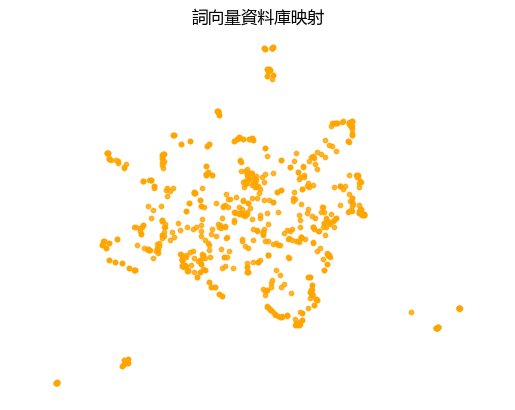

In [32]:
ACP_AD_VIS(projected_dataset_embeddings)

* ### query 詞向量化, 擷取文件的詞向量化

In [33]:
## 以相似度擷取文件
query = "任何人都可以進行「預立醫療照護諮商」 及「預立醫療決定」嗎?"

## 依據 query 擷取 k篇文件(by 相似度), 
docs = vectordb.similarity_search(query,k=3)

## 依據 query 所擷取出的文件內容(by 相似度)
for document in docs:
    print("######: \n", document.page_content)
    print("\n")

######: 
 什麼是「預立醫療決定書」  (AD) ? 
「預立醫療決定書」 (AD)是指經過「預立醫療照護諮商」 (ACP)後，已經清楚瞭解  
「病人自主權利法」裡面規定，賦予病人預先表達在符合特定臨床條件的情況
時，接受或拒絕維持生命治療，或人 工營養及流體餵養的正式書面文件。所以申
請「預立醫療決定書」 ，必須先經過「預立醫療照護諮商」的程序，才能成立。  
 
申請「預立醫療決定書」  (AD) 需要那些資格或條件限制 ? 
1. 具有行為能力的人 (例如 20歲以上，或未成年但結婚的人 )。 
2. 有健保卡的人 (外籍人士有健保卡也可以簽 )。 
3. 心智清楚，不是被強迫來簽 。 
 
   「預立醫療照護諮商」 ( ACP)申請流程 ? 
步驟一：邀請尋找 2位必要陪同參與親友，並且預約醫院的「預立醫療照護諮
商」門診  
諮商團隊成員會向您 (意願人 )及參與者 (參與的親友 )做下列的說明：  
依病人自主權利法的規定，我會有那些「知情、選擇與決定權」？  
可以終止、撤除或不施行「維持生命治療」或「人工營養及流體餵養」所應符合
的特定臨床條件有哪些？


######: 
 (2) 無法出門的失能長者，透過居家失能個案家庭醫師方案，由醫師到宅協助進行「預立醫療照護諮商」服務
(3) 經確診之癌症病人可免費進行「預立醫療照護諮商」(目前持續規劃確認中)
Ｑ：如果我簽署預立醫療決定，以後我生病住院的話，醫護人員會不會就直接放棄 不救我了」？
Ａ：不會，經由「預立醫療決定」簽署後，當上述五款「臨床條件病人」發生時，您的預立醫療決定才會被啟動與執行，而是否符合這五款的條件，必須經過兩位專科醫師、至少二次緩和醫療團隊照會評估，其過程非常謹慎，不可能因立下預立醫療決定，而讓原有治癒機會的患者因而被提前放棄治療。
Ｑ：醫療進展快速，若現在治不好的疾病以後有機會根癒，想改變決定怎麼辦？
Ａ：可以隨時撤回或變更AD，如果改變決定，須向醫療機構提供變更，並再次註記在健保卡。
Ｑ：「預立醫療決定」跟安樂死有什麼不同?
Ａ：病人自主權利法不是安樂死，病人衡量自我生命品質價值觀後，可自主決定拒絕 透過人工或儀器介入來維繫生命，醫師則在尊重「末期病人」意願下中止醫療，讓病人自然地走。
Ｑ：簽署「預立醫療決定」要找見證人，所以我要找到見證人一起去醫院嗎？


###

In [34]:
def Query_ACP_AD_VIS(query, docs, projected_dataset_embeddings):
    """顯示query 及相關文件在資料庫中的2維空間位置"""
    ## query 及擷取資料向量化and降維, 
    query_embedding = embedding.embed_query(query)                ## query 的詞向量

    ## 擷取出來的各篇文件(頁)內容詞向量化
    results = [embedding.embed_query(doc.page_content) for doc in docs]
    retrieved_embeddings = results                                ## 所擷取的文件內容詞向量

    ## 降維映射...
    projected_query_embedding = project_embeddings([query_embedding], umap_transform)           ## query
    projected_retrieved_embeddings = project_embeddings(retrieved_embeddings, umap_transform)   ## retrived data

    import matplotlib.pyplot as plt

    # 指定默認字形：解決 plot不能顯示中文問題
    from pylab import mpl
    mpl.rcParams['font.sans-serif'] = ['Microsoft YaHei']
    #plt.rcParams['font.sans-serif'] = ['SimSun']               ##  plt中文顯示設定, 要電腦中有的字體, SimSun宋體,
    mpl.rcParams['axes.unicode_minus'] = False
    
    # Plot the projected query and retrieved documents in the embedding space
    plt.figure()

    ## vector data space
    plt.scatter(projected_dataset_embeddings[:, 0], projected_dataset_embeddings[:, 1], s=10, color='orange')

    ## query and reyrived embeddings
    plt.scatter(projected_query_embedding[:, 0], projected_query_embedding[:, 1], s=80, marker='X', color='r')
    plt.scatter(projected_retrieved_embeddings[:, 0], projected_retrieved_embeddings[:, 1], s=100, 
                facecolors='none', edgecolors='g')

    plt.gca().set_aspect('equal', 'datalim')
    plt.title(f'{query}')
    plt.axis('off')   

100%|████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:04<00:00,  1.34s/it]


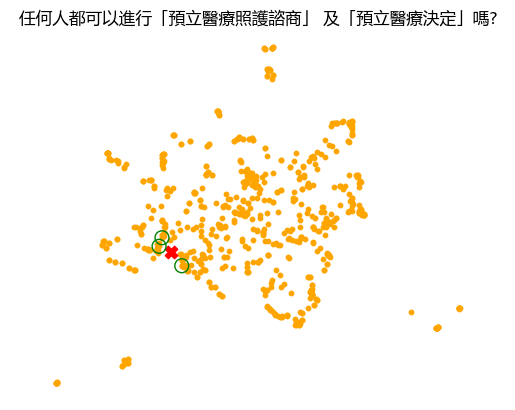

In [35]:
## 顯示, text vectordb
Query_ACP_AD_VIS(query, docs, projected_dataset_embeddings)

* ### Note the difference in results with `MMR`.

In [36]:
## 以 MMR方式擷取文件
query = "任何人都可以進行「預立醫療照護諮商」 及「預立醫療決定」嗎?"

docs_mmr = vectordb.max_marginal_relevance_search(query,k=5)
## k=3似乎略少

for document in docs_mmr:
    print(f"**{'-' * 20}** \n", document.page_content)
    print("\n")

**--------------------** 
 什麼是「預立醫療決定書」  (AD) ? 
「預立醫療決定書」 (AD)是指經過「預立醫療照護諮商」 (ACP)後，已經清楚瞭解  
「病人自主權利法」裡面規定，賦予病人預先表達在符合特定臨床條件的情況
時，接受或拒絕維持生命治療，或人 工營養及流體餵養的正式書面文件。所以申
請「預立醫療決定書」 ，必須先經過「預立醫療照護諮商」的程序，才能成立。  
 
申請「預立醫療決定書」  (AD) 需要那些資格或條件限制 ? 
1. 具有行為能力的人 (例如 20歲以上，或未成年但結婚的人 )。 
2. 有健保卡的人 (外籍人士有健保卡也可以簽 )。 
3. 心智清楚，不是被強迫來簽 。 
 
   「預立醫療照護諮商」 ( ACP)申請流程 ? 
步驟一：邀請尋找 2位必要陪同參與親友，並且預約醫院的「預立醫療照護諮
商」門診  
諮商團隊成員會向您 (意願人 )及參與者 (參與的親友 )做下列的說明：  
依病人自主權利法的規定，我會有那些「知情、選擇與決定權」？  
可以終止、撤除或不施行「維持生命治療」或「人工營養及流體餵養」所應符合
的特定臨床條件有哪些？


**--------------------** 
 (2) 無法出門的失能長者，透過居家失能個案家庭醫師方案，由醫師到宅協助進行「預立醫療照護諮商」服務
(3) 經確診之癌症病人可免費進行「預立醫療照護諮商」(目前持續規劃確認中)
Ｑ：如果我簽署預立醫療決定，以後我生病住院的話，醫護人員會不會就直接放棄 不救我了」？
Ａ：不會，經由「預立醫療決定」簽署後，當上述五款「臨床條件病人」發生時，您的預立醫療決定才會被啟動與執行，而是否符合這五款的條件，必須經過兩位專科醫師、至少二次緩和醫療團隊照會評估，其過程非常謹慎，不可能因立下預立醫療決定，而讓原有治癒機會的患者因而被提前放棄治療。
Ｑ：醫療進展快速，若現在治不好的疾病以後有機會根癒，想改變決定怎麼辦？
Ａ：可以隨時撤回或變更AD，如果改變決定，須向醫療機構提供變更，並再次註記在健保卡。
Ｑ：「預立醫療決定」跟安樂死有什麼不同?
Ａ：病人自主權利法不是安樂死，病人衡量自我生命品質價值觀後，可自主決定拒絕 透過人工或儀器介入來維繫生命，醫師則在尊重「末期病人」意願下中止醫療，讓病人自然地走。
Ｑ：簽署「預

100%|████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:07<00:00,  1.45s/it]


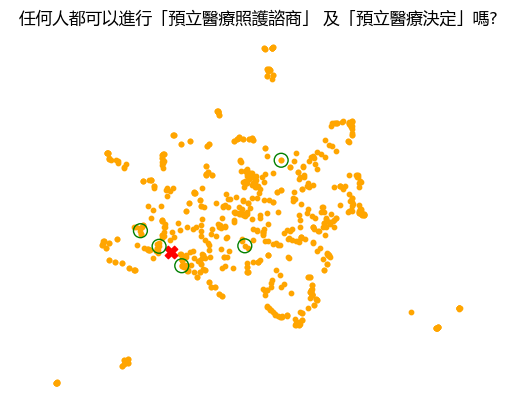

In [37]:
## show figure, text loader
Query_ACP_AD_VIS(query, docs_mmr, projected_dataset_embeddings)

100%|████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:04<00:00,  1.25it/s]


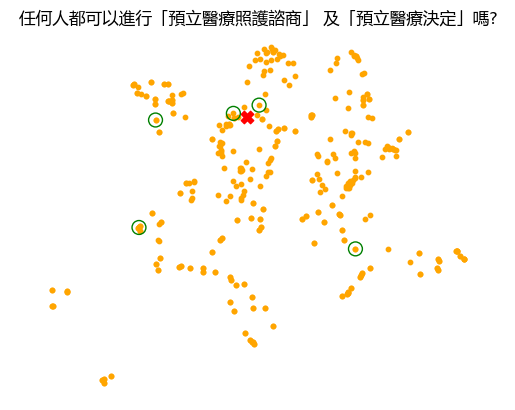

In [27]:
## show figure, txt splits
#Query_ACP_AD_VIS(query, docs_mmr, projected_dataset_embeddings)

100%|████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:04<00:00,  1.14it/s]


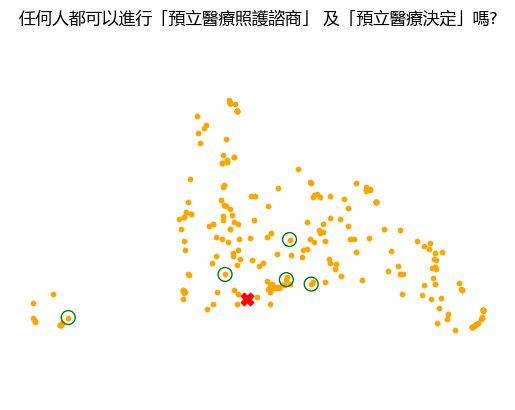

In [26]:
## show figure, pdf
#Query_ACP_AD_VIS(query, docs_mmr, projected_dataset_embeddings)

* ### 以ContextualCompressionRetrieverr方式,  LLMChainFilter擷取資料, need LLM 

In [38]:
import os

from dotenv import load_dotenv, find_dotenv
_ = load_dotenv(find_dotenv())                   # read local .env file, 不需要與程式在同一目錄內

In [39]:
query = "任何人都可以進行「預立醫療照護諮商」 及「預立醫療決定」嗎?"

## 擷取文件, LLM compression retrived data
k=10
#retriever = vectordb.as_retriever(search_type = "mmr", search_kwargs={"k":k})  ## default 為  similarity, k=4                    
retriever = vectordb.as_retriever(search_kwargs={"k":k})

### compression_retriever ### 
from langchain_openai import OpenAI
from langchain.retrievers import ContextualCompressionRetriever
from langchain.retrievers.document_compressors import LLMChainFilter
from langchain.retrievers.document_compressors import LLMChainExtractor
    
llm = OpenAI(temperature=0.0)
#llm_filter = LLMChainFilter.from_llm(llm)      ## filter 方式擷取內容
compressor = LLMChainExtractor.from_llm(llm)    ## 具摘錄及總結功能, 字句較少
compression_retriever_0 = ContextualCompressionRetriever(
                        #base_compressor=llm_filter, 
                        base_compressor=compressor,
                        base_retriever=retriever,
                        )  

## 擷取出來的各篇文件(頁)內容詞向量化
compressed_docs = compression_retriever_0.get_relevant_documents(query)

## 列印所擷取的資料
print(f"\n{'-' * 80}\n".join([f"Document {i+1}:\n\n" + d.page_content for i, d in enumerate(compressed_docs)]))   



Document 1:

- 「預立醫療照護諮商」 ( ACP)申請流程 ? 
- 依病人自主權利法的規定，我會有那些「知情、選擇與決定權」？  
- 可以終止、撤除或不施行「維持生命治療」或「人工營養及流體餵養」所應符合的特定臨床條件有哪些？
--------------------------------------------------------------------------------
Document 2:

(3) 經確診之癌症病人可免費進行「預立醫療照護諮商」(目前持續規劃確認中)
Ｑ：如果我簽署預立醫療決定，以後我生病住院的話，醫護人員會不會就直接放棄 不救我了」？
Ａ：不會，經由「預立醫療決定」簽署後，當上述五款「臨床條件病人」發生時，您的預立醫療決定才會被啟動與執行，而是否符合這五款的條件，必須經過兩位專科醫師、至少二次緩和醫療
--------------------------------------------------------------------------------
Document 3:

- Ｑ：我的家屬已經中風了，現在在養護中心可以簽署「預立醫療決定」嗎？
- Ａ：原則上只要您的家屬意識清楚且可以表達意願，在沒有心智缺陷或非出於自願的疑 慮下，需邀請二親等家屬及醫療委任代理人（若無醫療委任代理人則二親等家屬即可），共同參與預立醫療照護諮商及簽署預立醫療決定書。
--------------------------------------------------------------------------------
Document 4:

1.建議應簽署，因「預立醫療決定」除了保障末期病人，還擴大到上面所提的四種臨床條件病人，且拒絕醫療的範圍還包括，不接受鼻胃管灌食等延命措施範圍，建議簽過安寧意願書的人還是要簽預立醫療決定。
2.當疑似發生上面所提「五種臨床條件病人」時，會經由兩位專科醫師、至少二次緩和醫療團隊照會評估，確認符合上述 5 種臨床條件
--------------------------------------------------------------------------------
Document 5:

政府在 2019年1月6日公布實施《病人自主權利法》 。 
此為亞洲第

100%|██████████████████████████████████████████████████████████████████████████████████| 10/10 [00:14<00:00,  1.47s/it]


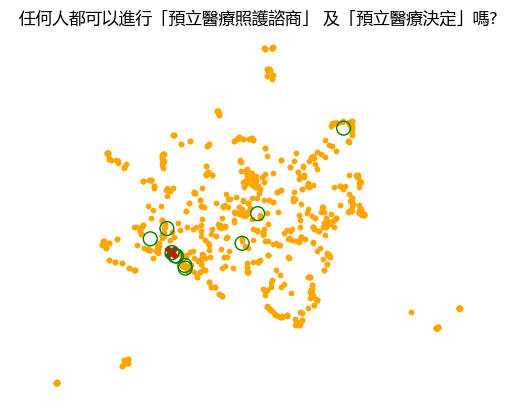

In [40]:
## show figure
Query_ACP_AD_VIS(query, compressed_docs, projected_dataset_embeddings)

* ## 4. Retriever

* ### get vector DB

In [1]:
## 取得 vector db ###
from langchain.vectorstores import Chroma
from langchain_openai import OpenAIEmbeddings
from langchain_community.embeddings import HuggingFaceEmbeddings

#embedding = OpenAIEmbeddings()
embedding = HuggingFaceEmbeddings()    

persist_directory = "./Data_test/VectorDB/預立醫療"                ## pdf 詞向量庫
#persdocist_directory = "./Data_test/VectorDB/預立醫療txt"
#persdocist_directory = "./Data_test/VectorDB/預立醫療_txt"
vectordb = Chroma(
    persist_directory=persist_directory,
    embedding_function=embedding
)


* ### 使用 ContextualCompressionRetriever (三種方式, 考慮用LLMChainFilter, 但似乎與一般retriver效果相當)

In [2]:
## Chroma retriever 方式, as base 

query = "任何人都可以進行「預立醫療照護諮商」 及「預立醫療決定」嗎?"

## 擷取文件, LLM compression retrived data
k=5
retriever = vectordb.as_retriever(search_type = "mmr", search_kwargs={"k":k})  ## default 為similarity, k=4                    
    

In [3]:
retriever

VectorStoreRetriever(tags=['Chroma', 'HuggingFaceEmbeddings'], vectorstore=<langchain_community.vectorstores.chroma.Chroma object at 0x000001DB704E3BE0>, search_type='mmr', search_kwargs={'k': 5})

In [21]:
query = "任何人都可以進行「預立醫療照護諮商」 及「預立醫療決定」嗎?"

## 擷取文件, LLM compression retrived data
k=10
retriever = vectordb.as_retriever(search_type = "mmr", search_kwargs={"k":k})  ## default 為  similarity, k=4                    
    
### compression_retriever ### need LLM
from langchain_openai import OpenAI
from langchain.retrievers import ContextualCompressionRetriever
from langchain.retrievers.document_compressors import LLMChainFilter
from langchain.retrievers.document_compressors import LLMChainExtractor

    
llm = OpenAI(temperature=0.0)
#llm_filter = LLMChainFilter.from_llm(llm)                    ## filter 方式擷取內容
compressor = LLMChainExtractor.from_llm(llm)                  ## 具摘錄及總結功能, 字句較少
compression_retriever = ContextualCompressionRetriever(
                        #base_compressor=llm_filter,          ## filter 方式擷取內容
                        base_compressor=compressor,
                        base_retriever=retriever,
                        ) 

## 擷取出來的各篇文件(頁)內容
compressed_docs = compression_retriever.get_relevant_documents(query)

## 列印所擷取的資料
print(f"\n{'-' * 80}\n".join([f"Document {i+1}:\n\n" + d.page_content for i, d in enumerate(compressed_docs)]))   



#### EmbeddingsFilter

In [78]:
## 內容多了向量資料, 使用embedding時, 需只取出 page_context, 否則meta資料太多 ...; 
from langchain.retrievers.document_compressors import EmbeddingsFilter
from langchain_openai import OpenAIEmbeddings

embedding = OpenAIEmbeddings()              
embeddings_filter = EmbeddingsFilter(embeddings=embedding, similarity_threshold=0.76)
compression_retriever_1 = ContextualCompressionRetriever(
    base_compressor=embeddings_filter, 
    base_retriever=retriever
)

In [81]:
compressed_docs

[_DocumentWithState(page_content='請「預立醫療決定書」 ，必須先經過「預立醫療照護諮商」的程序，才能成立。  \n \n申請「預立醫療決定書」  (AD) 需要那些資格或條件限制 ? \n1. 具有行為能力的人 (例如 20歲以上，或未成年但結婚的人 )。 \n2. 有健保卡的人 (外籍人士有健保卡也可以簽 )。 \n3. 心智清楚，不是被強迫來簽 。', metadata={'page': 0, 'source': './Data_test/預立醫療資料\\預立醫療步驟.pdf'}, state={'embedded_doc': [0.02097578266283637, 0.0030978065149884363, 0.01775575891304616, -0.04090864417697283, -0.023009482069298107, 0.016921420503970035, -0.0035198642319672706, -0.003813186154285103, -0.02675096825608352, -0.003660006866097616, 0.01057914790981818, 0.010729067568830072, -0.02057165011235545, 0.010148942051222977, -0.022501058149005295, 0.01625655859763676, 0.02410455169687183, -0.01822507473381279, 0.016986603774255746, -0.012169604803627573, -0.009171201378840912, 0.017703614159462835, -0.008708404816425475, -0.0031303976844699807, 0.007417788171962487, 0.011035426145205045, 0.017195188376524777, -0.016647654494060537, -0.004308574584674051, -0.014926831991002346, 0.011504741034649053, 0.0020369585699760236

In [79]:
compressed_docs = compression_retriever_1.get_relevant_documents(query)

## 列印所擷取的資料
print(f"\n{'-' * 80}\n".join([f"Document {i+1}:\n\n" + d.page_content for i, d in enumerate(compressed_docs)]))   


Document 1:

請「預立醫療決定書」 ，必須先經過「預立醫療照護諮商」的程序，才能成立。  
 
申請「預立醫療決定書」  (AD) 需要那些資格或條件限制 ? 
1. 具有行為能力的人 (例如 20歲以上，或未成年但結婚的人 )。 
2. 有健保卡的人 (外籍人士有健保卡也可以簽 )。 
3. 心智清楚，不是被強迫來簽 。
--------------------------------------------------------------------------------
Document 2:

Q1：哪邊可以拿到預立醫療決定的表格？是不是簽
名就可以？  
 
A：提供 AD網站簽署前也必須與醫療團隊共同進行
「預立醫療照護諮商」會議，討論各項醫療選項的成
效與風險，透過溝通與決策過程，以書面形式完成您
的「預立醫療決定」。另外，還需完成健保 IC卡註
記，您的「預立醫療決定」才具法律效力。  
  
  
Q2：任何人都可以進行「預立醫療照護諮商」  及
「預立醫療決定」嗎？  
  
A：滿 20歲具有完全行為能力者皆可，只要您：   
1.  至醫療機構完成「預立醫療照護諮商」，並經兩
人以上在場見證或公證程序。  
2.  完成健保 IC卡註記，您的「預立醫療決定」即具
有法律效力。  
  
 
Q3：我想帶我媽去參加預立醫療決定諮商，我要怎
麼跟她說？
--------------------------------------------------------------------------------
Document 3:

「預立醫療照護諮商」 ( ACP)申請流程 ? 
步驟一：邀請尋找 2位必要陪同參與親友，並且預約醫院的「預立醫療照護諮
商」門診  
諮商團隊成員會向您 (意願人 )及參與者 (參與的親友 )做下列的說明：  
依病人自主權利法的規定，我會有那些「知情、選擇與決定權」？  
可以終止、撤除或不施行「維持生命治療」或「人工營養及流體餵養」所應符合
的特定臨床條件有哪些？  
預立醫療決定書的「內容及其生效的法律程序」是 什麼？  
預立醫療決定書的「更改或撤回方式」是什麼？  
 
步驟二：簽署預立醫療決定書  
完成「預立醫療照護諮商」 ，不代表完成預立醫療決定喔 ~ 
發言別忘了簽妥「預立醫

* ### MultiQueryRetriever
* #### 產生多個query 及 隨之而來的docs

In [31]:
from langchain.retrievers.multi_query import MultiQueryRetriever
from langchain_openai import ChatOpenAI

query = "任何人都可以進行「預立醫療照護諮商」 及「預立醫療決定」嗎?"

llm = ChatOpenAI(temperature=0)
retriever_from_llm = MultiQueryRetriever.from_llm(
    retriever=vectordb.as_retriever(), llm=llm
)


In [33]:
# Set logging for the queries
import logging

logging.basicConfig()
logging.getLogger("langchain.retrievers.multi_query").setLevel(logging.INFO)

## 得到文件..
docs_query = retriever_from_llm.get_relevant_documents(query=query, k=5)
len(docs_query)

## get 3 questions and 5 docs

INFO:langchain.retrievers.multi_query:Generated queries: ['1. 可以進行「預立醫療照護諮商」和「預立醫療決定」的人有哪些？', '2. 誰有資格進行「預立醫療照護諮商」和「預立醫療決定」？', '3. 哪些人可以參與「預立醫療照護諮商」和「預立醫療決定」的過程？']


5

In [38]:
docs_query

[Document(page_content='Q1：哪邊可以拿到預立醫療決定的表格？是不是簽\n名就可以？  \n \nA：提供 AD網站簽署前也必須與醫療團隊共同進行\n「預立醫療照護諮商」會議，討論各項醫療選項的成\n效與風險，透過溝通與決策過程，以書面形式完成您\n的「預立醫療決定」。另外，還需完成健保 IC卡註\n記，您的「預立醫療決定」才具法律效力。  \n  \n  \nQ2：任何人都可以進行「預立醫療照護諮商」  及\n「預立醫療決定」嗎？  \n  \nA：滿 20歲具有完全行為能力者皆可，只要您：   \n1.  至醫療機構完成「預立醫療照護諮商」，並經兩\n人以上在場見證或公證程序。  \n2.  完成健保 IC卡註記，您的「預立醫療決定」即具\n有法律效力。  \n  \n \nQ3：我想帶我媽去參加預立醫療決定諮商，我要怎\n麼跟她說？', metadata={'page': 0, 'source': './Data_test/預立醫療資料\\QAs.pdf'}),
 Document(page_content='3.「預立醫療決定書」填寫範例說明：', metadata={'page': 1, 'source': './Data_test/預立醫療資料\\臺北市立聯合醫院-什麼是預立醫療決定-什麼是預立醫療決定書？.pdf'}),
 Document(page_content='看完覺得內容複雜嗎？沒關係，您還需要到醫療機構去完成「預立醫療照', metadata={'page': 3, 'source': './Data_test/預立醫療資料\\臺北市立聯合醫院-什麼是預立醫療決定-什麼是預立醫療決定書？.pdf'}),
 Document(page_content='諮商團隊成員會向您 ( 意願⼈ ) 及參與者 ( 參與的親友 ) 做下列的說明：\n依病⼈⾃主權利法的規定，我會有那些「知情、選擇與決定權」？\n可以終⽌、撤除或不施⾏「維持⽣命治療」或「⼈⼯營養及流體餵養」所應符合的特定臨床條\n件有哪些？\n預立醫療決定書的「內容及其⽣效的法律程序」是什麼？\n預立醫療決定書的「更改或撤回⽅式」是什麼？\n \n醫療委任代理⼈是做什麼的 ? 終⽌委任或解除委任的相關規定 ?', metadata={'page': 2, 'sourc

In [35]:
print(docs_query[0].page_content)

Q1：哪邊可以拿到預立醫療決定的表格？是不是簽
名就可以？  
 
A：提供 AD網站簽署前也必須與醫療團隊共同進行
「預立醫療照護諮商」會議，討論各項醫療選項的成
效與風險，透過溝通與決策過程，以書面形式完成您
的「預立醫療決定」。另外，還需完成健保 IC卡註
記，您的「預立醫療決定」才具法律效力。  
  
  
Q2：任何人都可以進行「預立醫療照護諮商」  及
「預立醫療決定」嗎？  
  
A：滿 20歲具有完全行為能力者皆可，只要您：   
1.  至醫療機構完成「預立醫療照護諮商」，並經兩
人以上在場見證或公證程序。  
2.  完成健保 IC卡註記，您的「預立醫療決定」即具
有法律效力。  
  
 
Q3：我想帶我媽去參加預立醫療決定諮商，我要怎
麼跟她說？


* ## 5. 理想答案資料庫, for系統建置時 model評估

* ### 評估用標準答案

In [43]:
## 標準問答對組合
# 提問
eval_queries = [
    "哪邊可以拿到預立醫療決定的表格？是不是簽名就可以？",
    "任何人都可以進行「預立醫療照護諮商」 及「預立醫療決定」嗎？",
    "我想帶我媽去參加預立醫療決定諮商，我要怎麼跟她說？",
    "我爸中風7年了，在養護中心可以簽預立醫療決定嗎？",
    "預立醫療照護諮商需要多久時間呢？",
    "兩位或兩位以上的意願人能否在同一次諮商中，一起完成預立醫療照護諮商？",
    "做了「預立醫療決定」後，是否發生明明還有治癒機會，或遭逢意外，卻被醫師提前放棄治療的情況？",
    "「預立醫療決定書」上傳註記後還能修改嗎？",
    "預立醫療決定書上為什麼需要見證人？",
    "誰可以擔任見證人？(外籍看護可以嗎？)",
    "誰不能擔任見證人？",
    "見證人要擔負什麼責任？",
    "如果沒有見證人，可以怎麼做？",
    "聽說預立醫療決定還要找見證人，所以我要找到見證人一起去醫院做預立醫療照護諮商嗎？",
    "做完預立醫療照護諮商(ACP)後，一定要填寫預立醫療決定書(AD)嗎？一定要當下完成並繳回嗎？",
    "拒絕人工營養及流體餵養，那是要將病人餓死、渴死嗎？",
    "如果我的二親等有事無法到門診參加預立醫療諮商，該怎麼辦？",    
]

# 理想答案
eval_answers = [
    "提供AD網站簽署前也必須與醫療團隊共同進行「預立醫療照護諮商」會議，討論各項醫療選項的成效與風險，透過溝通與決策過程，以書面形式完成您的「預立醫療決定」。另外，還需完成健保IC卡註記，您的「預立醫療決定」才具法律效力。", 
    "滿20歲具有完全行為能力者皆可，只要您： \
    1.至醫療機構完成「預立醫療照護諮商」，並經兩人以上在場見證或公證程序。\
    2.完成健保IC卡註記，您的「預立醫療決定」即具有法律效力。",
    "您可透過新聞報導、社會重大事件等話題，試著在聊天中找到討論時機，先聊聊自己對生命與死亡之體悟，鼓勵媽媽分享她的感受及想法，觀察媽媽反應。若媽媽不排斥，願意表達所期待的醫療照顧或身心靈需求，則可邀請她參加「預立醫療照護諮商」；並請告訴她，這是由醫師、護理師、社工師組成的諮商團隊，提供醫療、社會、家庭與心理的討論；諮商過後不一定要簽署「預立醫療決定」，但可透過諮商過程，讓媽媽有機會更清楚的思考與表達想法，也讓您有機會事先瞭解媽媽的期待。", 
    "原則上只要您的父親意識清楚且可以表達意願，以及在沒有心智缺陷或非出於自願的疑慮下，是可以邀請二親等家屬或醫療委任代理人，共同參與預立醫療照護諮商及簽署預立醫療決定的。", 
    "為了說明預立醫療意願書內涵並意願人的想法，推估約要半小時到一小時。", 
    "若當意願人及其家屬為彼此的二等親及醫療委任代理人，是可以一同完成預立醫療照護諮商。",
    "不會。須經由二位具相關專科醫師資格之醫師確診已符合條文所明定之臨床條件，並經緩和醫療團隊至少二次照會，才可執行預立醫療決定，不符合臨床條件者，應先予適當急救或採取必要措施，不得無故拖延；其過程非常謹慎，且經重重把關，不可能因立下預立醫療決定，而讓原有治癒機會的患者因而被提前放棄治療。",
    "意願人想撤回或變更預立醫療決定時，需要重新簽署預立醫療決定書，並向中央主管機關申請更新註記。",
    "為了保障個人簽署預立醫療決定書是出於自願、並無遭受外力脅迫等情況所決定。",
    "見證人除了不是意願人所指定之醫療委任代理人、主責照護醫療團隊成員、以及繼承人之外的受遺贈人、遺體或器官指定之受贈人、其他因意願人死亡而獲得利益者，剩下的人都可以擔任見證人。",
    "意願人所指定之醫療委任代理人、主責照護醫療團隊成員、以及繼承人之外的受遺贈人、遺體或器官指定之受贈人、其他因意願人死亡而獲得利益者，都不能擔任見證人。",
    "見證意願人簽署當下意識清楚、出於自願未受脅迫下簽署；不涉及醫療決策。",
    "可以找公證人。", 
    "不一定。病人自主權利法規定在預立醫療決定上簽名時有二名以上滿20歲具完全行為能力人在場見證或經公證人公證即可。若您的親友無法擔任見證人，您可事先告知醫療機構，有些機構或許協助安排。請特別注意，您的醫療委任代理人是無法做見證人。",
    "來參加ACP不一定要簽署AD喔。能與自己跟親友一起思考、探索生命議題的過程很有意義。您的醫療決定必須讓家人知道，才能當你意識不清的時候幫你實現。",
    "不是的！還可以慢慢從口餵食啊，過多水份養分其實造成額外負擔，末期病人並不會感到飢餓，餵食反而會造成嘔吐、食物進入氣管造成窒息等後果，若病人無法配合，掙扎甚至四肢約束、強迫裝置鼻胃管進行人工管灌，反更加痛苦。",
    "可以使用視訊參與預立醫療諮商，與醫療團隊共同了解您對生命真實想法與期待，確保預立醫療決定的實踐。",
]

## built idea answers pair...
ideaAnswers = [
    {"query": q, "answer": eval_answers[i]}
    for i, q in enumerate(eval_queries)
]

len(eval_queries), len(eval_answers)

In [45]:
## 核對
ideaAnswers

[{'query': '哪邊可以拿到預立醫療決定的表格？是不是簽名就可以？',
  'answer': '提供AD網站簽署前也必須與醫療團隊共同進行「預立醫療照護諮商」會議，討論各項醫療選項的成效與風險，透過溝通與決策過程，以書面形式完成您的「預立醫療決定」。另外，還需完成健保IC卡註記，您的「預立醫療決定」才具法律效力。'},
 {'query': '任何人都可以進行「預立醫療照護諮商」 及「預立醫療決定」嗎？',
  'answer': '滿20歲具有完全行為能力者皆可，只要您：     1.至醫療機構完成「預立醫療照護諮商」，並經兩人以上在場見證或公證程序。    2.完成健保IC卡註記，您的「預立醫療決定」即具有法律效力。'},
 {'query': '我想帶我媽去參加預立醫療決定諮商，我要怎麼跟她說？',
  'answer': '您可透過新聞報導、社會重大事件等話題，試著在聊天中找到討論時機，先聊聊自己對生命與死亡之體悟，鼓勵媽媽分享她的感受及想法，觀察媽媽反應。若媽媽不排斥，願意表達所期待的醫療照顧或身心靈需求，則可邀請她參加「預立醫療照護諮商」；並請告訴她，這是由醫師、護理師、社工師組成的諮商團隊，提供醫療、社會、家庭與心理的討論；諮商過後不一定要簽署「預立醫療決定」，但可透過諮商過程，讓媽媽有機會更清楚的思考與表達想法，也讓您有機會事先瞭解媽媽的期待。'},
 {'query': '我爸中風7年了，在養護中心可以簽預立醫療決定嗎？',
  'answer': '原則上只要您的父親意識清楚且可以表達意願，以及在沒有心智缺陷或非出於自願的疑慮下，是可以邀請二親等家屬或醫療委任代理人，共同參與預立醫療照護諮商及簽署預立醫療決定的。'},
 {'query': '預立醫療照護諮商需要多久時間呢？', 'answer': '為了說明預立醫療意願書內涵並意願人的想法，推估約要半小時到一小時。'},
 {'query': '兩位或兩位以上的意願人能否在同一次諮商中，一起完成預立醫療照護諮商？',
  'answer': '若當意願人及其家屬為彼此的二等親及醫療委任代理人，是可以一同完成預立醫療照護諮商。'},
 {'query': '做了「預立醫療決定」後，是否發生明明還有治癒機會，或遭逢意外，卻被醫師提前放棄治療的情況？',
  'answer': '不會。須

* ### LLM-Generated examples, LLM 生成問答對

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [4]:
import os
import openai
import sys
sys.path.append('../..')

from dotenv import load_dotenv, find_dotenv
_ = load_dotenv(find_dotenv()) # read local .env file

openai.api_key  = os.environ['OPENAI_API_KEY']

* #### 逐頁生成 LLM examples(問答對)

In [40]:
## 取得 vector db ###
from langchain.vectorstores import Chroma
from langchain_openai import OpenAIEmbeddings
from langchain_community.embeddings import HuggingFaceEmbeddings

#embedding = OpenAIEmbeddings()
embedding = HuggingFaceEmbeddings()    

persist_directory = "../Data_test/VectorDB/預立醫療"
#persist_directory = "../Data_test/VectorDB/預立醫療"

vectordb = Chroma(
    persist_directory=persist_directory,
    embedding_function=embedding
)

#取出所有 splits_doc, check 數量, 或設定MAX
splits_doc = vectordb.similarity_search("", k = 1000)

print(len(splits_doc))

In [41]:
#splits_doc[1]

Document(page_content='預立醫療⾃主計畫的精神，做好⻑期、定期思考⾃⼰的計畫，畢竟計畫與安排也會因臨時狀況或\n其他因素做滾動式調整，因此建議定期檢視原來的醫療照護計畫是否有需要調整的地⽅，並且適\n時告知親友或醫療團隊、讓⼤家⼀起做好安排，讓⾃⼰的⼼願得以落實。\n點閱數：77088| 資料更新： 112-09-20 15:19| 資料檢視： 112-09-20 15:19\n| 資料維護：臺北市立聯合醫院', metadata={'page': 6, 'source': './Data_test/預立醫療資料\\臺北市立聯合醫院-預立醫療照護諮商服務-什麼是預立醫療照護諮商_.pdf'})

In [46]:
from langchain.evaluation.qa import QAGenerateChain
from langchain_openai import ChatOpenAI

## 經修改原package所在位置的prompttemplate後可以輸出繁體中文
example_gen_chain = QAGenerateChain.from_llm(ChatOpenAI(model="gpt-3.5-turbo"))

## 隨機生成examples(問答對), 逐頁生成答案
import random

k = 5                                                                                  ## 生成問答對的數量   
#random_integers = [random.randint(0, len(splits_doc)) for _ in range(num_integers)]   ## 隨機整數, 但數值可能重複...
random_integers = random.sample(range(len(splits_doc)), k)                             ## range, 以及產生k個隨機整數
                                  
llm_examples = []
for i in random_integers:                                                            
    llm_examples_i = example_gen_chain.apply_and_parse(
        [{"doc": t} for t in splits_doc[i:i+1]]
    )
    ## Combine examples
    llm_examples += llm_examples_i

# 須從'qa_pairs'取出資料, 
llm_examples = [item['qa_pairs'] for item in llm_examples]

## Combine examples
examples = ideaAnswers.copy()          ## 理想答案
examples += llm_examples               ## AI 生成答案+理想答案

In [47]:
## 輸出略呆, 或可修改原程式
llm_examples

[{'query': '根據這份文件中的問題，當您罹患重病時，您是否希望親近的人知道您的病情？',
  'answer': '根據這份文件中的問題，提到了如果您罹患重病，您是否希望親近的人知道您的病情。您可以選擇「我希望親近的人知道一切病情」或者「我不希望他們知道任何病情」。'},
 {'query': '根據文件中的解釋，什麼是安寧緩和醫療？  ',
  'answer': '根據文件中的解釋，安寧緩和醫療指的是為減輕或免除末期病人的生理、心理及靈性痛苦，施予緩解性、支持性的醫療照護，以增進其生活品質。'},
 {'query': '根據文檔中提到的問題Q2，如果疾病造成您無法照顧自己或不認得外界事物，對自己需要被照顧的想法是什麼？',
  'answer': '根據文檔中提到的問題Q2，疾病造成無法照顧自己或不認得外界事物時，對自己需要被照顧的想法是「需要被照顧」。'},
 {'query': '根據文件提到的「病人自主權利法」，預立醫療照護諮商門診是為了什麼目的？',
  'answer': '預立醫療照護諮商門診是為了尊重病人醫療自主、保障其善終權益，促進醫病關係和諧而制定的，讓病人在特定的醫療情況下做出符合自己意願的決定。'},
 {'query': '根據文件中提供的資訊，這份文件的標題是什麼？', 'answer': '這份文件的標題是「我的預立醫療決定 -心願探索手冊」。'}]

In [49]:
#examples
## 或可轉 dataframe, 再save 為csv...
## 或反向, 建立SQL/CSV 標準答案庫, 再取出為 emamples 格式... 

[{'query': '哪邊可以拿到預立醫療決定的表格？是不是簽名就可以？',
  'answer': '提供AD網站簽署前也必須與醫療團隊共同進行「預立醫療照護諮商」會議，討論各項醫療選項的成效與風險，透過溝通與決策過程，以書面形式完成您的「預立醫療決定」。另外，還需完成健保IC卡註記，您的「預立醫療決定」才具法律效力。'},
 {'query': '任何人都可以進行「預立醫療照護諮商」 及「預立醫療決定」嗎？',
  'answer': '滿20歲具有完全行為能力者皆可，只要您：     1.至醫療機構完成「預立醫療照護諮商」，並經兩人以上在場見證或公證程序。    2.完成健保IC卡註記，您的「預立醫療決定」即具有法律效力。'},
 {'query': '我想帶我媽去參加預立醫療決定諮商，我要怎麼跟她說？',
  'answer': '您可透過新聞報導、社會重大事件等話題，試著在聊天中找到討論時機，先聊聊自己對生命與死亡之體悟，鼓勵媽媽分享她的感受及想法，觀察媽媽反應。若媽媽不排斥，願意表達所期待的醫療照顧或身心靈需求，則可邀請她參加「預立醫療照護諮商」；並請告訴她，這是由醫師、護理師、社工師組成的諮商團隊，提供醫療、社會、家庭與心理的討論；諮商過後不一定要簽署「預立醫療決定」，但可透過諮商過程，讓媽媽有機會更清楚的思考與表達想法，也讓您有機會事先瞭解媽媽的期待。'},
 {'query': '我爸中風7年了，在養護中心可以簽預立醫療決定嗎？',
  'answer': '原則上只要您的父親意識清楚且可以表達意願，以及在沒有心智缺陷或非出於自願的疑慮下，是可以邀請二親等家屬或醫療委任代理人，共同參與預立醫療照護諮商及簽署預立醫療決定的。'},
 {'query': '預立醫療照護諮商需要多久時間呢？', 'answer': '為了說明預立醫療意願書內涵並意願人的想法，推估約要半小時到一小時。'},
 {'query': '兩位或兩位以上的意願人能否在同一次諮商中，一起完成預立醫療照護諮商？',
  'answer': '若當意願人及其家屬為彼此的二等親及醫療委任代理人，是可以一同完成預立醫療照護諮商。'},
 {'query': '做了「預立醫療決定」後，是否發生明明還有治癒機會，或遭逢意外，卻被醫師提前放棄治療的情況？',
  'answer': '不會。須

In [50]:
## 將LLM 生成答案存檔, 可check, 修改, 再成為理想答案

import pandas as pd
pd.set_option('display.max_colwidth', None)

columns = ['Question', 'Answer', 'Remark']

# 使用 pd.DataFrame() 建立 DataFrame
df_LLM = pd.DataFrame(columns=columns)

for i in range(0, len(llm_examples)):
     df_LLM.loc[i]= [llm_examples[i]["query"], llm_examples[i]["answer"], "AI"]

df_LLM

,Question,Answer,Remark
0,根據這份文件中的問題，當您罹患重病時，您是否希望親近的人知道您的病情？,根據這份文件中的問題，提到了如果您罹患重病，您是否希望親近的人知道您的病情。您可以選擇「我希望親近的人知道一切病情」或者「我不希望他們知道任何病情」。,AI
1,根據文件中的解釋，什麼是安寧緩和醫療？,根據文件中的解釋，安寧緩和醫療指的是為減輕或免除末期病人的生理、心理及靈性痛苦，施予緩解性、支持性的醫療照護，以增進其生活品質。,AI
2,根據文檔中提到的問題Q2，如果疾病造成您無法照顧自己或不認得外界事物，對自己需要被照顧的想法是什麼？,根據文檔中提到的問題Q2，疾病造成無法照顧自己或不認得外界事物時，對自己需要被照顧的想法是「需要被照顧」。,AI
3,根據文件提到的「病人自主權利法」，預立醫療照護諮商門診是為了什麼目的？,預立醫療照護諮商門診是為了尊重病人醫療自主、保障其善終權益，促進醫病關係和諧而制定的，讓病人在特定的醫療情況下做出符合自己意願的決定。,AI
4,根據文件中提供的資訊，這份文件的標題是什麼？,這份文件的標題是「我的預立醫療決定 -心願探索手冊」。,AI


In [22]:
# 將 DataFrame 寫入 CSV 檔案
df_LLM.to_csv("LLM_QA.csv", index=False)     # index=False 避免寫入索引列

In [52]:
import pandas as pd

# 從 CSV 讀取資料到 DataFrame
df_LLM = pd.read_csv("LLM_QA.csv")
df_LLM

,Question,Answer,Remark
0,根據文件中的描述，什麼是指「不施行心肺復甦術」和「不施行維生醫療」？,「不施行心肺復甦術」指對臨終、瀕死或無生命徵象之病人不施予氣管內插管、體外心臟按壓、急救藥物注射、心臟電擊、心臟人工調頻、人工呼吸等標準急救程序或其他緊急救治行為。而「不施行維生醫療」指末期病人不施行用以維持生命徵象及延長其瀕死過程的醫療措施。,AI
1,根據文檔中提到的內容，預立醫療決定書中需要多少名見證人？他們的作用是什麼？,預立醫療決定書需要2個18歲以上的見證人。他們的作用是確定簽署者是自願簽署，並證明沒有人強迫他們簽署這份決定書。如果找不到2個見證人，也可以去法院找公證人。,AI
2,在這份文件中，提到了哪個重要的文件？這個文件的縮寫是什麼？,這份文件提到了「預立醫療決定書 (AD)」，其縮寫為AD。,AI
3,What is the source of the document provided in the metadata?,The source of the document is './Data_test/預立醫療資料\\預立醫療照護諮商說明工具(意願人版).pdf' as indicated in the metadata.,AI
4,根據文件中提到的內容，請列舉出極重度失智症中所描述的5種生病情況是什麼？,根據文件中提到的內容，極重度失智症中所描述的5種生病情況包括政府公告的疾病以及無法治好的疾病，例如：1. 罕見疾病 2. 漸凍人 3. 小腦萎縮症 4. 泡泡龍。,AI


In [31]:
## 理想答案 save to CSV
import pandas as pd

columns = ['Question', 'Answer', 'Remark' ]

# 使用 pd.DataFrame() 建立 DataFrame
df_H = pd.DataFrame(columns=columns)

for i in range(0, len(ideaAnswers)):
     df_H.loc[i]= [ideaAnswers[i]["query"], ideaAnswers[i]["answer"], "Human"]

# 將 DataFrame 寫入 CSV 檔案
df_H.to_csv("Human_QA.csv", index=False)     # index=False 避免寫入索引列        
        
df_H 

,Question,Answer,Remark
0,哪邊可以拿到預立醫療決定的表格？是不是簽名就可以？,提供AD網站簽署前也必須與醫療團隊共同進行「預立醫療照護諮商」會議，討論各項醫療選項的成效與...,Human
1,任何人都可以進行「預立醫療照護諮商」 及「預立醫療決定」嗎？,滿20歲具有完全行為能力者皆可，只要您： 1.至醫療機構完成「預立醫療照護諮商」，並...,Human
2,我想帶我媽去參加預立醫療決定諮商，我要怎麼跟她說？,您可透過新聞報導、社會重大事件等話題，試著在聊天中找到討論時機，先聊聊自己對生命與死亡之體悟...,Human
3,我爸中風7年了，在養護中心可以簽預立醫療決定嗎？,原則上只要您的父親意識清楚且可以表達意願，以及在沒有心智缺陷或非出於自願的疑慮下，是可以邀請...,Human
4,預立醫療照護諮商需要多久時間呢？,為了說明預立醫療意願書內涵並意願人的想法，推估約要半小時到一小時。,Human
5,兩位或兩位以上的意願人能否在同一次諮商中，一起完成預立醫療照護諮商？,若當意願人及其家屬為彼此的二等親及醫療委任代理人，是可以一同完成預立醫療照護諮商。,Human
6,做了「預立醫療決定」後，是否發生明明還有治癒機會，或遭逢意外，卻被醫師提前放棄治療的情況？,不會。須經由二位具相關專科醫師資格之醫師確診已符合條文所明定之臨床條件，並經緩和醫療團隊至少...,Human
7,「預立醫療決定書」上傳註記後還能修改嗎？,意願人想撤回或變更預立醫療決定時，需要重新簽署預立醫療決定書，並向中央主管機關申請更新註記。,Human
8,預立醫療決定書上為什麼需要見證人？,為了保障個人簽署預立醫療決定書是出於自願、並無遭受外力脅迫等情況所決定。,Human
9,誰可以擔任見證人？(外籍看護可以嗎？),見證人除了不是意願人所指定之醫療委任代理人、主責照護醫療團隊成員、以及繼承人之外的受遺贈人、...,Human


In [53]:
import pandas as pd

# 從 CSV 讀取資料到 DataFrame
df_H = pd.read_csv("Human_QA.csv")

df_H

,Question,Answer,Remark
0,哪邊可以拿到預立醫療決定的表格？是不是簽名就可以？,提供AD網站簽署前也必須與醫療團隊共同進行「預立醫療照護諮商」會議，討論各項醫療選項的成效與風險，透過溝通與決策過程，以書面形式完成您的「預立醫療決定」。另外，還需完成健保IC卡註記，您的「預立醫療決定」才具法律效力。,Human
1,任何人都可以進行「預立醫療照護諮商」 及「預立醫療決定」嗎？,滿20歲具有完全行為能力者皆可，只要您： 1.至醫療機構完成「預立醫療照護諮商」，並經兩人以上在場見證或公證程序。 2.完成健保IC卡註記，您的「預立醫療決定」即具有法律效力。,Human
2,我想帶我媽去參加預立醫療決定諮商，我要怎麼跟她說？,您可透過新聞報導、社會重大事件等話題，試著在聊天中找到討論時機，先聊聊自己對生命與死亡之體悟，鼓勵媽媽分享她的感受及想法，觀察媽媽反應。若媽媽不排斥，願意表達所期待的醫療照顧或身心靈需求，則可邀請她參加「預立醫療照護諮商」；並請告訴她，這是由醫師、護理師、社工師組成的諮商團隊，提供醫療、社會、家庭與心理的討論；諮商過後不一定要簽署「預立醫療決定」，但可透過諮商過程，讓媽媽有機會更清楚的思考與表達想法，也讓您有機會事先瞭解媽媽的期待。,Human
3,我爸中風7年了，在養護中心可以簽預立醫療決定嗎？,原則上只要您的父親意識清楚且可以表達意願，以及在沒有心智缺陷或非出於自願的疑慮下，是可以邀請二親等家屬或醫療委任代理人，共同參與預立醫療照護諮商及簽署預立醫療決定的。,Human
4,預立醫療照護諮商需要多久時間呢？,為了說明預立醫療意願書內涵並意願人的想法，推估約要半小時到一小時。,Human
5,兩位或兩位以上的意願人能否在同一次諮商中，一起完成預立醫療照護諮商？,若當意願人及其家屬為彼此的二等親及醫療委任代理人，是可以一同完成預立醫療照護諮商。,Human
6,做了「預立醫療決定」後，是否發生明明還有治癒機會，或遭逢意外，卻被醫師提前放棄治療的情況？,不會。須經由二位具相關專科醫師資格之醫師確診已符合條文所明定之臨床條件，並經緩和醫療團隊至少二次照會，才可執行預立醫療決定，不符合臨床條件者，應先予適當急救或採取必要措施，不得無故拖延；其過程非常謹慎，且經重重把關，不可能因立下預立醫療決定，而讓原有治癒機會的患者因而被提前放棄治療。,Human
7,「預立醫療決定書」上傳註記後還能修改嗎？,意願人想撤回或變更預立醫療決定時，需要重新簽署預立醫療決定書，並向中央主管機關申請更新註記。,Human
8,預立醫療決定書上為什麼需要見證人？,為了保障個人簽署預立醫療決定書是出於自願、並無遭受外力脅迫等情況所決定。,Human
9,誰可以擔任見證人？(外籍看護可以嗎？),見證人除了不是意願人所指定之醫療委任代理人、主責照護醫療團隊成員、以及繼承人之外的受遺贈人、遺體或器官指定之受贈人、其他因意願人死亡而獲得利益者，剩下的人都可以擔任見證人。,Human


* ### 將 examples問答對轉為pandas dataframe, 並存為 CSV 資料
* #### examples = Huamn + AI; 或 df_AI, df_H merge 更適合

In [34]:
import pandas as pd

columns = ['Question', 'Answer']

# 使用 pd.DataFrame() 建立 DataFrame
df = pd.DataFrame(columns=columns)

for i in range(0, len(examples)):
     df.loc[i]= [examples[i]["query"], examples[i]["answer"]]

df      

,Question,Answer
0,哪邊可以拿到預立醫療決定的表格？是不是簽名就可以？,提供AD網站簽署前也必須與醫療團隊共同進行「預立醫療照護諮商」會議，討論各項醫療選項的成效與...
1,任何人都可以進行「預立醫療照護諮商」 及「預立醫療決定」嗎？,滿20歲具有完全行為能力者皆可，只要您： 1.至醫療機構完成「預立醫療照護諮商」，並...
2,我想帶我媽去參加預立醫療決定諮商，我要怎麼跟她說？,您可透過新聞報導、社會重大事件等話題，試著在聊天中找到討論時機，先聊聊自己對生命與死亡之體悟...
3,我爸中風7年了，在養護中心可以簽預立醫療決定嗎？,原則上只要您的父親意識清楚且可以表達意願，以及在沒有心智缺陷或非出於自願的疑慮下，是可以邀請...
4,預立醫療照護諮商需要多久時間呢？,為了說明預立醫療意願書內涵並意願人的想法，推估約要半小時到一小時。
5,兩位或兩位以上的意願人能否在同一次諮商中，一起完成預立醫療照護諮商？,若當意願人及其家屬為彼此的二等親及醫療委任代理人，是可以一同完成預立醫療照護諮商。
6,做了「預立醫療決定」後，是否發生明明還有治癒機會，或遭逢意外，卻被醫師提前放棄治療的情況？,不會。須經由二位具相關專科醫師資格之醫師確診已符合條文所明定之臨床條件，並經緩和醫療團隊至少...
7,「預立醫療決定書」上傳註記後還能修改嗎？,意願人想撤回或變更預立醫療決定時，需要重新簽署預立醫療決定書，並向中央主管機關申請更新註記。
8,預立醫療決定書上為什麼需要見證人？,為了保障個人簽署預立醫療決定書是出於自願、並無遭受外力脅迫等情況所決定。
9,誰可以擔任見證人？(外籍看護可以嗎？),見證人除了不是意願人所指定之醫療委任代理人、主責照護醫療團隊成員、以及繼承人之外的受遺贈人、...


In [158]:
# 將 DataFrame 寫入 CSV 檔案
df.to_csv('QA_examples.csv', index=False)  # index=False 避免寫入索引列

In [55]:
import pandas as pd
pd.set_option('display.max_colwidth', None)

# 從 CSV 讀取資料到 DataFrame
df = pd.read_csv('QA_examples.csv')
df
##此版csv需修改

,Question,Answer
0,哪邊可以拿到預立醫療決定的表格？是不是簽名就可以？,提供AD網站簽署前也必須與醫療團隊共同進行「預立醫療照護諮商」會議，討論各項醫療選項的成效與風險，透過溝通與決策過程，以書面形式完成您的「預立醫療決定」。另外，還需完成健保IC卡註記，您的「預立醫療決定」才具法律效力。
1,任何人都可以進行「預立醫療照護諮商」 及「預立醫療決定」嗎？,滿20歲具有完全行為能力者皆可，只要您： 1.至醫療機構完成「預立醫療照護諮商」，並經兩人以上在場見證或公證程序。 2.完成健保IC卡註記，您的「預立醫療決定」即具有法律效力。
2,我想帶我媽去參加預立醫療決定諮商，我要怎麼跟她說？,您可透過新聞報導、社會重大事件等話題，試著在聊天中找到討論時機，先聊聊自己對生命與死亡之體悟，鼓勵媽媽分享她的感受及想法，觀察媽媽反應。若媽媽不排斥，願意表達所期待的醫療照顧或身心靈需求，則可邀請她參加「預立醫療照護諮商」；並請告訴她，這是由醫師、護理師、社工師組成的諮商團隊，提供醫療、社會、家庭與心理的討論；諮商過後不一定要簽署「預立醫療決定」，但可透過諮商過程，讓媽媽有機會更清楚的思考與表達想法，也讓您有機會事先瞭解媽媽的期待。
3,我爸中風7年了，在養護中心可以簽預立醫療決定嗎？,原則上只要您的父親意識清楚且可以表達意願，以及在沒有心智缺陷或非出於自願的疑慮下，是可以邀請二親等家屬或醫療委任代理人，共同參與預立醫療照護諮商及簽署預立醫療決定的。
4,預立醫療照護諮商需要多久時間呢？,為了說明預立醫療意願書內涵並意願人的想法，推估約要半小時到一小時。
5,兩位或兩位以上的意願人能否在同一次諮商中，一起完成預立醫療照護諮商？做了「預立醫療決定」後，是否發生明明還有治癒機會，或遭逢意外，卻被醫師提前放棄治療的情況？,若當意願人及其家屬為彼此的二等親及醫療委任代理人，是可以一同完成預立醫療照護諮商。
6,「預立醫療決定書」上傳註記後還能修改嗎？,不會。須經由二位具相關專科醫師資格之醫師確診已符合條文所明定之臨床條件，並經緩和醫療團隊至少二次照會，才可執行預立醫療決定，不符合臨床條件者，應先予適當急救或採取必要措施，不得無故拖延；其過程非常謹慎，且經重重把關，不可能因立下預立醫療決定，而讓原有治癒機會的患者因而被提前放棄治療。
7,預立醫療決定書上為什麼需要見證人？,意願人想撤回或變更預立醫療決定時，需要重新簽署預立醫療決定書，並向中央主管機關申請更新註記。
8,誰可以擔任見證人？(外籍看護可以嗎？),為了保障個人簽署預立醫療決定書是出於自願、並無遭受外力脅迫等情況所決定。
9,誰不能擔任見證人？見證人要擔負什麼責任？如果沒有見證人，可以怎麼做？聽說預立醫療決定還要找見證人，所以我要找到見證人一起去醫院做預立醫療照護諮商嗎？,見證人除了不是意願人所指定之醫療委任代理人、主責照護醫療團隊成員、以及繼承人之外的受遺贈人、遺體或器官指定之受贈人、其他因意願人死亡而獲得利益者，剩下的人都可以擔任見證人。


In [56]:
# 添加新的資料, if need
new_data = [examples[0]["query"], examples[0]["answer"]]

i = len(df)
df.loc[i] = new_data

In [57]:
df

,Question,Answer
0,哪邊可以拿到預立醫療決定的表格？是不是簽名就可以？,提供AD網站簽署前也必須與醫療團隊共同進行「預立醫療照護諮商」會議，討論各項醫療選項的成效與風險，透過溝通與決策過程，以書面形式完成您的「預立醫療決定」。另外，還需完成健保IC卡註記，您的「預立醫療決定」才具法律效力。
1,任何人都可以進行「預立醫療照護諮商」 及「預立醫療決定」嗎？,滿20歲具有完全行為能力者皆可，只要您： 1.至醫療機構完成「預立醫療照護諮商」，並經兩人以上在場見證或公證程序。 2.完成健保IC卡註記，您的「預立醫療決定」即具有法律效力。
2,我想帶我媽去參加預立醫療決定諮商，我要怎麼跟她說？,您可透過新聞報導、社會重大事件等話題，試著在聊天中找到討論時機，先聊聊自己對生命與死亡之體悟，鼓勵媽媽分享她的感受及想法，觀察媽媽反應。若媽媽不排斥，願意表達所期待的醫療照顧或身心靈需求，則可邀請她參加「預立醫療照護諮商」；並請告訴她，這是由醫師、護理師、社工師組成的諮商團隊，提供醫療、社會、家庭與心理的討論；諮商過後不一定要簽署「預立醫療決定」，但可透過諮商過程，讓媽媽有機會更清楚的思考與表達想法，也讓您有機會事先瞭解媽媽的期待。
3,我爸中風7年了，在養護中心可以簽預立醫療決定嗎？,原則上只要您的父親意識清楚且可以表達意願，以及在沒有心智缺陷或非出於自願的疑慮下，是可以邀請二親等家屬或醫療委任代理人，共同參與預立醫療照護諮商及簽署預立醫療決定的。
4,預立醫療照護諮商需要多久時間呢？,為了說明預立醫療意願書內涵並意願人的想法，推估約要半小時到一小時。
5,兩位或兩位以上的意願人能否在同一次諮商中，一起完成預立醫療照護諮商？做了「預立醫療決定」後，是否發生明明還有治癒機會，或遭逢意外，卻被醫師提前放棄治療的情況？,若當意願人及其家屬為彼此的二等親及醫療委任代理人，是可以一同完成預立醫療照護諮商。
6,「預立醫療決定書」上傳註記後還能修改嗎？,不會。須經由二位具相關專科醫師資格之醫師確診已符合條文所明定之臨床條件，並經緩和醫療團隊至少二次照會，才可執行預立醫療決定，不符合臨床條件者，應先予適當急救或採取必要措施，不得無故拖延；其過程非常謹慎，且經重重把關，不可能因立下預立醫療決定，而讓原有治癒機會的患者因而被提前放棄治療。
7,預立醫療決定書上為什麼需要見證人？,意願人想撤回或變更預立醫療決定時，需要重新簽署預立醫療決定書，並向中央主管機關申請更新註記。
8,誰可以擔任見證人？(外籍看護可以嗎？),為了保障個人簽署預立醫療決定書是出於自願、並無遭受外力脅迫等情況所決定。
9,誰不能擔任見證人？見證人要擔負什麼責任？如果沒有見證人，可以怎麼做？聽說預立醫療決定還要找見證人，所以我要找到見證人一起去醫院做預立醫療照護諮商嗎？,見證人除了不是意願人所指定之醫療委任代理人、主責照護醫療團隊成員、以及繼承人之外的受遺贈人、遺體或器官指定之受贈人、其他因意願人死亡而獲得利益者，剩下的人都可以擔任見證人。


* #### 從CSV/dataframe 取出問答對

In [58]:
import random

## built QA examples from dataframe...

k= len(df_LLM)-1                                                      ## 隨機數的個數, 此處全取  
random_integers = random.sample(range(len(df_LLM)), k)                ## range, 以及產生隨機整數 list

examples_LLM = [
    {"query": df_LLM.iloc[i]["Question"], "answer": df_LLM.iloc[i]["Answer"]
}
    for i in random_integers
]

k= 10                                                                 ## 隨機數的個數, 此處10個  
random_ints = random.sample(range(len(df_H)), k)                ## range, 以及產生隨機整數 list
examples_H = [
    {"query": df_H.iloc[i]["Question"], "answer": df_H.iloc[i]["Answer"]
}
    for i in random_ints
]

In [59]:
examples = examples_LLM + examples_H

examples

[{'query': '根據文件中的描述，什麼是指「不施行心肺復甦術」和「不施行維生醫療」？',
  'answer': '「不施行心肺復甦術」指對臨終、瀕死或無生命徵象之病人不施予氣管內插管、體外心臟按壓、急救藥物注射、心臟電擊、心臟人工調頻、人工呼吸等標準急救程序或其他緊急救治行為。而「不施行維生醫療」指末期病人不施行用以維持生命徵象及延長其瀕死過程的醫療措施。'},
 {'query': '在這份文件中，提到了哪個重要的文件？這個文件的縮寫是什麼？',
  'answer': '這份文件提到了「預立醫療決定書 (AD)」，其縮寫為AD。'},
 {'query': '根據文檔中提到的內容，預立醫療決定書中需要多少名見證人？他們的作用是什麼？',
  'answer': '預立醫療決定書需要2個18歲以上的見證人。他們的作用是確定簽署者是自願簽署，並證明沒有人強迫他們簽署這份決定書。如果找不到2個見證人，也可以去法院找公證人。'},
 {'query': 'What is the source of the document provided in the metadata?',
  'answer': "The source of the document is './Data_test/預立醫療資料\\\\預立醫療照護諮商說明工具(意願人版).pdf' as indicated in the metadata."},
 {'query': '見證人要擔負什麼責任？', 'answer': '見證意願人簽署當下意識清楚、出於自願未受脅迫下簽署；不涉及醫療決策。'},
 {'query': '預立醫療決定書上為什麼需要見證人？',
  'answer': '為了保障個人簽署預立醫療決定書是出於自願、並無遭受外力脅迫等情況所決定。'},
 {'query': '做完預立醫療照護諮商(ACP)後，一定要填寫預立醫療決定書(AD)嗎？一定要當下完成並繳回嗎？',
  'answer': '來參加ACP不一定要簽署AD喔。能與自己跟親友一起思考、探索生命議題的過程很有意義。您的醫療決定必須讓家人知道，才能當你意識不清的時候幫你實現。'},
 {'query': '預立醫療照護諮商需要多久時間呢？', 'answer': '為了說明預立醫療意願書內涵並意願人的想法，推估約